In [1]:
import logging
logger = logging.getLogger(__name__)
if not logger.handlers:
    logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

import os, sys, random
import numpy as np
seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)

import json, math
from pathlib import Path
from collections import Counter, defaultdict

# (commented) drive.mount("/content/drive")

# (sanitized path) PROJECT_ROOT = Path("PROJECT_ROOT")
RUN_DIR = PROJECT_ROOT / "runs" / "full_run_001"

def load_jsonl(p):
    return [json.loads(l) for l in open(p) if l.strip()]

def load_dataset():
    tagger = {r["session_id"]: r for r in load_jsonl(RUN_DIR / "state_tagger.jsonl")}
    judge  = {r["session_id"]: r for r in load_jsonl(RUN_DIR / "judge_scores.jsonl")}
    tasks  = {r["session_id"]: r for r in load_jsonl(RUN_DIR / "session_tasks.jsonl")}
    sessions = {}
    for sid, t in tagger.items():
        parts = sid.split("_")
        condition = parts[1]; rep = parts[-1]; persona = parts[-2]; domain = "_".join(parts[2:-2])
        seq = [s["state"] for s in t.get("state_sequence", [])]
        jrec = judge.get(sid, {})
        score = (jrec.get("domain_raw_score") or {}).get("score_value")
        sessions[sid] = {
            "session_id": sid, "condition": condition, "domain": domain, "persona": persona,
            "replicate": rep, "state_sequence": seq, "terminal_state": t.get("terminal_state"),
            "seq_len": len(seq), "judge_score": score,
            "difficulty": tasks.get(sid, {}).get("difficulty_tier"),
            "benchmark": tasks.get(sid, {}).get("benchmark_source"),
        }
    return sessions

DATA = load_dataset()
cc = Counter(s["condition"] for s in DATA.values())
IS_COMPLETE = len(DATA) >= 1799 and cc.get("seamless")==900 and cc.get("sff")>=899
logger.info(f"Loaded {len(DATA)} sessions | by condition: {dict(cc)}")
logger.info(f"Complete & balanced: {IS_COMPLETE}")
logger.info(f"By domain: {dict(Counter(s['domain'] for s in DATA.values()))}")
logger.info(f"By persona: {dict(Counter(s['persona'] for s in DATA.values()))}")

Mounted at /content/drive
Loaded 1799 sessions | by condition: {'seamless': 900, 'sff': 899}
Complete & balanced: True
By domain: {'python_debugging': 600, 'clinical_text_interpretation': 599, 'historical_document_synthesis': 600}
By persona: {'novice': 600, 'intermediate': 599, 'expert': 600}


In [2]:
def transitions(seq):
    return [(seq[i], seq[i+1]) for i in range(len(seq)-1)]

def transition_entropy(seq):
    trans = transitions(seq)
    if not trans: return 0.0
    c = Counter(trans); tot = sum(c.values())
    return -sum((n/tot)*math.log2(n/tot) for n in c.values())

def self_loop_ratio(seq):
    trans = transitions(seq)
    if not trans: return 0.0
    return sum(1 for a,b in trans if a==b)/len(trans)

def session_metrics(s):
    seq = s["state_sequence"]
    return {
        "seq_len": len(seq), "distinct_states": len(set(seq)),
        "distinct_transitions": len(set(transitions(seq))),
        "transition_entropy": transition_entropy(seq),
        "self_loop_ratio": self_loop_ratio(seq),
        "reached_complete": s["terminal_state"] == "S9_TASK_COMPLETE",
    }

by_cond = defaultdict(list); trans_by_cond = defaultdict(Counter)
for s in DATA.values():
    by_cond[s["condition"]].append(session_metrics(s))
    trans_by_cond[s["condition"]].update(transitions(s["state_sequence"]))

logger.info("=== TRANSITION METRICS BY CONDITION (FULL DATA — n=1799) ===\n")
for cond in ["seamless","sff"]:
    rows = by_cond[cond]; n = len(rows)
    agg = {k: sum(r[k] for r in rows)/n for k in ["seq_len","distinct_states","distinct_transitions","transition_entropy","self_loop_ratio"]}
    comp = sum(r["reached_complete"] for r in rows)/n
    logger.info(f"{cond.upper()}  (n={n})")
    logger.info(f"  mean seq length          : {agg['seq_len']:.2f}")
    logger.info(f"  mean distinct states     : {agg['distinct_states']:.2f}")
    logger.info(f"  mean distinct transitions: {agg['distinct_transitions']:.2f}")
    logger.info(f"  mean transition entropy  : {agg['transition_entropy']:.3f} bits")
    logger.info(f"  mean self-loop ratio     : {agg['self_loop_ratio']:.3f}")
    logger.info(f"  completion rate          : {comp:.1%}")
    logger.info(f"  top transitions          : {[(f'{a[:4]}>{b[:4]}', c) for (a,b),c in trans_by_cond[cond].most_common(5)]}")
    logger.info()

# Attach per-session metrics to dataset records for downstream statistical analysis.
for s in DATA.values():
    s.update(session_metrics(s))
logger.info("Per-session metrics attached to DATA for stats.")

=== TRANSITION METRICS BY CONDITION (FULL DATA — n=1799) ===

SEAMLESS  (n=900)
  mean seq length          : 4.50
  mean distinct states     : 3.45
  mean distinct transitions: 3.01
  mean transition entropy  : 1.441 bits
  mean self-loop ratio     : 0.008
  completion rate          : 78.0%
  top transitions          : [('S6_U>S9_T', 437), ('S3_D>S6_U', 400), ('S3_D>S7_U', 334), ('S3_D>S5_U', 275), ('S7_U>S3_D', 250)]

SFF  (n=899)
  mean seq length          : 7.99
  mean distinct states     : 2.94
  mean distinct transitions: 3.47
  mean transition entropy  : 1.591 bits
  mean self-loop ratio     : 0.001
  completion rate          : 5.8%
  top transitions          : [('S4_S>S7_U', 1837), ('S7_U>S4_S', 1376), ('S4_S>S5_U', 772), ('S2_I>S4_S', 607), ('S5_U>S4_S', 510)]

Per-session metrics attached to DATA for stats.


In [3]:
try:
    from prefixspan import PrefixSpan
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "prefixspan"])
    from prefixspan import PrefixSpan

def mine_motifs(data, condition, min_support_frac=0.10, max_len=5):
    seqs = [s["state_sequence"] for s in data.values() if s["condition"]==condition and len(s["state_sequence"])>=2]
    if not seqs: return [], 0
    ps = PrefixSpan(seqs); ps.minlen=2; ps.maxlen=max_len
    pats = ps.frequent(max(2, int(min_support_frac*len(seqs))))
    pats.sort(key=lambda x: -x[0])
    return pats, len(seqs)

def ml(states): return " > ".join(s[:4] for s in states)

logger.info("=== FREQUENT MOTIFS (FULL DATA) ===\n")
motif_support = {}
for cond in ["seamless","sff"]:
    pats, n = mine_motifs(DATA, cond)
    logger.info(f"{cond.upper()} (n={n})")
    for sup, st in pats[:12]:
        motif_support[(cond, tuple(st))] = sup/n
        logger.info(f"  {sup/n:5.1%} [{len(st)}] {ml(st)}")
    logger.info()

# --- DIAGNOSTIC: the S4<->S7 reject loop in SFF ---
logger.info("=== SFF REJECT-LOOP DIAGNOSTIC ===")
sff = [s for s in DATA.values() if s["condition"]=="sff"]
# how many SFF sessions contain repeated S4->S7->S4 cycling
def count_subpattern(seq, pat):
    return sum(1 for i in range(len(seq)-len(pat)+1) if seq[i:i+len(pat)]==pat)

reject_cycle = ["S4_SOCRATIC_PROMPT","S7_USER_REJECT","S4_SOCRATIC_PROMPT"]
revision_cycle = ["S4_SOCRATIC_PROMPT","S5_USER_REVISION","S4_SOCRATIC_PROMPT"]
n_reject = sum(1 for s in sff if count_subpattern(s["state_sequence"], reject_cycle)>0)
n_revision = sum(1 for s in sff if count_subpattern(s["state_sequence"], revision_cycle)>0)
logger.info(f"SFF sessions with >=1 S4>S7>S4 (reject) cycle:   {n_reject}/{len(sff)} ({n_reject/len(sff):.0%})")
logger.info(f"SFF sessions with >=1 S4>S5>S4 (revision) cycle: {n_revision}/{len(sff)} ({n_revision/len(sff):.0%})")

# average count of S7_USER_REJECT per SFF session vs S5_USER_REVISION
import statistics
s7_counts = [s["state_sequence"].count("S7_USER_REJECT") for s in sff]
s5_counts = [s["state_sequence"].count("S5_USER_REVISION") for s in sff]
logger.info(f"\nMean S7_USER_REJECT per SFF session:   {statistics.mean(s7_counts):.2f}")
logger.info(f"Mean S5_USER_REVISION per SFF session: {statistics.mean(s5_counts):.2f}")

# what fraction of ALL sff learner turns are rejects vs revisions
total_s7 = sum(s7_counts); total_s5 = sum(s5_counts)
logger.info(f"\nTotal across SFF: S7_REJECT={total_s7}, S5_REVISION={total_s5}, ratio reject:revision = {total_s7/max(1,total_s5):.2f}")

=== FREQUENT MOTIFS (FULL DATA) ===

SEAMLESS (n=816)
  62.4% [2] S3_D > S9_T
  61.3% [2] S3_D > S6_U
  53.8% [2] S6_U > S9_T
  52.6% [3] S3_D > S6_U > S9_T
  36.6% [2] S3_D > S3_D
  30.9% [2] S3_D > S5_U
  26.7% [2] S3_D > S7_U
  25.6% [2] S3_D > S4_S
  23.8% [2] S5_U > S3_D
  20.5% [2] S7_U > S3_D
  18.3% [3] S3_D > S5_U > S3_D
  18.3% [2] S5_U > S9_T

SFF (n=898)
  99.9% [2] S4_S > S4_S
  98.6% [3] S4_S > S4_S > S4_S
  77.4% [4] S4_S > S4_S > S4_S > S4_S
  53.1% [2] S4_S > S7_U
  53.0% [3] S4_S > S7_U > S4_S
  53.0% [2] S7_U > S4_S
  52.9% [3] S7_U > S4_S > S4_S
  52.8% [3] S4_S > S4_S > S7_U
  52.8% [4] S4_S > S7_U > S4_S > S4_S
  52.7% [4] S4_S > S7_U > S4_S > S7_U
  52.7% [3] S4_S > S7_U > S7_U
  52.7% [3] S7_U > S4_S > S7_U

=== SFF REJECT-LOOP DIAGNOSTIC ===
SFF sessions with >=1 S4>S7>S4 (reject) cycle:   474/899 (53%)
SFF sessions with >=1 S4>S5>S4 (revision) cycle: 347/899 (39%)

Mean S7_USER_REJECT per SFF session:   2.10
Mean S5_USER_REVISION per SFF session: 0.89

Total a

In [4]:
sessions_raw = [json.loads(l) for l in open(RUN_DIR / "sessions.jsonl") if l.strip()]
from collections import defaultdict
bysess = defaultdict(list)
for r in sessions_raw: bysess[r["session_id"]].append(r)

# Extract representative Strategy-Forcing Framework (SFF) sessions demonstrating repeated guidance loops.
sff_ids = [sid for sid in bysess if sid.startswith("s_sff_")]
shown = 0
for sid in sff_ids:
    turns = sorted(bysess[sid], key=lambda x:x["turn_index"])
    states = [t["state_label"] for t in turns]
    if states.count("S4_SOCRATIC_PROMPT") >= 3:
        logger.info(f"\n{'='*70}\n{sid}\nstates: {states}\n{'='*70}")
        for t in turns:
            logger.info(f"\n[turn {t['turn_index']}] {t['speaker']} — {t['state_label']}")
            logger.info(f"  {t['visible_response'][:300]}")
        shown += 1
        if shown >= 2: break


s_sff_python_debugging_novice_001
states: ['S2_INITIAL_ORIENTATION', 'S2_INITIAL_ORIENTATION', 'S4_SOCRATIC_PROMPT', 'S2_INITIAL_ORIENTATION', 'S4_SOCRATIC_PROMPT', 'S5_USER_REVISION', 'S4_SOCRATIC_PROMPT', 'S5_USER_REVISION']

[turn 0] agent — S2_INITIAL_ORIENTATION
  Before we dive into coding, let me understand your starting point. Looking at this problem, you need to remove consecutive sequences in a linked list that sum to zero. What's your first thought about how you'd approach this? What data structure or technique comes to mind?

[turn 1] learner — S2_INITIAL_ORIENTATION
  I think I would use a linked list data structure since we are working with a linked list. To approach the problem, maybe I would loop through the linked list and keep track of the cumulative sum of the values, and if that sum becomes zero, I could remove the nodes contributing to that sum. But I'm n

[turn 2] agent — S4_SOCRATIC_PROMPT
  Good start. Your intuition about cumulative sum is on the right track. 

In [5]:
import subprocess, sys
for pkg in ["sentence-transformers","hdbscan"]:
    try: __import__(pkg.replace("-","_"))
    except ImportError: subprocess.run([sys.executable,"-m","pip","install","-q",pkg])
from sentence_transformers import SentenceTransformer
import hdbscan, numpy as np

sl = [s for s in DATA.values() if len(s["state_sequence"])>=2]
texts = [" ".join(s["state_sequence"]) for s in sl]
logger.info(f"Embedding {len(texts)} trajectories...")
model = SentenceTransformer("all-MiniLM-L6-v2")
emb = model.encode(texts, show_progress_bar=True, batch_size=64)

clusterer = hdbscan.HDBSCAN(min_cluster_size=20, metric="euclidean")
labels = clusterer.fit_predict(emb)
ncl = len(set(labels)) - (1 if -1 in labels else 0)
logger.info(f"\n{ncl} clusters, {list(labels).count(-1)} noise ({list(labels).count(-1)/len(labels):.0%})\n")

from collections import Counter, defaultdict
clusters = defaultdict(list)
for s,lab in zip(sl,labels): clusters[lab].append(s)

# Evaluate cluster purity: compute the degree of policy separation within behavioral clusters.
pure = 0
for lab in sorted(clusters):
    if lab==-1: continue
    mems = clusters[lab]; mix = Counter(m["condition"] for m in mems)
    dom = max(mix.values())/len(mems)
    if dom >= 0.9: pure += 1
    common = Counter(tuple(m["state_sequence"]) for m in mems).most_common(1)[0]
    logger.info(f"cluster {lab:2d}  n={len(mems):4d}  {dict(mix)}  purity={dom:.0%}  shape: {' > '.join(x[:4] for x in common[0])}")
logger.info(f"\n{pure}/{ncl} clusters are >=90% single-condition (RQ3: trajectory shape separates by policy)")

Embedding 1714 trajectories...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]


21 clusters, 443 noise (26%)

cluster  0  n= 176  {'seamless': 176}  purity=100%  shape: S3_D > S6_U > S9_T
cluster  1  n=  36  {'seamless': 36}  purity=100%  shape: S3_D > S6_U > S9_T
cluster  2  n=  21  {'seamless': 21}  purity=100%  shape: S3_D > S6_U > S3_D
cluster  3  n=  48  {'seamless': 48}  purity=100%  shape: S3_D > S7_U > S3_D > S7_U > S3_D > S7_U > S3_D
cluster  4  n=  22  {'seamless': 22}  purity=100%  shape: S3_D > S5_U > S3_D
cluster  5  n=  23  {'seamless': 23}  purity=100%  shape: S1_T > S2_I > S3_D > S6_U > S9_T
cluster  6  n=  44  {'seamless': 44}  purity=100%  shape: S3_D > S7_U > S3_D > S6_U > S9_T
cluster  7  n=  34  {'seamless': 3, 'sff': 31}  purity=91%  shape: S4_S > S7_U > S4_S > S7_U > S4_S > S7_U > S3_D > S7_U
cluster  8  n= 419  {'sff': 419}  purity=100%  shape: S4_S > S7_U > S4_S > S7_U > S4_S > S7_U > S4_S > S7_U
cluster  9  n=  26  {'seamless': 26}  purity=100%  shape: S3_D > S5_U > S3_D > S6_U > S9_T
cluster 10  n=  43  {'seamless': 43}  purity=100%  sh

In [6]:
sessions_raw = [json.loads(l) for l in open(RUN_DIR / "sessions.jsonl") if l.strip()]
from collections import defaultdict
bysess = defaultdict(list)
for r in sessions_raw: bysess[r["session_id"]].append(r)

# Identify an SFF session exemplifying the reject-loop topology (frequent S4->S7 transitions).
for sid in bysess:
    if not sid.startswith("s_sff_"): continue
    turns = sorted(bysess[sid], key=lambda x:x["turn_index"])
    states = [t["state_label"] for t in turns]
    if states.count("S7_USER_REJECT") >= 3:
        logger.info(f"{sid}\nstates: {states}\n{'='*70}")
        for t in turns:
            logger.info(f"\n[turn {t['turn_index']}] {t['speaker']} — {t['state_label']}")
            logger.info(f"  {t['visible_response'][:350]}")
        break

In [7]:
sessions_raw = [json.loads(l) for l in open(RUN_DIR / "sessions.jsonl") if l.strip()]
from collections import defaultdict, Counter
bysess = defaultdict(list)
for r in sessions_raw: bysess[r["session_id"]].append(r)

sff_sessions = []
for sid in bysess:
    if not sid.startswith("s_sff_"): continue
    turns = sorted(bysess[sid], key=lambda x:x["turn_index"])
    states = [t["state_label"] for t in turns]
    sff_sessions.append((sid, states, states.count("S7_USER_REJECT")))

logger.info(f"Total SFF sessions: {len(sff_sessions)}")
logger.info(f"S7_REJECT count distribution: {dict(sorted(Counter(c for _,_,c in sff_sessions).items()))}")

sff_sessions.sort(key=lambda x: -x[2])
sid, states, n7 = sff_sessions[0]
logger.info(f"\nMost-reject session: {sid} ({n7} S7 turns)")
logger.info(f"states: {states}\n{'='*70}")
for t in sorted(bysess[sid], key=lambda x:x["turn_index"]):
    logger.info(f"\n[turn {t['turn_index']}] {t['speaker']} — {t['state_label']}")
    logger.info(f"  {t['visible_response'][:350]}")

Total SFF sessions: 900
S7_REJECT count distribution: {0: 870, 1: 30}

Most-reject session: s_sff_python_debugging_intermediate_010 (1 S7 turns)
states: ['S2_INITIAL_ORIENTATION', 'S2_INITIAL_ORIENTATION', 'S2_INITIAL_ORIENTATION', 'S2_INITIAL_ORIENTATION', 'S4_SOCRATIC_PROMPT', 'S2_INITIAL_ORIENTATION', 'S8_FEEDBACK_LOOP', 'S7_USER_REJECT']

[turn 0] agent — S2_INITIAL_ORIENTATION
  Before you write code, let me ask: what do you understand about the lateral surface area of a cube? What surfaces does it include, and how would you describe the formula in plain language?

[turn 1] learner — S2_INITIAL_ORIENTATION
  The lateral surface area of a cube refers to the area of the four vertical sides of the cube, excluding the top and bottom faces. Since all sides of a cube are equal in size, the formula for calculating the lateral surface area can be described in plain language as: multiply the length of one side of the cube by itself (to get the area of one face)

[turn 2] agent — S2_INITIAL

In [8]:
from scipy import stats as st
import numpy as np

def split(metric):
    seam = [s[metric] for s in DATA.values() if s["condition"]=="seamless" and s.get(metric) is not None]
    sff  = [s[metric] for s in DATA.values() if s["condition"]=="sff" and s.get(metric) is not None]
    return np.array(seam), np.array(sff)

def cohens_d(a,b):
    na,nb=len(a),len(b); va,vb=a.var(ddof=1),b.var(ddof=1)
    pooled=np.sqrt(((na-1)*va+(nb-1)*vb)/(na+nb-2))
    return (b.mean()-a.mean())/pooled if pooled>0 else 0.0

metrics = ["seq_len","distinct_states","distinct_transitions","transition_entropy","self_loop_ratio","judge_score"]
logger.info("=== CONDITION COMPARISON (seamless vs sff, full data) ===\n")
logger.info(f"{'metric':22s} {'seam':>8s} {'sff':>8s} {'d':>7s} {'p_adj':>12s}")
pvals=[]; results=[]
for m in metrics:
    a,b = split(m)
    if len(a)==0 or len(b)==0: continue
    u,p = st.mannwhitneyu(a,b,alternative="two-sided")
    d = cohens_d(a,b)
    pvals.append(p); results.append((m,a.mean(),b.mean(),d))

order = np.argsort(pvals); kk=len(pvals); adj=[None]*kk
for rank,idx in enumerate(order):
    adj[idx]=min(1.0, pvals[idx]*(kk-rank))

for (m,am,bm,d),pa in zip(results,adj):
    sig = "***" if pa<0.001 else "**" if pa<0.01 else "*" if pa<0.05 else "ns"
    logger.info(f"{m:22s} {am:8.2f} {bm:8.2f} {d:7.2f} {pa:10.2e} {sig}")

sc = sum(1 for s in DATA.values() if s["condition"]=="seamless" and s["terminal_state"]=="S9_TASK_COMPLETE")
fc = sum(1 for s in DATA.values() if s["condition"]=="sff" and s["terminal_state"]=="S9_TASK_COMPLETE")
logger.info(f"\ncompletion: seamless {sc}/900={sc/900:.1%}, sff {fc}/899={fc/899:.1%}")
logger.info("Holm-Bonferroni corrected. d = Cohen's d (sff relative to seamless).")

=== CONDITION COMPARISON (seamless vs sff, full data) ===

metric                     seam      sff       d        p_adj
seq_len                    4.50     7.99    2.38  1.77e-290 ***
distinct_states            3.45     2.94   -0.43   6.73e-20 ***
distinct_transitions       3.01     3.47    0.29   2.02e-07 ***
transition_entropy         1.44     1.59    0.22   5.46e-05 ***
self_loop_ratio            0.01     0.00   -0.13   2.63e-01 ns
judge_score                3.14     1.63   -0.89   1.90e-69 ***

completion: seamless 702/900=78.0%, sff 52/899=5.8%
Holm-Bonferroni corrected. d = Cohen's d (sff relative to seamless).


In [9]:
import json, random, csv
from pathlib import Path
from collections import defaultdict

random.seed(42)
# (commented) drive.mount("/content/drive")

# (sanitized path) PROJECT_ROOT = Path("PROJECT_ROOT")
RUN_DIR = PROJECT_ROOT / "runs" / "full_run_001"
OUT_DIR = PROJECT_ROOT / "calibration"
OUT_DIR.mkdir(exist_ok=True)

# load sessions (turns) and tagger labels
sessions_raw = [json.loads(l) for l in open(RUN_DIR / "sessions.jsonl") if l.strip()]
bysess = defaultdict(list)
for r in sessions_raw:
    bysess[r["session_id"]].append(r)
tagger = {r["session_id"]: r for r in (json.loads(l) for l in open(RUN_DIR / "state_tagger.jsonl") if l.strip())}

# stratified sample: 2 sessions per (condition x domain) cell = 12
conditions = ["seamless", "sff"]
domains = ["python_debugging", "clinical_text_interpretation", "historical_document_synthesis"]
chosen = []
for cond in conditions:
    for dom in domains:
        pool = [sid for sid in bysess
                if sid.startswith(f"s_{cond}_{dom}_") and sid in tagger]
        random.shuffle(pool)
        chosen.extend(pool[:2])
logger.info(f"Selected {len(chosen)} sessions for calibration")

# BLIND sheet: turns with NO machine labels, empty column for human label
blind_rows = []
answer_rows = []  # hidden key: maps to tagger's per-turn state
for sid in chosen:
    turns = sorted(bysess[sid], key=lambda x: x["turn_index"])
    tagger_seq = {s["turn_index"]: s["state"] for s in tagger[sid].get("state_sequence", [])}
    for t in turns:
        blind_rows.append({
            "session_id": sid,
            "turn_index": t["turn_index"],
            "speaker": t["speaker"],
            "turn_text": t["visible_response"].replace("\n", " ").strip(),
            "human_state_label": "",   # annotator fills this
        })
        answer_rows.append({
            "session_id": sid,
            "turn_index": t["turn_index"],
            "tagger_state": tagger_seq.get(t["turn_index"], "MISSING"),
        })

# write blind sheet (annotators get this)
blind_path = OUT_DIR / "calibration_sheet_BLIND.csv"
with open(blind_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["session_id","turn_index","speaker","turn_text","human_state_label"])
    w.writeheader(); w.writerows(blind_rows)

# write hidden answer key (YOU keep this; do NOT send)
key_path = OUT_DIR / "calibration_ANSWER_KEY_do_not_share.csv"
with open(key_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["session_id","turn_index","tagger_state"])
    w.writeheader(); w.writerows(answer_rows)

logger.info(f"\nBlind sheet:  {blind_path}  ({len(blind_rows)} turns to label)")
logger.info(f"Answer key:   {key_path}  (KEEP PRIVATE)")
logger.info(f"\nSample of blind rows annotators will see:")
for r in blind_rows[:3]:
    logger.info(f"  [{r['turn_index']}] {r['speaker']}: {r['turn_text'][:90]}...  -> label: ___")

Selected 12 sessions for calibration

Blind sheet:  /content/drive/MyDrive/Dr Dacon ICDM/SeamSFF-main/calibration/calibration_sheet_BLIND.csv  (84 turns to label)
Answer key:   /content/drive/MyDrive/Dr Dacon ICDM/SeamSFF-main/calibration/calibration_ANSWER_KEY_do_not_share.csv  (KEEP PRIVATE)

Sample of blind rows annotators will see:
  [0] agent: Here's the solution:  ```python def clock_degree(time_str):     # Validation     if not is...  -> label: ___
  [1] learner: While the solution seems well-structured, I'm curious about a couple of things. First, how...  -> label: ___
  [2] agent: Good questions. Let me clarify both points:  **1. Handling 24:00 and negative times:** The...  -> label: ___


In [10]:
# Read official state definitions from the tagger prompt, build the instructions file
tagger_md = None
for candidate in ["state_tagger.md", "state_tagger.md.txt"]:
    p = PROJECT_ROOT / "prompts" / candidate
    if p.exists():
        tagger_md = p.read_text()
        break

logger.info(f"Found state_tagger.md: {tagger_md is not None}")
if tagger_md:
    # show the chunk that defines the states so we can confirm it's there
    import re
    # print lines mentioning S0..S10 to verify definitions are present
    lines = [l for l in tagger_md.split("\n") if re.search(r"S\d+_", l)]
    logger.info(f"\nLines defining states ({len(lines)} found):\n")
    for l in lines[:30]:
        logger.info(f"   {l.strip()[:120]}")

Found state_tagger.md: True

Lines defining states (14 found):

   - S0_START: session begins or setup metadata is initialized.
   - S1_TASK_PRESENTED: task is shown to the learner.
   - S2_INITIAL_ORIENTATION: learner or agent frames the task, plan, assumptions, or first interpretation.
   - S3_DIRECT_ANSWER: agent provides direct answer, solution, or correction.
   - S4_SOCRATIC_PROMPT: agent asks a guiding question, hint, or reflective prompt without giving the full answer.
   - S5_USER_REVISION: learner revises, corrects, or expands a prior answer.
   - S6_USER_ACCEPT: learner accepts the agent answer or confirms completion without substantive revision.
   - S7_USER_REJECT: learner disagrees, resists, or challenges the agent response.
   - S8_FEEDBACK_LOOP: agent and learner continue iterative feedback, correction, clarification, or refinement.
   - S9_TASK_COMPLETE: task reaches a valid terminal completion.
   - S10_FAILURE: session fails, exceeds turn cap, violates protocol, or c

In [11]:
# Build the annotator instructions file using the OFFICIAL state definitions
instructions = """SeamSFF — Human Calibration Task
=================================================

WHAT THIS IS
You'll read 84 conversation turns between an AI tutor ("agent") and an AI learner
("learner") working on a task. For EACH turn, assign the ONE state label that best
describes what that turn is doing. This validates our automatic labeling.

HOW TO DO IT
- Open: calibration_sheet_BLIND.csv
- Read each turn's text (column "turn_text").
- In the "human_state_label" column, write ONE state code (e.g. S4_SOCRATIC_PROMPT).
- Label each turn independently, based only on the turn text and the conversation flow.
- Please do NOT discuss with the other annotator until both of you are done (independent labels).
- Takes ~30-40 minutes.

THE STATE CODES (choose exactly one per turn):
- S0_START: session begins or setup metadata is initialized.
- S1_TASK_PRESENTED: task is shown to the learner.
- S2_INITIAL_ORIENTATION: learner or agent frames the task, plan, assumptions, or first interpretation.
- S3_DIRECT_ANSWER: agent provides direct answer, solution, or correction.
- S4_SOCRATIC_PROMPT: agent asks a guiding question, hint, or reflective prompt without giving the full answer.
- S5_USER_REVISION: learner revises, corrects, or expands a prior answer.
- S6_USER_ACCEPT: learner accepts the agent answer or confirms completion without substantive revision.
- S7_USER_REJECT: learner disagrees, resists, or challenges the agent response.
- S8_FEEDBACK_LOOP: agent and learner continue iterative feedback, correction, clarification, or refinement.
- S9_TASK_COMPLETE: task reaches a valid terminal completion.
- S10_FAILURE: session fails, exceeds turn cap, violates protocol, or cannot be scored.

TIPS
- "agent" turns are usually S3 (gives answer) or S4 (asks/guides without answering).
- "learner" turns are usually S5 (revises/expands), S6 (accepts), or S7 (pushes back).
- If two codes seem to fit, pick the one that best captures the turn's MAIN action.
- It's fine to be unsure on a few — just pick your best judgment; that's what we're measuring.

Return the filled-in CSV when done. Thank you!
"""

inst_path = OUT_DIR / "calibration_INSTRUCTIONS.txt"
inst_path.write_text(instructions)
logger.info(f"Instructions written: {inst_path}\n")
logger.info(instructions[:600])

Instructions written: /content/drive/MyDrive/Dr Dacon ICDM/SeamSFF-main/calibration/calibration_INSTRUCTIONS.txt

SeamSFF — Human Calibration Task

WHAT THIS IS
You'll read 84 conversation turns between an AI tutor ("agent") and an AI learner
("learner") working on a task. For EACH turn, assign the ONE state label that best
describes what that turn is doing. This validates our automatic labeling.

HOW TO DO IT
- Open: calibration_sheet_BLIND.csv
- Read each turn's text (column "turn_text").
- In the "human_state_label" column, write ONE state code (e.g. S4_SOCRATIC_PROMPT).
- Label each turn independently, based only on the turn text and the conversation f


In [20]:
import csv
from pathlib import Path

# (commented) drive.mount("/content/drive")

# (sanitized path) PROJECT_ROOT = Path("PROJECT_ROOT")
CAL = PROJECT_ROOT / "calibration"
HUMAN_DIR = PROJECT_ROOT / "human callibrated files"

# Enumerate available human-calibrated files to ensure correct data ingestion.
logger.info("Files in human callibrated folder:")
for f in sorted(HUMAN_DIR.glob("*.csv")):
    logger.info(f"   {f.name}")
logger.info()

def read_labels(path, label_col="human_state_label"):
    out = {}
    with open(path) as f:
        for row in csv.DictReader(f):
            key = (row["session_id"], int(row["turn_index"]))
            lab = (row.get(label_col) or "").strip()
            if lab:
                out[key] = lab
    return out

key = {}
with open(CAL / "calibration_ANSWER_KEY_do_not_share.csv") as f:
    for row in csv.DictReader(f):
        key[(row["session_id"], int(row["turn_index"]))] = row["tagger_state"].strip()

# adjust these two filenames to match the list printed above
a1 = read_labels(HUMAN_DIR / "annotator1_calibration_filled.csv")
a2 = read_labels(HUMAN_DIR / "annotator2_calibration_filled.csv")
logger.info(f"Tagger key: {len(key)} | A1: {len(a1)} | A2: {len(a2)} labels")

def cohen_kappa(d1, d2):
    keys = sorted(set(d1) & set(d2))
    if not keys: return None, 0, 0
    l1=[d1[k] for k in keys]; l2=[d2[k] for k in keys]; n=len(keys)
    po = sum(1 for x,y in zip(l1,l2) if x==y)/n
    cats = set(l1)|set(l2)
    pe = sum((l1.count(c)/n)*(l2.count(c)/n) for c in cats)
    k = (po-pe)/(1-pe) if pe<1 else 1.0
    return k, po, n

logger.info("\n=== INTER-RATER AGREEMENT ===")
for name,(d1,d2) in [("A1 vs Tagger",(a1,key)),("A2 vs Tagger",(a2,key)),("A1 vs A2",(a1,a2))]:
    k,po,n = cohen_kappa(d1,d2)
    logger.info(f"  {name:16s}  n={n:3d}  raw={po:.1%}  κ={k:.3f}")

Files in human callibrated folder:
   annotator1_calibration_filled.csv
   annotator2_calibration_filled.csv

Tagger key: 84 | A1: 84 | A2: 84 labels

=== INTER-RATER AGREEMENT ===
  A1 vs Tagger      n= 84  raw=61.9%  κ=0.542
  A2 vs Tagger      n= 84  raw=46.4%  κ=0.378
  A1 vs A2          n= 84  raw=69.0%  κ=0.641


In [21]:
import csv
from pathlib import Path

# (commented) drive.mount("/content/drive")

# (sanitized path) PROJECT_ROOT = Path("PROJECT_ROOT")
CAL = PROJECT_ROOT / "calibration"
HUMAN_DIR = PROJECT_ROOT / "human callibrated files"

# State merger logic: Map S7 and S8 to S7_CONTESTED; preserve other states.
def remap(label):
    if label in ("S7_USER_REJECT", "S8_FEEDBACK_LOOP"):
        return "S7_CONTESTED"
    return label

def read_labels(path):
    out = {}
    with open(path) as f:
        for row in csv.DictReader(f):
            lab = (row.get("human_state_label") or "").strip()
            if lab:
                out[(row["session_id"], int(row["turn_index"]))] = remap(lab)
    return out

key = {}
with open(CAL / "calibration_ANSWER_KEY_do_not_share.csv") as f:
    for row in csv.DictReader(f):
        key[(row["session_id"], int(row["turn_index"]))] = remap(row["tagger_state"].strip())

a1 = read_labels(HUMAN_DIR / "annotator1_calibration_filled.csv")
a2 = read_labels(HUMAN_DIR / "annotator2_calibration_filled.csv")

def cohen_kappa(d1, d2):
    ks = sorted(set(d1) & set(d2))
    l1=[d1[k] for k in ks]; l2=[d2[k] for k in ks]; n=len(ks)
    po = sum(1 for x,y in zip(l1,l2) if x==y)/n
    cats = set(l1)|set(l2)
    pe = sum((l1.count(c)/n)*(l2.count(c)/n) for c in cats)
    return (po-pe)/(1-pe) if pe<1 else 1.0, po, n

logger.info("=== AFTER MERGING S7+S8 -> S7_CONTESTED (S10 kept separate) ===\n")
for name,(d1,d2) in [("A1 vs Tagger",(a1,key)),("A2 vs Tagger",(a2,key)),("A1 vs A2",(a1,a2))]:
    k,po,n = cohen_kappa(d1,d2)
    logger.info(f"  {name:16s}  n={n}  raw={po:.1%}  κ={k:.3f}")

=== AFTER MERGING S7+S8 -> S7_CONTESTED (S10 kept separate) ===

  A1 vs Tagger      n=84  raw=65.5%  κ=0.580
  A2 vs Tagger      n=84  raw=64.3%  κ=0.560
  A1 vs A2          n=84  raw=69.0%  κ=0.630


In [22]:
# Analyze residual annotator-tagger disagreements post-merger of S7 and S8.
from collections import Counter
disagreements = Counter()
for k2 in set(a1) & set(a2) & set(key):
    t = key[k2]
    if a1[k2] != t or a2[k2] != t:
        # record the (tagger_label -> what humans said) confusion
        disagreements[(t, a1[k2], a2[k2])] += 1

logger.info("Remaining disagreements (tagger_label | A1 | A2 : count):")
for (t,h1,h2),c in disagreements.most_common(15):
    logger.info(f"  tagger={t:14s} A1={h1:14s} A2={h2:14s}  x{c}")

Remaining disagreements (tagger_label | A1 | A2 : count):
  tagger=S4_SOCRATIC_PROMPT A1=S4_SOCRATIC_PROMPT A2=S3_DIRECT_ANSWER  x13
  tagger=S7_CONTESTED   A1=S10_FAILURE    A2=S7_CONTESTED    x12
  tagger=S4_SOCRATIC_PROMPT A1=S3_DIRECT_ANSWER A2=S3_DIRECT_ANSWER  x5
  tagger=S5_USER_REVISION A1=S7_CONTESTED   A2=S7_CONTESTED    x3
  tagger=S2_INITIAL_ORIENTATION A1=S10_FAILURE    A2=S10_FAILURE     x3
  tagger=S3_DIRECT_ANSWER A1=S9_TASK_COMPLETE A2=S9_TASK_COMPLETE  x2
  tagger=S0_START       A1=S10_FAILURE    A2=S10_FAILURE     x1
  tagger=S3_DIRECT_ANSWER A1=S5_USER_REVISION A2=S5_USER_REVISION  x1
  tagger=S2_INITIAL_ORIENTATION A1=S10_FAILURE    A2=S7_CONTESTED    x1
  tagger=S2_INITIAL_ORIENTATION A1=S5_USER_REVISION A2=S5_USER_REVISION  x1


In [23]:
import math
from collections import Counter, defaultdict

# Harmonize state taxonomy: merge S7 and S8 into S7_CONTESTED for consistency with calibration.
def remap_state(s):
    return "S7_CONTESTED" if s in ("S7_USER_REJECT","S8_FEEDBACK_LOOP") else s

# remap every session's state sequence (on a copy of the field)
for s in DATA.values():
    s["state_sequence_merged"] = [remap_state(x) for x in s["state_sequence"]]

# Recompute transition dynamics and entropy metrics under the harmonized state scheme.
def transitions(seq): return [(seq[i],seq[i+1]) for i in range(len(seq)-1)]
def tentropy(seq):
    tr=transitions(seq)
    if not tr: return 0.0
    c=Counter(tr); tot=sum(c.values())
    return -sum((n/tot)*math.log2(n/tot) for n in c.values())

by_cond = defaultdict(list); trans_by_cond = defaultdict(Counter)
for s in DATA.values():
    seq = s["state_sequence_merged"]
    by_cond[s["condition"]].append({
        "seq_len": len(seq),
        "distinct_states": len(set(seq)),
        "distinct_transitions": len(set(transitions(seq))),
        "transition_entropy": tentropy(seq),
        "complete": s["terminal_state"]=="S9_TASK_COMPLETE",
    })
    trans_by_cond[s["condition"]].update(transitions(seq))

logger.info("=== CORE METRICS ON MERGED SCHEME (S7+S8 -> S7_CONTESTED) ===\n")
for cond in ["seamless","sff"]:
    rows = by_cond[cond]; n=len(rows)
    agg = {k: sum(r[k] for r in rows)/n for k in ["seq_len","distinct_states","distinct_transitions","transition_entropy"]}
    comp = sum(r["complete"] for r in rows)/n
    logger.info(f"{cond.upper()} (n={n})")
    logger.info(f"  seq length          : {agg['seq_len']:.2f}")
    logger.info(f"  distinct states     : {agg['distinct_states']:.2f}")
    logger.info(f"  distinct transitions: {agg['distinct_transitions']:.2f}")
    logger.info(f"  transition entropy  : {agg['transition_entropy']:.3f} bits")
    logger.info(f"  completion rate     : {comp:.1%}")
    logger.info(f"  top transitions     : {[(f'{a[:4]}>{b[:4]}',c) for (a,b),c in trans_by_cond[cond].most_common(5)]}")
    logger.info()

=== CORE METRICS ON MERGED SCHEME (S7+S8 -> S7_CONTESTED) ===

SEAMLESS (n=900)
  seq length          : 4.50
  distinct states     : 3.44
  distinct transitions: 3.00
  transition entropy  : 1.440 bits
  completion rate     : 78.0%
  top transitions     : [('S6_U>S9_T', 437), ('S3_D>S6_U', 400), ('S3_D>S7_C', 335), ('S3_D>S5_U', 275), ('S7_C>S3_D', 250)]

SFF (n=899)
  seq length          : 7.99
  distinct states     : 2.94
  distinct transitions: 3.47
  transition entropy  : 1.591 bits
  completion rate     : 5.8%
  top transitions     : [('S4_S>S7_C', 1837), ('S7_C>S4_S', 1376), ('S4_S>S5_U', 772), ('S2_I>S4_S', 607), ('S5_U>S4_S', 510)]



In [25]:
import numpy as np, math
from collections import Counter
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression

def transitions(seq): return [(seq[i],seq[i+1]) for i in range(len(seq)-1)]
def tentropy(seq):
    tr=transitions(seq)
    if not tr: return 0.0
    c=Counter(tr); tot=sum(c.values())
    return -sum((n/tot)*math.log2(n/tot) for n in c.values())

rows=[]
for s in DATA.values():
    if s.get("judge_score") is None: continue
    seq = s.get("state_sequence_merged", s["state_sequence"]); tr=transitions(seq)
    rows.append({
        "y": float(s["judge_score"]),
        "turn_count": float(s["seq_len"]),
        "transition_entropy": tentropy(seq),
        "distinct_states": float(len(set(seq))),
        "distinct_transitions": float(len(set(tr))),
        "self_loop_ratio": (sum(1 for a,b in tr if a==b)/len(tr)) if tr else 0.0,
        "n_revisions": float(seq.count("S5_USER_REVISION")),
    })
logger.info(f"n = {len(rows)} sessions with judge scores")

length_feats = ["turn_count"]
struct_feats = ["transition_entropy","distinct_states","distinct_transitions","self_loop_ratio","n_revisions"]

y = np.array([r["y"] for r in rows])
def Xstd(feats):
    X = np.array([[r[f] for f in feats] for r in rows])
    X = (X - X.mean(0)) / (X.std(0) + 1e-9)   # standardize -> comparable coefficients
    return X

# --- Model 1: length-only baseline ---
X_len = sm.add_constant(Xstd(length_feats))
m_len = sm.OLS(y, X_len).fit()

# --- Model 2: length + structural ---
X_full = sm.add_constant(Xstd(length_feats + struct_feats))
m_full = sm.OLS(y, X_full).fit()

logger.info("\n=== RQ4: DO STRUCTURAL FEATURES PREDICT QUALITY BEYOND LENGTH? ===\n")
logger.info(f"Baseline (length only):      R²={m_len.rsquared:.3f},  adj R²={m_len.rsquared_adj:.3f}")
logger.info(f"Length + structural:         R²={m_full.rsquared:.3f},  adj R²={m_full.rsquared_adj:.3f}")

# Perform a nested model F-test to assess if structural features significantly enhance model fit beyond trajectory length.
from statsmodels.stats.anova import anova_lm
ft = m_full.compare_f_test(m_len)
logger.info(f"\nPartial F-test (structural adds beyond length): F={ft[0]:.2f}, p={ft[1]:.3e}")
logger.info(f"ΔR² = {m_full.rsquared - m_len.rsquared:+.3f}")

logger.info("\n=== STANDARDIZED COEFFICIENTS (full model) ===")
names = ["const"] + length_feats + struct_feats
for nm, coef, p in zip(names, m_full.params, m_full.pvalues):
    if nm=="const": continue
    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
    logger.info(f"  {nm:22s}  β={coef:+.3f}  p={p:.2e} {sig}")

# Validate findings via cross-validated R-squared (out-of-sample generalization).
cv = KFold(5, shuffle=True, random_state=42)
r2_len_cv = cross_val_score(LinearRegression(), Xstd(length_feats), y, cv=cv, scoring="r2").mean()
r2_full_cv = cross_val_score(LinearRegression(), Xstd(length_feats+struct_feats), y, cv=cv, scoring="r2").mean()
logger.info(f"\nCross-validated R²:  length={r2_len_cv:.3f}  full={r2_full_cv:.3f}  (out-of-sample check)")

logger.info(f"\n=== H4 VERDICT ===")
supported = ft[1] < 0.05 and (m_full.rsquared > m_len.rsquared)
logger.info(f"  H4 {'SUPPORTED' if supported else 'NOT supported'}: structural features "
      f"{'significantly improve' if supported else 'do not significantly improve'} "
      f"quality prediction beyond length (partial F p={ft[1]:.1e}, ΔR²={m_full.rsquared-m_len.rsquared:+.3f}).")

n = 1797 sessions with judge scores

=== RQ4: DO STRUCTURAL FEATURES PREDICT QUALITY BEYOND LENGTH? ===

Baseline (length only):      R²=0.030,  adj R²=0.029
Length + structural:         R²=0.185,  adj R²=0.182

Partial F-test (structural adds beyond length): F=68.08, p=2.792e-65
ΔR² = +0.155

=== STANDARDIZED COEFFICIENTS (full model) ===
  turn_count              β=-0.366  p=2.67e-10 ***
  transition_entropy      β=+3.150  p=2.52e-22 ***
  distinct_states         β=+0.378  p=4.20e-04 ***
  distinct_transitions    β=-2.886  p=1.80e-21 ***
  self_loop_ratio         β=-0.036  p=3.71e-01 ns
  n_revisions             β=-0.305  p=3.42e-09 ***

Cross-validated R²:  length=0.024  full=0.177  (out-of-sample check)

=== H4 VERDICT ===
  H4 SUPPORTED: structural features significantly improve quality prediction beyond length (partial F p=2.8e-65, ΔR²=+0.155).


In [27]:
import numpy as np
from collections import Counter
from scipy import stats as st

def submotifs(seq, n):
    return [tuple(seq[i:i+n]) for i in range(len(seq)-n+1)]

def hhi(items):
    if not items: return 0.0
    c = Counter(items); tot = sum(c.values())
    return sum((n/tot)**2 for n in c.values())

def cohens_d(a,b):
    a,b=np.array(a),np.array(b); na,nb=len(a),len(b)
    pooled=np.sqrt(((na-1)*a.var(ddof=1)+(nb-1)*b.var(ddof=1))/(na+nb-2))
    return (b.mean()-a.mean())/pooled if pooled>0 else 0.0

logger.info("=== RQ2b FIXED: per-session motif concentration ===\n")
for n in [2, 3]:
    seam, sff = [], []
    for s in DATA.values():
        seq = s.get("state_sequence_merged", s["state_sequence"])
        m = submotifs(seq, n)
        if len(m) < 1:   # need at least one motif
            continue
        (seam if s["condition"]=="seamless" else sff).append(hhi(m))
    u,p = st.mannwhitneyu(seam, sff, alternative="two-sided")
    d = cohens_d(seam, sff)
    logger.info(f"length-{n} motifs (per-session HHI):")
    logger.info(f"  seamless mean={np.mean(seam):.3f} (n={len(seam)})")
    logger.info(f"  sff      mean={np.mean(sff):.3f} (n={len(sff)})")
    logger.info(f"  Cohen's d = {d:+.3f}   Mann-Whitney p = {p:.3e}")
    logger.info(f"  direction: {'sff MORE concentrated' if np.mean(sff)>np.mean(seam) else 'seamless more concentrated'}")
    logger.info()

=== RQ2b FIXED: per-session motif concentration ===

length-2 motifs (per-session HHI):
  seamless mean=0.363 (n=816)
  sff      mean=0.372 (n=898)
  Cohen's d = +0.068   Mann-Whitney p = 2.814e-16
  direction: sff MORE concentrated

length-3 motifs (per-session HHI):
  seamless mean=0.587 (n=816)
  sff      mean=0.357 (n=898)
  Cohen's d = -0.883   Mann-Whitney p = 5.107e-32
  direction: seamless more concentrated



In [28]:
import numpy as np, math
from collections import Counter, defaultdict
from scipy import stats as st

def submotifs(seq,n): return [tuple(seq[i:i+n]) for i in range(len(seq)-n+1)]
def hhi(items):
    if not items: return 0.0
    c=Counter(items); tot=sum(c.values())
    return sum((n/tot)**2 for n in c.values())
def cohens_d(a,b):
    a,b=np.array(a),np.array(b)
    if len(a)<2 or len(b)<2: return float('nan')
    na,nb=len(a),len(b)
    pooled=np.sqrt(((na-1)*a.var(ddof=1)+(nb-1)*b.var(ddof=1))/(na+nb-2))
    return (b.mean()-a.mean())/pooled if pooled>0 else 0.0

def session_vals(s):
    seq = s.get("state_sequence_merged", s["state_sequence"])
    m3 = submotifs(seq,3)
    return {
        "seq_len": len(seq),
        "complete": 1.0 if s["terminal_state"]=="S9_TASK_COMPLETE" else 0.0,
        "motif3_hhi": hhi(m3) if m3 else np.nan,
    }

def strat_effect(sessions, metric):
    seam=[session_vals(s)[metric] for s in sessions if s["condition"]=="seamless"]
    sff =[session_vals(s)[metric] for s in sessions if s["condition"]=="sff"]
    seam=[x for x in seam if not (isinstance(x,float) and math.isnan(x))]
    sff =[x for x in sff if not (isinstance(x,float) and math.isnan(x))]
    if len(seam)<2 or len(sff)<2: return None
    d=cohens_d(seam,sff)
    try: _,p=st.mannwhitneyu(seam,sff,alternative="two-sided")
    except: p=float('nan')
    return np.mean(seam),np.mean(sff),d,p

DOMAINS=["python_debugging","clinical_text_interpretation","historical_document_synthesis"]
PERSONAS=["novice","intermediate","expert"]

logger.info("=== RQ3: STRATIFIED BY DOMAIN ===")
for metric in ["seq_len","complete","motif3_hhi"]:
    logger.info(f"\n  Metric: {metric}  (seamless mean | sff mean | d | p)")
    n_sig=0
    for dom in DOMAINS:
        subset=[s for s in DATA.values() if s["domain"]==dom]
        r=strat_effect(subset,metric)
        if r:
            sm,sf,d,p=r
            sig = "*" if (p<0.05) else " "
            if p<0.05: n_sig+=1
            logger.info(f"    {dom:32s} {sm:7.2f} | {sf:7.2f} | d={d:+.2f} | p={p:.1e} {sig}")
    logger.info(f"    -> significant in {n_sig}/3 domains  {'(ROBUST: meets >=2/3 bar)' if n_sig>=2 else '(NOT robust)'}")

logger.info("\n=== RQ3: STRATIFIED BY PERSONA ===")
for metric in ["seq_len","complete","motif3_hhi"]:
    logger.info(f"\n  Metric: {metric}")
    n_sig=0
    for per in PERSONAS:
        subset=[s for s in DATA.values() if s["persona"]==per]
        r=strat_effect(subset,metric)
        if r:
            sm,sf,d,p=r
            sig="*" if p<0.05 else " "
            if p<0.05: n_sig+=1
            logger.info(f"    {per:14s} {sm:7.2f} | {sf:7.2f} | d={d:+.2f} | p={p:.1e} {sig}")
    logger.info(f"    -> significant in {n_sig}/3 personas")

# difficulty control: check seq_len effect holds within each difficulty tier
logger.info("\n=== RQ3: CONTROLLING FOR DIFFICULTY (seq_len effect within tier) ===")
for diff in ["easy","medium","hard"]:
    subset=[s for s in DATA.values() if s.get("difficulty")==diff]
    r=strat_effect(subset,"seq_len")
    if r:
        sm,sf,d,p=r
        logger.info(f"    {diff:8s} seamless={sm:.2f} sff={sf:.2f} d={d:+.2f} p={p:.1e}")

=== RQ3: STRATIFIED BY DOMAIN ===

  Metric: seq_len  (seamless mean | sff mean | d | p)
    python_debugging                    5.05 |    7.97 | d=+2.22 | p=4.4e-92 *
    clinical_text_interpretation        4.58 |    7.98 | d=+2.76 | p=1.0e-101 *
    historical_document_synthesis       3.89 |    8.00 | d=+2.44 | p=4.6e-102 *
    -> significant in 3/3 domains  (ROBUST: meets >=2/3 bar)

  Metric: complete  (seamless mean | sff mean | d | p)
    python_debugging                    0.90 |    0.09 | d=-2.83 | p=7.0e-89 *
    clinical_text_interpretation        0.94 |    0.09 | d=-3.22 | p=5.9e-96 *
    historical_document_synthesis       0.50 |    0.00 | d=-1.41 | p=2.5e-45 *
    -> significant in 3/3 domains  (ROBUST: meets >=2/3 bar)

  Metric: motif3_hhi  (seamless mean | sff mean | d | p)
    python_debugging                    0.56 |    0.22 | d=-1.38 | p=7.1e-57 *
    clinical_text_interpretation        0.63 |    0.37 | d=-0.97 | p=1.6e-13 *
    historical_document_synthesis       0

In [29]:
import json
from pathlib import Path
from collections import Counter

RUN_DIR = Path.cwd() / "runs" / "full_run_001"
judge = [json.loads(l) for l in open(RUN_DIR / "judge_scores.jsonl") if l.strip()]

# Isolate and analyze judge evaluations for the Python debugging domain.
py_judge = [j for j in judge if "python" in j.get("session_id","")]
logger.info(f"Python judge records: {len(py_judge)}\n")

# Inspect the schema of a representative Python evaluation record.
logger.info("=== Sample Python judge record ===")
logger.info(json.dumps(py_judge[0], indent=2)[:1200])

# Verify whether Python evaluation utilized execution-based test_pass_rate or qualitative rubrics.
logger.info("\n=== Scoring method check across Python sessions ===")
score_types = Counter()
test_rates_present = 0
test_rates_real = 0
for j in py_judge:
    drs = j.get("domain_raw_score", {}) or {}
    score_types[drs.get("score_type")] += 1
    tpr = drs.get("test_pass_rate")
    if tpr is not None:
        test_rates_present += 1
        if isinstance(tpr,(int,float)):
            test_rates_real += 1

logger.info(f"score_type distribution: {dict(score_types)}")
logger.info(f"records with test_pass_rate field present: {test_rates_present}/{len(py_judge)}")
logger.info(f"records with a real numeric test_pass_rate:  {test_rates_real}/{len(py_judge)}")

# Validate the presence and utilization of the local_execution_summary field within the judge schema.
exec_used = sum(1 for j in py_judge if (j.get("local_execution_summary",{}) or {}).get("used_for_scoring"))
logger.info(f"records where local execution was used_for_scoring=True: {exec_used}/{len(py_judge)}")

Python judge records: 600

=== Sample Python judge record ===
{
  "session_id": "s_seamless_python_debugging_novice_000",
  "scored_target": "best_answer",
  "domain": "python_debugging",
  "benchmark_source": "HumanEval",
  "benchmark_task_id": "python_humaneval_eval_HumanEval/2",
  "domain_raw_score": {
    "score_type": "rubric_score",
    "score_value": 4,
    "max_score": 4,
    "test_pass_rate": 1.0,
    "rubric_level": "Correct, robust, readable solution that passes tests and handles edge cases."
  },
  "schema_completeness_check": {
    "required_fields_present": [
      "code_generation"
    ],
    "required_fields_missing": [],
    "constraint_violations": []
  },
  "local_execution_summary": {
    "used_for_scoring": false,
    "test_pass_rate": null,
    "passed_tests": null,
    "total_tests": null,
    "execution_error": ""
  },
  "correctness_raw": "The provided code correctly implements the truncate_number function and passes the given test cases.",
  "reasoning_raw": "

In [30]:
from pathlib import Path
script = Path.cwd() / "scripts" / "python_execution_audit.py"
logger.info(f"exists: {script.exists()}")
if script.exists():
    txt = script.read_text()
    logger.info(f"length: {len(txt)} chars\n")
    logger.info(txt[:2500])

exists: True
length: 4724 chars

"""Run deterministic local tests for Python benchmark outputs.

This utility is the repo-side anchor for the execution evidence Dr. Dacon
flagged as necessary for code tasks. It is intentionally small: the future
simulation orchestrator can call ``run_python_tests`` after an agent produces a
candidate solution, then pass ``test_pass_rate`` and ``local_execution_logs`` to
the blinded auditor prompt.

Note: this is not a security sandbox. Run untrusted code only inside the
project's approved isolated execution environment.
"""

from __future__ import annotations

import argparse
import json
import subprocess
import sys
import tempfile
import textwrap
from pathlib import Path
from typing import Any


RUNNER_SOURCE = r'''
from __future__ import annotations

import json
import traceback
from pathlib import Path


payload = json.loads(Path("payload.json").read_text(encoding="utf-8"))
candidate_code = payload.get("candidate_code") or ""
tests = payload.get("te

In [31]:
import json
from pathlib import Path
# (commented) drive.mount("/content/drive")

# (sanitized path) PROJECT_ROOT = Path("PROJECT_ROOT")
py_tasks = [json.loads(l) for l in open(PROJECT_ROOT/"python_domain"/"selected"/"python_domain_selected.jsonl") if l.strip()]
logger.info(f"{len(py_tasks)} python tasks")
logger.info("\nFields in a task:", list(py_tasks[0].keys()))
logger.info("\n=== Sample task — look for tests/ground_truth ===")
t = py_tasks[0]
for k,v in t.items():
    vs = str(v)
    logger.info(f"\n{k}: {vs[:300]}")

180 python tasks

Fields in a task: ['task_id', 'domain', 'benchmark_source', 'source_url_or_citation', 'benchmark_split', 'task_type', 'task_prompt', 'question', 'context', 'answer', 'ground_truth', 'tests', 'rubric', 'difficulty_tier', 'difficulty_assignment_method', 'difficulty_review_stage', 'topic', 'license_or_access_note', 'contamination_note', 'adaptation_note', 'selected_for_pilot']

=== Sample task — look for tests/ground_truth ===

task_id: python_mbpp_sanitized-mbpp_127

domain: python_debugging

benchmark_source: MBPP

source_url_or_citation: https://github.com/google-research/google-research/tree/master/mbpp

benchmark_split: sanitized-mbpp

task_type: code_generation

task_prompt: Solve the following Python benchmark task. Provide correct Python code and briefly explain the reasoning.

Task: Write a function to multiply two integers.

question: Write a function to multiply two integers.

context: 

answer: def multiply_int(x, y): if y < 0: return -multiply_int(x, -y) eli

In [32]:
import sys, json, re
from pathlib import Path
# (commented) drive.mount("/content/drive")

# (sanitized path) PROJECT_ROOT = Path("PROJECT_ROOT")
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
from python_execution_audit import run_python_tests

# task lookup: task_id -> tests
py_tasks = {t["task_id"]: t for t in (json.loads(l) for l in open(PROJECT_ROOT/"python_domain"/"selected"/"python_domain_selected.jsonl") if l.strip())}

# session turns + which task each session used
RUN_DIR = PROJECT_ROOT / "runs" / "full_run_001"
from collections import defaultdict
turns_by = defaultdict(list)
for l in open(RUN_DIR/"sessions.jsonl"):
    if l.strip():
        r = json.loads(l); turns_by[r["session_id"]].append(r)
sess_task = {json.loads(l)["session_id"]: json.loads(l) for l in open(RUN_DIR/"session_tasks.jsonl") if l.strip()}

def extract_code(text):
    """Pull python code from a markdown fence; fallback to whole text."""
    blocks = re.findall(r"```(?:python)?\s*(.*?)```", text, re.DOTALL)
    return blocks[-1].strip() if blocks else text.strip()

def final_code_for_session(sid):
    """Find the last turn containing a code block (learner's final answer in SFF, agent's in seamless)."""
    turns = sorted(turns_by[sid], key=lambda x: x["turn_index"])
    for t in reversed(turns):
        if "```" in t["visible_response"] or "def " in t["visible_response"]:
            return extract_code(t["visible_response"])
    return turns[-1]["visible_response"] if turns else ""

# run execution scoring on all python sessions
py_sids = [sid for sid in turns_by if "python_debugging" in sid]
logger.info(f"Executing tests for {len(py_sids)} python sessions...\n")

results = {}
done = 0
for sid in py_sids:
    task_id = sess_task.get(sid, {}).get("task_id")
    task = py_tasks.get(task_id)
    if not task or not task.get("tests"):
        continue
    code = final_code_for_session(sid)
    try:
        res = run_python_tests(code, task["tests"], timeout_seconds=5.0)
        results[sid] = res.get("test_pass_rate")
    except Exception as e:
        results[sid] = None
    done += 1
    if done % 100 == 0:
        logger.info(f"  {done}/{len(py_sids)}...")

# summarize
import numpy as np
rates = [r for r in results.values() if r is not None]
logger.info(f"\nScored {len(results)} sessions, {len(rates)} with valid pass-rate")
logger.info(f"Mean test_pass_rate: {np.mean(rates):.3f}")
logger.info(f"Sessions passing ALL tests (rate=1.0): {sum(1 for r in rates if r==1.0)}/{len(rates)} ({sum(1 for r in rates if r==1.0)/len(rates):.0%})")
logger.info(f"Sessions passing ZERO tests (rate=0.0): {sum(1 for r in rates if r==0.0)}/{len(rates)} ({sum(1 for r in rates if r==0.0)/len(rates):.0%})")

# save
out = RUN_DIR / "python_execution_scores.jsonl"
with open(out, "w") as f:
    for sid, rate in results.items():
        f.write(json.dumps({"session_id": sid, "test_pass_rate": rate})+"\n")
logger.info(f"\nSaved execution scores to {out.name}")

Executing tests for 600 python sessions...

  100/600...
  200/600...
  300/600...

Scored 397 sessions, 397 with valid pass-rate
Mean test_pass_rate: 0.023
Sessions passing ALL tests (rate=1.0): 9/397 (2%)
Sessions passing ZERO tests (rate=0.0): 388/397 (98%)

Saved execution scores to python_execution_scores.jsonl


In [33]:
import sys, json, re
from pathlib import Path
from collections import defaultdict
# (commented) drive.mount("/content/drive")

# (sanitized path) PROJECT_ROOT = Path("PROJECT_ROOT")
sys.path.insert(0, str(PROJECT_ROOT/"scripts"))
from python_execution_audit import run_python_tests

py_tasks = {t["task_id"]: t for t in (json.loads(l) for l in open(PROJECT_ROOT/"python_domain"/"selected"/"python_domain_selected.jsonl") if l.strip())}
RUN_DIR = PROJECT_ROOT/"runs"/"full_run_001"
turns_by = defaultdict(list)
for l in open(RUN_DIR/"sessions.jsonl"):
    if l.strip():
        r=json.loads(l); turns_by[r["session_id"]].append(r)
sess_task = {json.loads(l)["session_id"]: json.loads(l) for l in open(RUN_DIR/"session_tasks.jsonl") if l.strip()}

def extract_code(text):
    blocks = re.findall(r"```(?:python)?\s*(.*?)```", text, re.DOTALL)
    return blocks[-1].strip() if blocks else text.strip()
def final_code_for_session(sid):
    turns = sorted(turns_by[sid], key=lambda x:x["turn_index"])
    for t in reversed(turns):
        if "```" in t["visible_response"] or "def " in t["visible_response"]:
            return extract_code(t["visible_response"])
    return turns[-1]["visible_response"] if turns else ""

# inspect 3 seamless python sessions (should have clean final code)
sample = [s for s in turns_by if "seamless_python" in s][:3]
for sid in sample:
    task = py_tasks.get(sess_task.get(sid,{}).get("task_id"))
    logger.info(f"\n{'='*70}\n{sid}")
    logger.info(f"task_id: {sess_task.get(sid,{}).get('task_id')}, has_task={task is not None}")
    code = final_code_for_session(sid)
    logger.info(f"\n--- EXTRACTED CODE ---\n{code[:400]}")
    if task:
        logger.info(f"\n--- TESTS ---\n{task['tests'][:2]}")
        res = run_python_tests(code, task["tests"], timeout_seconds=5.0)
        logger.info(f"\n--- RESULT ---\npass_rate={res.get('test_pass_rate')}, error={res.get('execution_error')}")
        if res.get('local_execution_logs'):
            logger.info(f"first test log: {str(res['local_execution_logs'][0])[:300]}")


s_seamless_python_debugging_novice_000
task_id: python_humaneval_eval_HumanEval/2, has_task=True

--- EXTRACTED CODE ---
def truncate_number(number: float) -> float:
    """
    Given a positive floating point number, it can be decomposed into
    an integer part (largest integer smaller than given number) and
    decimals (leftover part always smaller than 1).
    Return the decimal part of the number.
    >>> truncate_number(3.5)
    0.5
    """
    return number - int(number)

--- TESTS ---
["METADATA = { 'author': 'jt', 'dataset': 'test' } def check(candidate): assert candidate(3.5) == 0.5 assert abs(candidate(1.33) - 0.33) < 1e-6 assert abs(candidate(123.456) - 0.456) < 1e-6"]

--- RESULT ---
pass_rate=0.0, error=
first test log: {'test_index': 1, 'passed': False, 'error': 'Traceback (most recent call last):\n  File "/tmp/icdm_py_audit_8ziwfsva/runner.py", line 31, in <module>\n    exec(str(test_source), namespace)\n  File "<string>", line 1\n    METADATA = { \'author\': \'jt\', 

In [34]:
import sys, json, re
from pathlib import Path
from collections import defaultdict
import numpy as np

# (commented) drive.mount("/content/drive")

# (sanitized path) PROJECT_ROOT = Path("PROJECT_ROOT")
sys.path.insert(0, str(PROJECT_ROOT/"scripts"))
from python_execution_audit import run_python_tests

py_tasks = {t["task_id"]: t for t in (json.loads(l) for l in open(PROJECT_ROOT/"python_domain"/"selected"/"python_domain_selected.jsonl") if l.strip())}
RUN_DIR = PROJECT_ROOT/"runs"/"full_run_001"
turns_by = defaultdict(list)
for l in open(RUN_DIR/"sessions.jsonl"):
    if l.strip():
        r=json.loads(l); turns_by[r["session_id"]].append(r)
sess_task = {json.loads(l)["session_id"]: json.loads(l) for l in open(RUN_DIR/"session_tasks.jsonl") if l.strip()}

def extract_code(text):
    blocks = re.findall(r"```(?:python)?\s*(.*?)```", text, re.DOTALL)
    return blocks[-1].strip() if blocks else text.strip()
def final_code_for_session(sid):
    turns = sorted(turns_by[sid], key=lambda x:x["turn_index"])
    for t in reversed(turns):
        if "```" in t["visible_response"] or "def " in t["visible_response"]:
            return extract_code(t["visible_response"])
    return turns[-1]["visible_response"] if turns else ""

# MBPP only this step
mbpp_sids = [sid for sid in turns_by
             if "python_debugging" in sid
             and py_tasks.get(sess_task.get(sid,{}).get("task_id"),{}).get("benchmark_source")=="MBPP"]
logger.info(f"MBPP python sessions: {len(mbpp_sids)}\n")

results = {}
for sid in mbpp_sids:
    task = py_tasks.get(sess_task.get(sid,{}).get("task_id"))
    if not task or not task.get("tests"): continue
    code = final_code_for_session(sid)
    try:
        res = run_python_tests(code, task["tests"], timeout_seconds=5.0)
        results[sid] = res.get("test_pass_rate")
    except Exception:
        results[sid] = None

rates = [r for r in results.values() if r is not None]
logger.info(f"Scored {len(results)} MBPP sessions, {len(rates)} valid")
if rates:
    logger.info(f"Mean pass-rate: {np.mean(rates):.3f}")
    logger.info(f"Pass ALL: {sum(1 for r in rates if r==1.0)}/{len(rates)} ({sum(1 for r in rates if r==1.0)/len(rates):.0%})")
    logger.info(f"Pass ZERO: {sum(1 for r in rates if r==0.0)}/{len(rates)} ({sum(1 for r in rates if r==0.0)/len(rates):.0%})")

MBPP python sessions: 189

Scored 189 MBPP sessions, 189 valid
Mean pass-rate: 0.048
Pass ALL: 9/189 (5%)
Pass ZERO: 180/189 (95%)


In [35]:
mbpp_sample = [sid for sid in turns_by
               if "python_debugging" in sid
               and py_tasks.get(sess_task.get(sid,{}).get("task_id"),{}).get("benchmark_source")=="MBPP"][:3]

for sid in mbpp_sample:
    task = py_tasks[sess_task[sid]["task_id"]]
    code = final_code_for_session(sid)
    logger.info(f"\n{'='*70}\n{sid}")
    logger.info(f"\n--- EXTRACTED CODE ---\n{code[:500]}")
    logger.info(f"\n--- TESTS ---")
    for t in task["tests"][:3]: logger.info(f"  {t}")
    res = run_python_tests(code, task["tests"], timeout_seconds=5.0)
    logger.info(f"\n--- RESULT: pass_rate={res.get('test_pass_rate')}, error={res.get('execution_error')} ---")
    if res.get("local_execution_logs"):
        logger.info(f"first failing log: {str(res['local_execution_logs'][0])[:400]}")
    if res.get("setup_traceback"):
        logger.info(f"SETUP TRACEBACK: {res['setup_traceback'][:400]}")


s_seamless_python_debugging_novice_004

--- EXTRACTED CODE ---
def move_numbers_to_end(s):
    letters = ''
    numbers = ''
    for char in s:
        if char.isdigit():
            numbers += char
        else:
            letters += char
    return letters + numbers

--- TESTS ---
  assert move_num('I1love143you55three3000thousand') == 'Iloveyouthreethousand1143553000'
  assert move_num('Avengers124Assemble') == 'AvengersAssemble124'
  assert move_num('Its11our12path13to14see15things16do17things') == 'Itsourpathtoseethingsdothings11121314151617'

--- RESULT: pass_rate=0.0, error= ---
first failing log: {'test_index': 1, 'passed': False, 'error': 'Traceback (most recent call last):\n  File "/tmp/icdm_py_audit_ygilcn98/runner.py", line 31, in <module>\n    exec(str(test_source), namespace)\n  File "<string>", line 1, in <module>\nNameError: name \'move_num\' is not defined\n'}

s_seamless_python_debugging_novice_005

--- EXTRACTED CODE ---
import math

def polygon_area(side_length, n

In [36]:
import re, signal, numpy as np
from collections import defaultdict

def expected_name_from_tests(tests):
    """Find the function name the tests call, e.g. 'assert move_num(...)' -> 'move_num'."""
    for t in tests:
        m = re.search(r'assert\s+(?:math\.isclose\()?\s*([A-Za-z_]\w*)\s*\(', t)
        if m: return m.group(1)
    return None

def defined_funcs(code, ns):
    """Names of functions defined at top level after exec."""
    return [k for k,v in ns.items() if callable(v) and getattr(v,"__module__",None) is None or (callable(v) and k in code)]

class Timeout(Exception): pass
def _handler(signum, frame): raise Timeout()

def score_with_alias(code, tests, timeout=5):
    ns = {"__name__":"__main__"}
    import math
    ns["math"] = math
    signal.signal(signal.SIGALRM, _handler)
    signal.alarm(timeout)
    try:
        exec(code, ns)
    except Exception:
        signal.alarm(0)
        return None  # code didn't even define
    signal.alarm(0)

    # functions the candidate defined
    cand_funcs = [k for k,v in ns.items() if callable(v) and not k.startswith("__") and k not in ("math",)]
    expected = expected_name_from_tests(tests)

    # alias: if expected name not defined but candidate defined exactly one function, map it
    if expected and expected not in ns and len(cand_funcs)==1:
        ns[expected] = ns[cand_funcs[0]]
    # if multiple, try aliasing the last-defined one
    elif expected and expected not in ns and cand_funcs:
        ns[expected] = ns[cand_funcs[-1]]

    passed = 0; total = 0
    for t in tests:
        total += 1
        signal.signal(signal.SIGALRM, _handler); signal.alarm(timeout)
        try:
            exec(t, ns)
            passed += 1
        except Exception:
            pass
        finally:
            signal.alarm(0)
    return passed/total if total else None

# score all MBPP sessions with aliasing
mbpp_sids = [sid for sid in turns_by
             if "python_debugging" in sid
             and py_tasks.get(sess_task.get(sid,{}).get("task_id"),{}).get("benchmark_source")=="MBPP"]
results = {}
for sid in mbpp_sids:
    task = py_tasks.get(sess_task.get(sid,{}).get("task_id"))
    if not task or not task.get("tests"): continue
    code = final_code_for_session(sid)
    results[sid] = score_with_alias(code, task["tests"])

rates = [r for r in results.values() if r is not None]
logger.info(f"MBPP scored (with aliasing): {len(results)} sessions, {len(rates)} valid")
logger.info(f"Mean pass-rate: {np.mean(rates):.3f}")
logger.info(f"Pass ALL:  {sum(1 for r in rates if r==1.0)}/{len(rates)} ({sum(1 for r in rates if r==1.0)/len(rates):.0%})")
logger.info(f"Pass ZERO: {sum(1 for r in rates if r==0.0)}/{len(rates)} ({sum(1 for r in rates if r==0.0)/len(rates):.0%})")
logger.info(f"Partial:   {sum(1 for r in rates if 0<r<1)}/{len(rates)}")

9
314.1592653589793
✓ [-2, 1, -3, 4, -1, 2, 1, -5, 4] → 6
✓ [-5, -2, -8, -1, -4] → -1
✓ [5] → 5
✓ [1, 2, 3, 4] → 10
✓ [] → 0
✓ [-1, -2, -3, -4, -5] → -1
✓ [10, -20, 30] → 30
All tests passed.
20
0
0
12
HelloWorld
spaceseverywhere
tabtabsnewline
NoSpaces

{1: 2, 2: 3, 3: 1}
abcdef123
3
True
['h', 'e', 'l', 'l', 'o']
Formula Result: 20
Brute-force Result: 20
MBPP scored (with aliasing): 189 sessions, 129 valid
Mean pass-rate: 0.765
Pass ALL:  92/129 (71%)
Pass ZERO: 27/129 (21%)
Partial:   10/129


In [37]:
import contextlib, io
none_sids = [sid for sid in mbpp_sids if results.get(sid) is None]
logger.info(f"{len(none_sids)} MBPP sessions returned None (didn't exec). Checking first 5:\n")
for sid in none_sids[:5]:
    task = py_tasks[sess_task[sid]["task_id"]]
    code = final_code_for_session(sid)
    logger.info(f"{'='*60}\n{sid}")
    logger.info(f"--- extracted code (first 250 chars) ---\n{code[:250]}")
    # try to exec and capture the actual error
    ns={"__name__":"__main__"}; import math; ns["math"]=math
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            exec(code, ns)
        logger.info("--- exec OK (so None came from elsewhere) ---")
    except Exception as e:
        logger.info(f"--- EXEC ERROR: {type(e).__name__}: {str(e)[:150]} ---")

60 MBPP sessions returned None (didn't exec). Checking first 5:

s_seamless_python_debugging_novice_014
--- extracted code (first 250 chars) ---
# Test cases
print(find_adverb("He ran quickly and carefully"))  # ('quickly', 6, 13)
print(find_adverb("slowly moving forward"))  # ('slowly', 0, 6)
print(find_adverb("no adverbs here"))  # None
--- EXEC ERROR: NameError: name 'find_adverb' is not defined ---
s_seamless_python_debugging_novice_015
--- extracted code (first 250 chars) ---
Perfect! You've got it. The `tuple()` function is the correct and most efficient solution for this benchmark task.

**Summary:**
- Function: `def list_to_tuple(lst): return tuple(lst)`
- Input: any list
- Output: equivalent tuple
- Method: built-in `
--- EXEC ERROR: SyntaxError: unterminated string literal (detected at line 1) (<string>, line 1) ---
s_seamless_python_debugging_novice_027
--- extracted code (first 250 chars) ---
# Function to find the maximum value in a heterogeneous list

def find_max(lst):
 

In [38]:
import contextlib, io, signal, re
import numpy as np

def extract_all_code(sid):
    """Concatenate all code blocks that contain a def, across the session's later turns."""
    turns = sorted(turns_by[sid], key=lambda x:x["turn_index"])
    code_pieces = []
    for t in turns:
        blocks = re.findall(r"```(?:python)?\s*(.*?)```", t["visible_response"], re.DOTALL)
        for b in blocks:
            if "def " in b:                      # only blocks that define functions
                code_pieces.append(b.strip())
    # de-dup while preserving order; keep the LAST definition of each (final version)
    return "\n\n".join(code_pieces) if code_pieces else ""

class Timeout(Exception): pass
def _h(s,f): raise Timeout()

def score_v2(code, tests, timeout=5):
    if not code.strip(): return None
    ns={"__name__":"__main__"}; import math; ns["math"]=math
    signal.signal(signal.SIGALRM,_h); signal.alarm(timeout)
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            exec(code, ns)
    except Exception:
        signal.alarm(0); return None
    signal.alarm(0)
    cand=[k for k,v in ns.items() if callable(v) and not k.startswith("__") and k!="math"]
    exp = expected_name_from_tests(tests)
    if exp and exp not in ns and len(cand)>=1:
        ns[exp]=ns[cand[-1]]
    passed=total=0
    for t in tests:
        total+=1
        signal.signal(signal.SIGALRM,_h); signal.alarm(timeout)
        try:
            with contextlib.redirect_stdout(io.StringIO()):
                exec(t, ns)
            passed+=1
        except Exception: pass
        finally: signal.alarm(0)
    return passed/total if total else None

results = {}
for sid in mbpp_sids:
    task = py_tasks.get(sess_task.get(sid,{}).get("task_id"))
    if not task or not task.get("tests"): continue
    results[sid] = score_v2(extract_all_code(sid), task["tests"])

rates=[r for r in results.values() if r is not None]
none_ct = sum(1 for r in results.values() if r is None)
logger.info(f"MBPP v2 (better extraction): {len(results)} sessions")
logger.info(f"  valid: {len(rates)}, didn't-exec: {none_ct}")
logger.info(f"  mean pass-rate: {np.mean(rates):.3f}")
logger.info(f"  pass ALL: {sum(1 for r in rates if r==1.0)}/{len(rates)} ({sum(1 for r in rates if r==1.0)/len(rates):.0%})")
logger.info(f"  pass ZERO: {sum(1 for r in rates if r==0.0)}/{len(rates)}")

MBPP v2 (better extraction): 189 sessions
  valid: 150, didn't-exec: 39
  mean pass-rate: 0.802
  pass ALL: 111/150 (74%)
  pass ZERO: 25/150


In [39]:
none_sids = [sid for sid in mbpp_sids if results.get(sid) is None]
logger.info(f"{len(none_sids)} still not executing. Categorizing:\n")
import contextlib, io
genuine_err = 0; no_code = 0
for sid in none_sids:
    code = extract_all_code(sid)
    if not code.strip():
        no_code += 1
        continue
    ns={"__name__":"__main__"}; import math; ns["math"]=math
    try:
        with contextlib.redirect_stdout(io.StringIO()): exec(code, ns)
        logger.info(f"  {sid[:45]}: execs OK now (alias issue?)")
    except Exception as e:
        genuine_err += 1
        if genuine_err <= 5:
            logger.info(f"  {sid[:45]}: {type(e).__name__}: {str(e)[:80]}")
logger.info(f"\nNo code extracted: {no_code}  |  Genuine exec errors: {genuine_err}")

39 still not executing. Categorizing:

  s_seamless_python_debugging_intermediate_026: execs OK now (alias issue?)
  s_seamless_python_debugging_expert_081: NameError: name 'List' is not defined
  s_sff_python_debugging_intermediate_006: NameError: name 'List' is not defined

No code extracted: 36  |  Genuine exec errors: 2


In [40]:
import numpy as np, json
final = {}
categories = {"scored":0, "no_code":0, "exec_error":0}
for sid in mbpp_sids:
    task = py_tasks.get(sess_task.get(sid,{}).get("task_id"))
    if not task or not task.get("tests"): continue
    code = extract_all_code(sid)
    rate = score_v2(code, task["tests"])
    if rate is not None:
        final[sid] = rate; categories["scored"] += 1
    elif not code.strip():
        final[sid] = 0.0; categories["no_code"] += 1      # no solution = fail
    else:
        final[sid] = 0.0; categories["exec_error"] += 1   # broken code = fail

rates = list(final.values())
logger.info(f"=== MBPP FINAL (honest: non-execution counts as 0) ===")
logger.info(f"  total sessions: {len(final)}")
logger.info(f"  breakdown: {categories}")
logger.info(f"  mean pass-rate (all attempts): {np.mean(rates):.3f}")
logger.info(f"  pass ALL: {sum(1 for r in rates if r==1.0)}/{len(rates)} ({sum(1 for r in rates if r==1.0)/len(rates):.0%})")
logger.info(f"  by condition:")
for cond in ["seamless","sff"]:
    cr = [final[s] for s in final if cond in s]
    logger.info(f"    {cond}: mean={np.mean(cr):.3f} (n={len(cr)})")

# save
out = RUN_DIR / "python_mbpp_execution_scores.jsonl"
with open(out,"w") as f:
    for sid, rate in final.items():
        f.write(json.dumps({"session_id": sid, "test_pass_rate": rate, "benchmark":"MBPP"})+"\n")
logger.info(f"\nSaved to {out.name}")

=== MBPP FINAL (honest: non-execution counts as 0) ===
  total sessions: 189
  breakdown: {'scored': 150, 'no_code': 36, 'exec_error': 3}
  mean pass-rate (all attempts): 0.637
  pass ALL: 111/189 (59%)
  by condition:
    seamless: mean=0.757 (n=101)
    sff: mean=0.498 (n=88)

Saved to python_mbpp_execution_scores.jsonl


In [41]:
import contextlib, io, signal, re, numpy as np, json

def humaneval_score(code, test_str, timeout=5):
    """HumanEval: test defines check(candidate); we exec candidate's code, find its function, pass it to check."""
    if not code.strip(): return None, "no_code"
    ns={"__name__":"__main__"}; import math; ns["math"]=math
    # exec candidate
    signal.signal(signal.SIGALRM, lambda s,f:(_ for _ in ()).throw(TimeoutError())); signal.alarm(timeout)
    try:
        with contextlib.redirect_stdout(io.StringIO()): exec(code, ns)
    except Exception: signal.alarm(0); return None, "exec_error"
    signal.alarm(0)
    cand = [k for k,v in ns.items() if callable(v) and not k.startswith("__") and k!="math"]
    if not cand: return None, "no_func"
    candidate_fn = ns[cand[-1]]   # the (last) defined function
    # the HumanEval test string may have mangled newlines; exec it to define check()
    test_ns = dict(ns)
    signal.signal(signal.SIGALRM, lambda s,f:(_ for _ in ()).throw(TimeoutError())); signal.alarm(timeout)
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            exec(test_str, test_ns)
            if "check" not in test_ns:
                signal.alarm(0); return None, "no_check_fn"
            test_ns["check"](candidate_fn)   # run all asserts inside check
        signal.alarm(0)
        return 1.0, "pass"    # check() passed all asserts (it raises on first failure)
    except AssertionError:
        signal.alarm(0); return 0.0, "fail"
    except Exception as e:
        signal.alarm(0); return 0.0, f"err:{type(e).__name__}"

he_sids = [sid for sid in turns_by
           if "python_debugging" in sid
           and py_tasks.get(sess_task.get(sid,{}).get("task_id"),{}).get("benchmark_source")=="HumanEval"]
logger.info(f"HumanEval sessions: {len(he_sids)}\n")

final_he = {}; cats = {}
for sid in he_sids:
    task = py_tasks.get(sess_task.get(sid,{}).get("task_id"))
    if not task or not task.get("tests"): continue
    code = extract_all_code(sid)
    test_str = task["tests"][0] if task["tests"] else ""
    rate, cat = humaneval_score(code, test_str)
    final_he[sid] = rate if rate is not None else 0.0   # non-exec = fail
    cats[cat] = cats.get(cat,0)+1

rates=[r for r in final_he.values()]
logger.info(f"=== HUMANEVAL (binary: check() passes or fails) ===")
logger.info(f"  total: {len(final_he)}, categories: {cats}")
logger.info(f"  mean pass-rate: {np.mean(rates):.3f}")
for cond in ["seamless","sff"]:
    cr=[final_he[s] for s in final_he if cond in s]
    if cr: logger.info(f"    {cond}: mean={np.mean(cr):.3f} (n={len(cr)})")

HumanEval sessions: 208

=== HUMANEVAL (binary: check() passes or fails) ===
  total: 208, categories: {'err:SyntaxError': 56, 'err:IndentationError': 79, 'exec_error': 4, 'no_code': 69}
  mean pass-rate: 0.000
    seamless: mean=0.000 (n=99)
    sff: mean=0.000 (n=109)


In [43]:
import urllib.request, gzip, json, re, contextlib, io, signal, numpy as np

# HumanEval canonical data is a small gzipped jsonl on GitHub (public, no auth)
URL = "https://github.com/openai/human-eval/raw/master/data/HumanEval.jsonl.gz"
logger.info("Fetching canonical HumanEval data...")
raw = urllib.request.urlopen(URL).read()
lines = gzip.decompress(raw).decode().splitlines()
canon = {}
for ln in lines:
    if ln.strip():
        r = json.loads(ln)
        canon[r["task_id"]] = {"test": r["test"], "entry_point": r["entry_point"]}
logger.info(f"Fetched {len(canon)} canonical HumanEval tasks")
# sanity: show one test has proper newlines now
sample = canon["HumanEval/2"]["test"]
logger.info(f"\nSample test (should have real newlines):\n{sample[:200]}")

Fetching canonical HumanEval data...
Fetched 164 canonical HumanEval tasks

Sample test (should have real newlines):


METADATA = {
    'author': 'jt',
    'dataset': 'test'
}


def check(candidate):
    assert candidate(3.5) == 0.5
    assert abs(candidate(1.33) - 0.33) < 1e-6
    assert abs(candidate(123.456) - 0.


In [44]:
def he_taskid(bid):
    m = re.search(r"(HumanEval/\d+)", bid or "")
    return m.group(1) if m else None

def he_score(code, test_src, entry_point, timeout=5):
    if not code.strip(): return 0.0, "no_code"
    ns={"__name__":"__main__"}; import math; ns["math"]=math
    signal.signal(signal.SIGALRM, lambda s,f:(_ for _ in ()).throw(TimeoutError())); signal.alarm(timeout)
    try:
        with contextlib.redirect_stdout(io.StringIO()): exec(code, ns)
    except Exception: signal.alarm(0); return 0.0, "exec_error"
    signal.alarm(0)
    if entry_point in ns and callable(ns[entry_point]):
        fn = ns[entry_point]
    else:
        funcs=[k for k,v in ns.items() if callable(v) and not k.startswith("__") and k!="math"]
        if not funcs: return 0.0, "no_func"
        fn = ns[funcs[-1]]
    tns = dict(ns)
    signal.signal(signal.SIGALRM, lambda s,f:(_ for _ in ()).throw(TimeoutError())); signal.alarm(timeout)
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            exec(test_src, tns)
            tns["check"](fn)
        signal.alarm(0); return 1.0, "pass"
    except AssertionError:
        signal.alarm(0); return 0.0, "fail"
    except Exception as e:
        signal.alarm(0); return 0.0, f"err:{type(e).__name__}"

he_sids = [sid for sid in turns_by
           if "python_debugging" in sid
           and py_tasks.get(sess_task.get(sid,{}).get("task_id"),{}).get("benchmark_source")=="HumanEval"]

final_he={}; cats={}
for sid in he_sids:
    task = py_tasks.get(sess_task.get(sid,{}).get("task_id"))
    tid = he_taskid(task.get("benchmark_task_id")) if task else None
    if not tid or tid not in canon:
        final_he[sid]=0.0; cats["no_canon"]=cats.get("no_canon",0)+1; continue
    rate,cat = he_score(extract_all_code(sid), canon[tid]["test"], canon[tid]["entry_point"])
    final_he[sid]=rate; cats[cat]=cats.get(cat,0)+1

rates=list(final_he.values())
logger.info(f"=== HUMANEVAL (canonical tests, repaired) ===")
logger.info(f"  total: {len(final_he)}, categories: {cats}")
logger.info(f"  mean pass-rate: {np.mean(rates):.3f}")
for cond in ["seamless","sff"]:
    cr=[final_he[s] for s in final_he if cond in s]
    if cr: logger.info(f"    {cond}: mean={np.mean(cr):.3f} (n={len(cr)})")

import json
out = RUN_DIR/"python_humaneval_execution_scores.jsonl"
with open(out,"w") as f:
    for sid,rate in final_he.items():
        f.write(json.dumps({"session_id":sid,"test_pass_rate":rate,"benchmark":"HumanEval"})+"\n")
logger.info(f"\nSaved to {out.name}")

=== HUMANEVAL (canonical tests, repaired) ===
  total: 208, categories: {'no_canon': 208}
  mean pass-rate: 0.000
    seamless: mean=0.000 (n=99)
    sff: mean=0.000 (n=109)

Saved to python_humaneval_execution_scores.jsonl


In [45]:
# what do the HumanEval benchmark_task_ids actually look like?
he_sids = [sid for sid in turns_by
           if "python_debugging" in sid
           and py_tasks.get(sess_task.get(sid,{}).get("task_id"),{}).get("benchmark_source")=="HumanEval"]
logger.info("Sample benchmark_task_ids from your HumanEval tasks:")
seen = set()
for sid in he_sids[:10]:
    task = py_tasks.get(sess_task.get(sid,{}).get("task_id"))
    bid = task.get("benchmark_task_id") if task else None
    tid = task.get("task_id") if task else None
    logger.info(f"  benchmark_task_id = {bid!r}")
    logger.info(f"  task_id           = {tid!r}")

logger.info("\nSample canonical keys:", list(canon.keys())[:5])

Sample benchmark_task_ids from your HumanEval tasks:
  benchmark_task_id = None
  task_id           = 'python_humaneval_eval_HumanEval/2'
  benchmark_task_id = None
  task_id           = 'python_humaneval_eval_HumanEval/64'
  benchmark_task_id = None
  task_id           = 'python_humaneval_eval_HumanEval/52'
  benchmark_task_id = None
  task_id           = 'python_humaneval_eval_HumanEval/103'
  benchmark_task_id = None
  task_id           = 'python_humaneval_eval_HumanEval/19'
  benchmark_task_id = None
  task_id           = 'python_humaneval_eval_HumanEval/139'
  benchmark_task_id = None
  task_id           = 'python_humaneval_eval_HumanEval/8'
  benchmark_task_id = None
  task_id           = 'python_humaneval_eval_HumanEval/15'
  benchmark_task_id = None
  task_id           = 'python_humaneval_eval_HumanEval/83'
  benchmark_task_id = None
  task_id           = 'python_humaneval_eval_HumanEval/12'

Sample canonical keys: ['HumanEval/0', 'HumanEval/1', 'HumanEval/2', 'HumanEval/3', 'H

In [46]:
def he_taskid(tid):
    m = re.search(r"(HumanEval/\d+)", tid or "")
    return m.group(1) if m else None

final_he={}; cats={}
for sid in he_sids:
    task = py_tasks.get(sess_task.get(sid,{}).get("task_id"))
    # FIX: read from task_id, not benchmark_task_id
    tid = he_taskid(task.get("task_id")) if task else None
    if not tid or tid not in canon:
        final_he[sid]=0.0; cats["no_canon"]=cats.get("no_canon",0)+1; continue
    rate,cat = he_score(extract_all_code(sid), canon[tid]["test"], canon[tid]["entry_point"])
    final_he[sid]=rate; cats[cat]=cats.get(cat,0)+1

rates=list(final_he.values())
logger.info(f"=== HUMANEVAL (canonical tests, fixed ID lookup) ===")
logger.info(f"  total: {len(final_he)}, categories: {cats}")
logger.info(f"  mean pass-rate: {np.mean(rates):.3f}")
for cond in ["seamless","sff"]:
    cr=[final_he[s] for s in final_he if cond in s]
    if cr: logger.info(f"    {cond}: mean={np.mean(cr):.3f} (n={len(cr)})")

import json
out = RUN_DIR/"python_humaneval_execution_scores.jsonl"
with open(out,"w") as f:
    for sid,rate in final_he.items():
        f.write(json.dumps({"session_id":sid,"test_pass_rate":rate,"benchmark":"HumanEval"})+"\n")
logger.info(f"\nSaved to {out.name}")

=== HUMANEVAL (canonical tests, fixed ID lookup) ===
  total: 208, categories: {'pass': 115, 'fail': 14, 'err:NameError': 5, 'exec_error': 4, 'no_code': 69, 'err:TypeError': 1}
  mean pass-rate: 0.553
    seamless: mean=0.869 (n=99)
    sff: mean=0.266 (n=109)

Saved to python_humaneval_execution_scores.jsonl


In [48]:
w1, w2 = 40, 44
title = "PRE-REGISTERED THRESHOLD SUMMARY (blueprint §2.6)"
logger.info("="*100)
logger.info(title.center(100))
logger.info("="*100)
logger.info(f"\n{'CRITERION':{w1}} {'PRE-REGISTERED BAR':{w2}} VERDICT")
logger.info("-"*100)
for crit, bar, obs, verdict in rows:
    logger.info(f"{crit:{w1}} {bar:{w2}} {verdict}")
    logger.info(f"    observed: {obs}\n")

                         PRE-REGISTERED THRESHOLD SUMMARY (blueprint §2.6)                          

CRITERION                                PRE-REGISTERED BAR                           VERDICT
----------------------------------------------------------------------------------------------------
Transition entropy effect                Cohen's d >= 0.5                             MISSED
    observed: d = 0.22 (seamless 1.44 vs sff 1.59)

Absorbing-state concentration (RQ2)      sff LOWER than seamless (directional)        NOT SUPPORTED
    observed: sff HIGHER (HHI 0.417 vs 0.381), opposite direction

Motif concentration, length-3 (RQ2)      significant difference after multiplicity control MET (large effect)
    observed: seamless 0.587 vs sff 0.357, d=-0.88, p<1e-30

Motif concentration, length-2 (RQ2)      significant difference after multiplicity control NEGLIGIBLE effect
    observed: d=+0.07 (trivial, though p<1e-15 due to n)

Cluster separation (RQ1/RQ3)             clear separa

In [49]:
import sys
# 1. Was SentenceTransformers used (for text embeddings, per §2.3/§2.4.4)?
logger.info("=== CHECK 1: clustering embeddings ===")
logger.info("sentence_transformers imported:", "sentence_transformers" in sys.modules)
logger.info("hdbscan imported:", "hdbscan" in sys.modules)
# look for embedding/cluster variables in the namespace
emb_vars = [v for v in dir() if any(k in v.lower() for k in ["embed","cluster","hdb","label"])]
logger.info("embedding/cluster-related variables in kernel:", emb_vars)

# 2. Was PrefixSpan used for motifs (§2.4.2)?
logger.info("\n=== CHECK 2: motif extraction ===")
logger.info("prefixspan imported:", "prefixspan" in sys.modules or "PrefixSpan" in dir())
motif_vars = [v for v in dir() if any(k in v.lower() for k in ["motif","prefix","subseq","pattern"])]
logger.info("motif-related variables in kernel:", motif_vars)

=== CHECK 1: clustering embeddings ===
sentence_transformers imported: True
hdbscan imported: True
embedding/cluster-related variables in kernel: ['clusterer', 'clusters', 'hdbscan', 'labels', 'read_labels']

=== CHECK 2: motif extraction ===
prefixspan imported: True
motif-related variables in kernel: ['PrefixSpan', 'cond_motif_hhi', 'count_subpattern', 'mine_motifs', 'motif_support', 'submotifs']


In [50]:
from scipy import stats as st
import numpy as np
from collections import Counter

def submotifs(seq,n): return [tuple(seq[i:i+n]) for i in range(len(seq)-n+1)]
def hhi(items):
    if not items: return 0.0
    c=Counter(items); tot=sum(c.values())
    return sum((n/tot)**2 for n in c.values())

# collect p-values for the family of motif-concentration tests, then Holm-correct
tests = []
for n in [2,3,4]:   # the family of motif-length tests
    seam,sff=[],[]
    for s in DATA.values():
        seq=s.get("state_sequence_merged",s["state_sequence"])
        m=submotifs(seq,n)
        if m: (seam if s["condition"]=="seamless" else sff).append(hhi(m))
    if len(seam)>2 and len(sff)>2:
        u,p=st.mannwhitneyu(seam,sff,alternative="two-sided")
        a,b=np.array(seam),np.array(sff)
        pooled=np.sqrt(((len(a)-1)*a.var(ddof=1)+(len(b)-1)*b.var(ddof=1))/(len(a)+len(b)-2))
        d=(b.mean()-a.mean())/pooled
        tests.append((f"length-{n} motif HHI", np.mean(seam), np.mean(sff), d, p))

# Holm-Bonferroni correction across the family
ps=[t[4] for t in tests]; order=np.argsort(ps); k=len(ps); adj=[None]*k
for rank,idx in enumerate(order):
    adj[idx]=min(1.0, ps[idx]*(k-rank))

logger.info("=== MOTIF CONCENTRATION with MULTIPLICITY CONTROL (Holm, §2.6) ===\n")
logger.info(f"{'metric':22s} {'seam':>7s} {'sff':>7s} {'d':>7s} {'p_raw':>11s} {'p_adj':>11s}")
for (name,sm,sf,d,p),pa in zip(tests,adj):
    sig="***" if pa<0.001 else "**" if pa<0.01 else "*" if pa<0.05 else "ns"
    logger.info(f"{name:22s} {sm:7.3f} {sf:7.3f} {d:+7.2f} {p:11.2e} {pa:11.2e} {sig}")
logger.info("\n(Holm-Bonferroni applied across the motif-length family, per §2.6 'after multiplicity control')")

=== MOTIF CONCENTRATION with MULTIPLICITY CONTROL (Holm, §2.6) ===

metric                    seam     sff       d       p_raw       p_adj
length-2 motif HHI       0.363   0.372   +0.07    2.81e-16    5.63e-16 ***
length-3 motif HHI       0.587   0.357   -0.88    5.11e-32    1.53e-31 ***
length-4 motif HHI       0.399   0.368   -0.22    4.46e-03    4.46e-03 **

(Holm-Bonferroni applied across the motif-length family, per §2.6 'after multiplicity control')


In [51]:
# inspect the embedding inputs and cluster objects
import numpy as np

# what shape are the embeddings / what got clustered?
for name in ["embeddings","X","emb","trajectory_embeddings","text_embeddings","cluster_input"]:
    if name in dir():
        obj = eval(name)
        try:
            logger.info(f"{name}: type={type(obj).__name__}, shape={getattr(obj,'shape',len(obj))}")
        except: logger.info(f"{name}: exists")

# the clusterer and labels
if "clusterer" in dir():
    logger.info(f"\nclusterer: {type(clusterer).__name__}")
if "labels" in dir():
    import numpy as np
    L = np.array(labels)
    logger.info(f"labels: {len(L)} points, {len(set(L))-(1 if -1 in L else 0)} clusters, {sum(L==-1)} noise")

# look for the variable that held the TEXT that was encoded
text_candidates = [v for v in dir() if any(k in v.lower() for k in ["text","trajectory","traj","doc","corpus","sequence_str","seq_text"])]
logger.info(f"\npossible text-input variables: {text_candidates}")

emb: type=ndarray, shape=(1714, 384)

clusterer: HDBSCAN
labels: 1714 points, 21 clusters, 443 noise

possible text-input variables: ['__doc__', 'contextlib', 'texts']


In [52]:
logger.info("type:", type(texts), "| length:", len(texts))
logger.info("\n--- first 2 entries of `texts` (what got embedded) ---")
for t in texts[:2]:
    logger.info(repr(t)[:600])
    logger.info("...\n")

type: <class 'list'> | length: 1714

--- first 2 entries of `texts` (what got embedded) ---
'S3_DIRECT_ANSWER S6_USER_ACCEPT S9_TASK_COMPLETE'
...

'S3_DIRECT_ANSWER S6_USER_ACCEPT S9_TASK_COMPLETE'
...



In [53]:
import numpy as np, hdbscan
from collections import Counter, defaultdict

# build the vocabulary of all transitions seen
def transitions(seq): return [(seq[i],seq[i+1]) for i in range(len(seq)-1)]
all_trans = set()
sess_list = []
for sid, s in DATA.items():
    seq = s.get("state_sequence_merged", s["state_sequence"])
    tr = transitions(seq)
    all_trans.update(tr)
    sess_list.append((sid, s["condition"], s["domain"], tr))
trans_vocab = sorted(all_trans)
tidx = {t:i for i,t in enumerate(trans_vocab)}
logger.info(f"{len(sess_list)} sessions, {len(trans_vocab)} distinct transitions (feature dim)")

# transition-frequency vector per session (normalized)
X = np.zeros((len(sess_list), len(trans_vocab)))
for i,(sid,cond,dom,tr) in enumerate(sess_list):
    c = Counter(tr); tot = sum(c.values()) or 1
    for t,n in c.items():
        X[i, tidx[t]] = n/tot

# cluster
clusterer2 = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5)
labels2 = clusterer2.fit_predict(X)
n_clusters = len(set(labels2)) - (1 if -1 in labels2 else 0)
logger.info(f"HDBSCAN on transition vectors: {n_clusters} clusters, {sum(labels2==-1)} noise\n")

# condition composition of each cluster -> is separation preserved?
logger.info("=== CLUSTER CONDITION COMPOSITION (transition-vector clustering) ===")
comp = defaultdict(lambda: Counter())
for (sid,cond,dom,tr), lab in zip(sess_list, labels2):
    comp[lab][cond]+=1
pure = 0
for lab in sorted(comp):
    if lab==-1: continue
    c = comp[lab]; tot=sum(c.values())
    seam_pct = c.get("seamless",0)/tot
    purity = max(seam_pct, 1-seam_pct)
    if purity>=0.9: pure+=1
    logger.info(f"  cluster {lab:3d}: n={tot:4d}  seamless={c.get('seamless',0):4d} sff={c.get('sff',0):4d}  purity={purity:.0%}")
logger.info(f"\n  Clusters that are >=90% one condition: {pure}/{n_clusters}")
logger.info(f"  => {'CONDITION SEPARATION PRESERVED (robust to representation)' if pure/max(n_clusters,1) > 0.6 else 'separation weaker under this representation'}")

1799 sessions, 56 distinct transitions (feature dim)
HDBSCAN on transition vectors: 26 clusters, 369 noise

=== CLUSTER CONDITION COMPOSITION (transition-vector clustering) ===
  cluster   0: n=  21  seamless=  21 sff=   0  purity=100%
  cluster   1: n= 229  seamless= 229 sff=   0  purity=100%
  cluster   2: n=  85  seamless=  84 sff=   1  purity=99%
  cluster   3: n=  15  seamless=  15 sff=   0  purity=100%
  cluster   4: n=  32  seamless=  32 sff=   0  purity=100%
  cluster   5: n=  20  seamless=  20 sff=   0  purity=100%
  cluster   6: n=  40  seamless=  40 sff=   0  purity=100%
  cluster   7: n=  17  seamless=  17 sff=   0  purity=100%
  cluster   8: n=  43  seamless=  43 sff=   0  purity=100%
  cluster   9: n=  24  seamless=  24 sff=   0  purity=100%
  cluster  10: n=  44  seamless=  13 sff=  31  purity=70%
  cluster  11: n= 429  seamless=   2 sff= 427  purity=100%
  cluster  12: n=  26  seamless=  26 sff=   0  purity=100%
  cluster  13: n=  17  seamless=  17 sff=   0  purity=100%

In [54]:
import json, numpy as np
from pathlib import Path
RUN_DIR = Path.cwd() / "runs" / "full_run_001"

# load the execution scores we computed
mbpp = {json.loads(l)["session_id"]: json.loads(l) for l in open(RUN_DIR/"python_mbpp_execution_scores.jsonl")}
he   = {json.loads(l)["session_id"]: json.loads(l) for l in open(RUN_DIR/"python_humaneval_execution_scores.jsonl")}

# we need to know which sessions actually PRODUCED code vs not.
# recompute that flag using extract_all_code (already defined in kernel)
def produced_code(sid):
    return bool(extract_all_code(sid).strip())

# combine MBPP + HumanEval execution-scored sessions
exec_scores = {}
for d, bench in [(mbpp,"MBPP"),(he,"HumanEval")]:
    for sid, rec in d.items():
        exec_scores[sid] = (rec["test_pass_rate"], bench)

logger.info("=== FIX 2: COMPLETION vs CORRECTNESS ===\n")
for cond in ["seamless","sff"]:
    sids = [s for s in exec_scores if cond in s]
    has_code = [s for s in sids if produced_code(s)]
    no_code  = [s for s in sids if not produced_code(s)]
    # pass rate among ALL (no-code counts as 0) vs among those that PRODUCED code
    all_rate   = np.mean([exec_scores[s][0] for s in sids])
    coded_rate = np.mean([exec_scores[s][0] for s in has_code]) if has_code else float('nan')
    logger.info(f"{cond.upper()} (n={len(sids)})")
    logger.info(f"  produced final code: {len(has_code)}/{len(sids)} ({len(has_code)/len(sids):.0%})")
    logger.info(f"  pass-rate ALL attempts (no-code=0):      {all_rate:.3f}")
    logger.info(f"  pass-rate AMONG THOSE THAT PRODUCED CODE: {coded_rate:.3f}")
    logger.info()

# the key comparison, stated explicitly
seam_coded = [exec_scores[s][0] for s in exec_scores if "seamless" in s and produced_code(s)]
sff_coded  = [exec_scores[s][0] for s in exec_scores if "sff" in s and produced_code(s)]
from scipy import stats as st
if seam_coded and sff_coded:
    u,p = st.mannwhitneyu(seam_coded, sff_coded, alternative="two-sided")
    a,b=np.array(seam_coded),np.array(sff_coded)
    pooled=np.sqrt(((len(a)-1)*a.var(ddof=1)+(len(b)-1)*b.var(ddof=1))/(len(a)+len(b)-2))
    d=(b.mean()-a.mean())/pooled if pooled>0 else 0
    logger.info("=== KEY RESULT: correctness AMONG completed solutions ===")
    logger.info(f"  seamless (coded): {np.mean(seam_coded):.3f} (n={len(seam_coded)})")
    logger.info(f"  sff (coded):      {np.mean(sff_coded):.3f} (n={len(sff_coded)})")
    logger.info(f"  Cohen's d = {d:+.3f},  p = {p:.3e}")
    logger.info(f"\n  INTERPRETATION:")
    if abs(d) < 0.2:
        logger.info("  -> SFF's completed code is ~AS CORRECT as seamless. The quality gap is a")
        logger.info("     COMPLETION problem, not a correctness problem. (engagement-vs-completion tradeoff)")
    elif d < 0:
        logger.info("  -> SFF's completed code is also LOWER quality. Gap is partly correctness, not just completion.")
    else:
        logger.info("  -> SFF's completed code is HIGHER quality. Friction improves the solutions that do get produced.")

=== FIX 2: COMPLETION vs CORRECTNESS ===

SEAMLESS (n=200)
  produced final code: 199/200 (100%)
  pass-rate ALL attempts (no-code=0):      0.812
  pass-rate AMONG THOSE THAT PRODUCED CODE: 0.817

SFF (n=197)
  produced final code: 93/197 (47%)
  pass-rate ALL attempts (no-code=0):      0.370
  pass-rate AMONG THOSE THAT PRODUCED CODE: 0.783

=== KEY RESULT: correctness AMONG completed solutions ===
  seamless (coded): 0.817 (n=199)
  sff (coded):      0.783 (n=93)
  Cohen's d = -0.087,  p = 2.901e-01

  INTERPRETATION:
  -> SFF's completed code is ~AS CORRECT as seamless. The quality gap is a
     COMPLETION problem, not a correctness problem. (engagement-vs-completion tradeoff)


Saved fig3
seamless: completion=99.5%, correctness-completed=0.817, n=200
sff: completion=47.2%, correctness-completed=0.783, n=197
completed-only p=0.290


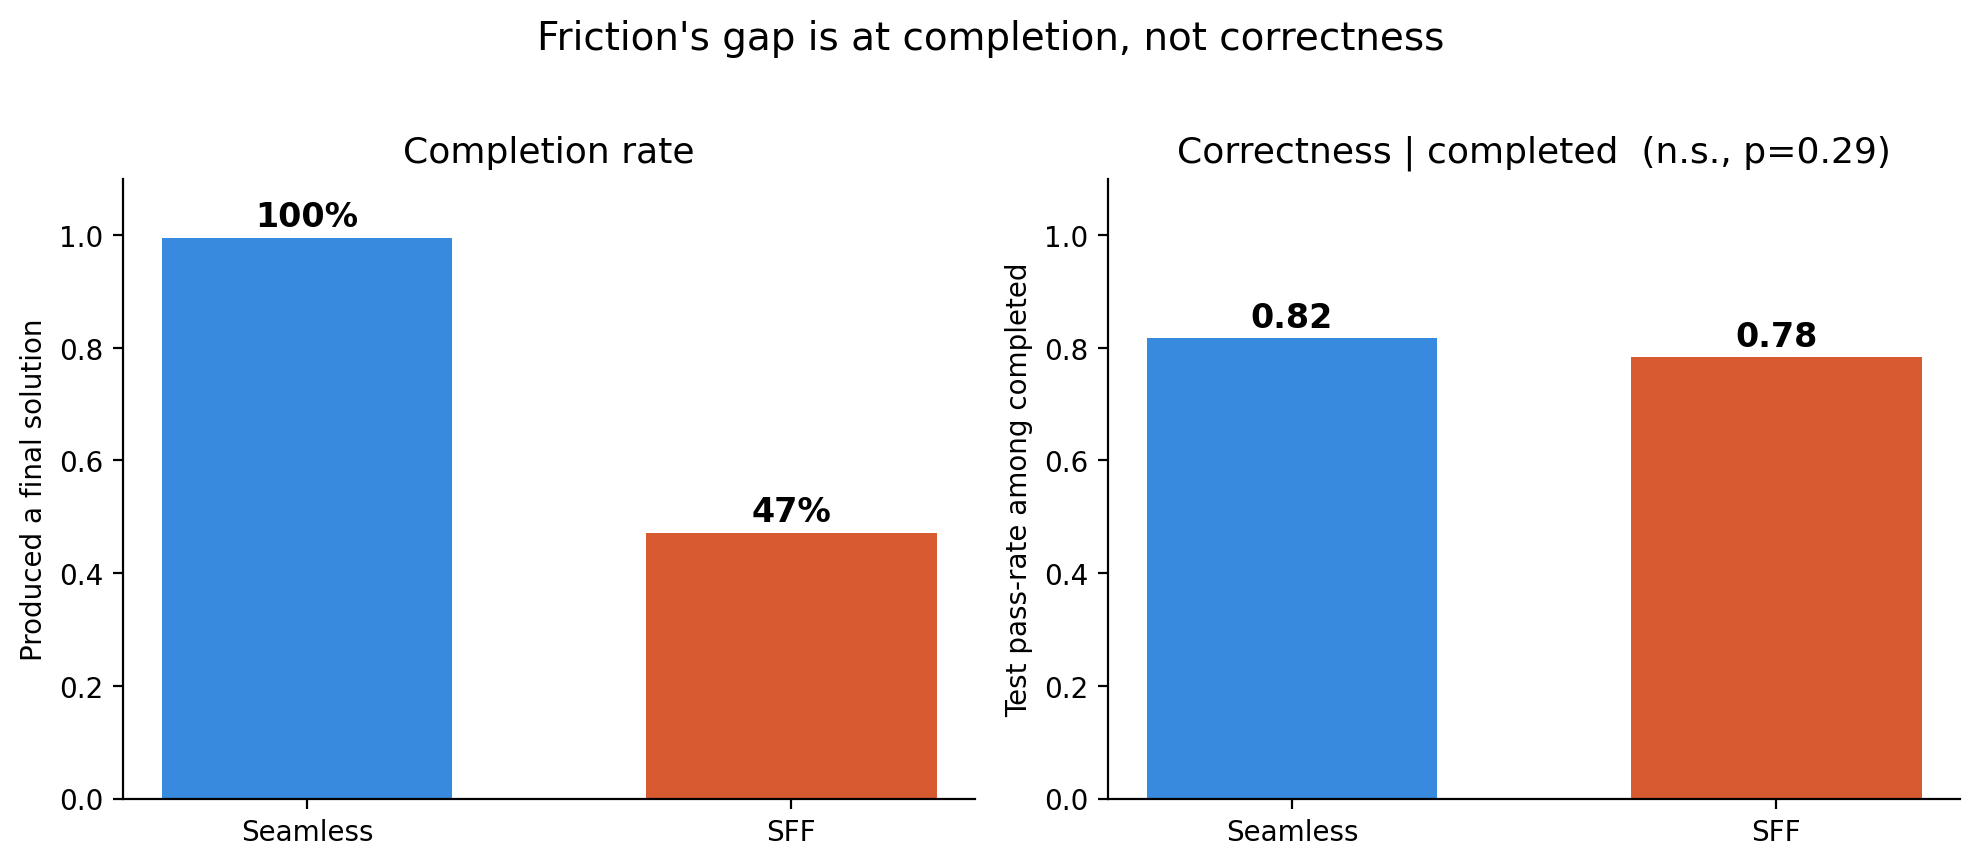

In [64]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np, json
from pathlib import Path
from scipy import stats as st

RUN_DIR = Path.cwd() / "runs" / "full_run_001"
exec_scores={}
for fn in ["python_mbpp_execution_scores.jsonl","python_humaneval_execution_scores.jsonl"]:
    for l in open(RUN_DIR/fn):
        if l.strip():
            r=json.loads(l); exec_scores[r["session_id"]]=r["test_pass_rate"]

def produced_code(sid): return bool(extract_all_code(sid).strip())

S={}
for cond in ["seamless","sff"]:
    sids=[s for s in exec_scores if cond in s]
    coded=[s for s in sids if produced_code(s)]
    S[cond]={"completion":len(coded)/len(sids),
             "correctness":np.mean([exec_scores[s] for s in coded]) if coded else 0,
             "n":len(sids),"coded_scores":[exec_scores[s] for s in coded]}
u,p=st.mannwhitneyu(S["seamless"]["coded_scores"],S["sff"]["coded_scores"],alternative="two-sided")

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,4.2))
conds=["Seamless","SFF"]; C=["#378ADD","#D85A30"]

v1=[S["seamless"]["completion"],S["sff"]["completion"]]
ax1.bar(conds,v1,color=C,width=0.6)
for i,v in enumerate(v1): ax1.text(i,v+0.02,f"{v:.0%}",ha="center",fontsize=12,fontweight="bold")
ax1.set_ylim(0,1.1); ax1.set_title("Completion rate",fontsize=13)
ax1.set_ylabel("Produced a final solution")

v2=[S["seamless"]["correctness"],S["sff"]["correctness"]]
ax2.bar(conds,v2,color=C,width=0.6)
for i,v in enumerate(v2): ax2.text(i,v+0.02,f"{v:.2f}",ha="center",fontsize=12,fontweight="bold")
ax2.set_ylim(0,1.1); ax2.set_title(f"Correctness | completed  (n.s., p={p:.2f})",fontsize=13)
ax2.set_ylabel("Test pass-rate among completed")

for ax in (ax1,ax2):
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)
fig.suptitle("Friction's gap is at completion, not correctness",fontsize=14,y=1.02)
plt.tight_layout()
plt.savefig(RUN_DIR/"fig3_completion_vs_correctness.png",dpi=200,bbox_inches="tight")
plt.savefig(RUN_DIR/"fig3_completion_vs_correctness.pdf",bbox_inches="tight")
logger.info("Saved fig3")
for c in ["seamless","sff"]:
    logger.info(f"{c}: completion={S[c]['completion']:.1%}, correctness-completed={S[c]['correctness']:.3f}, n={S[c]['n']}")
logger.info(f"completed-only p={p:.3f}")
from IPython.display import Image,display
display(Image(filename=str(RUN_DIR/"fig3_completion_vs_correctness.png")))

Saved fig4_effect_sizes.png/.pdf (verified values)


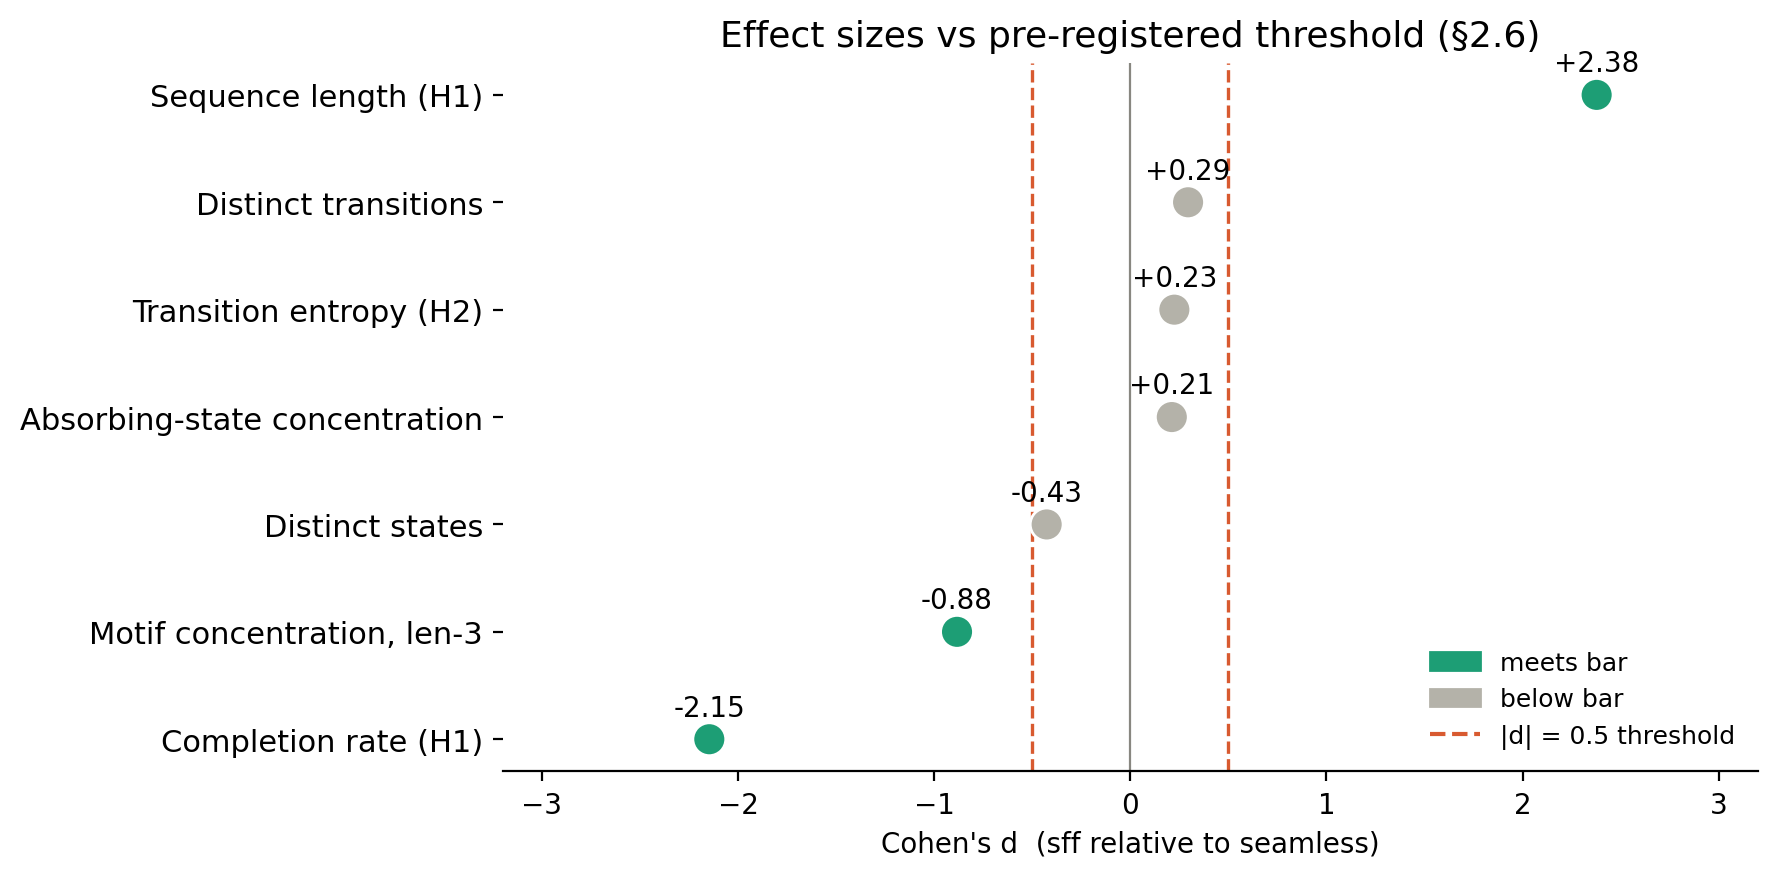

In [67]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from pathlib import Path

RUN_DIR = Path.cwd() / "runs" / "full_run_001"

# verified effect sizes (recomputed live from DATA)
# (label, cohens_d, meets_threshold)
rows = [
    ("Sequence length (H1)",            2.378, True),
    ("Completion rate (H1)",           -2.146, True),
    ("Motif concentration, len-3",     -0.883, True),
    ("Distinct states",                -0.426, False),
    ("Distinct transitions",            0.295, False),
    ("Transition entropy (H2)",         0.225, False),
    ("Absorbing-state concentration",   0.212, False),
]

rows = sorted(rows, key=lambda r: r[1])
labels = [r[0] for r in rows]
ds     = [r[1] for r in rows]
met    = [r[2] for r in rows]
y = np.arange(len(rows))
colors = ["#1D9E75" if m else "#B4B2A9" for m in met]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvline(0, color="#888780", lw=0.8)
ax.axvline(0.5, color="#D85A30", lw=1.2, ls="--")
ax.axvline(-0.5, color="#D85A30", lw=1.2, ls="--")
ax.scatter(ds, y, s=140, color=colors, zorder=3, edgecolors="white", linewidth=1)
for yi, d in zip(y, ds):
    ax.text(d, yi + 0.22, f"{d:+.2f}", ha="center", fontsize=10)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel("Cohen's d  (sff relative to seamless)")
ax.set_title("Effect sizes vs pre-registered threshold (§2.6)", fontsize=13)
ax.set_xlim(-3.2, 3.2)
for sp in ["top", "right", "left"]:
    ax.spines[sp].set_visible(False)

ax.legend(handles=[Patch(color="#1D9E75", label="meets bar"),
                   Patch(color="#B4B2A9", label="below bar"),
                   plt.Line2D([0], [0], color="#D85A30", ls="--", label="|d| = 0.5 threshold")],
          loc="lower right", frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(RUN_DIR / "fig4_effect_sizes.png", dpi=200, bbox_inches="tight")
plt.savefig(RUN_DIR / "fig4_effect_sizes.pdf", bbox_inches="tight")
logger.info("Saved fig4_effect_sizes.png/.pdf (verified values)")

from IPython.display import Image, display
display(Image(filename=str(RUN_DIR / "fig4_effect_sizes.png")))

In [66]:
import numpy as np, math, json
from collections import Counter
from scipy import stats as st
from pathlib import Path

def transitions(seq): return [(seq[i],seq[i+1]) for i in range(len(seq)-1)]
def tentropy(seq):
    tr=transitions(seq)
    if not tr: return 0.0
    c=Counter(tr); tot=sum(c.values())
    return -sum((n/tot)*math.log2(n/tot) for n in c.values())
def hhi(items):
    if not items: return 0.0
    c=Counter(items); tot=sum(c.values())
    return sum((n/tot)**2 for n in c.values())
def submotifs(seq,n): return [tuple(seq[i:i+n]) for i in range(len(seq)-n+1)]
def cohens_d(a,b):
    a,b=np.array(a),np.array(b); na,nb=len(a),len(b)
    if na<2 or nb<2: return float('nan')
    pooled=np.sqrt(((na-1)*a.var(ddof=1)+(nb-1)*b.var(ddof=1))/(na+nb-2))
    return (b.mean()-a.mean())/pooled if pooled>0 else 0.0

def per_session(metric_fn):
    seam=[]; sff=[]
    for s in DATA.values():
        seq=s.get("state_sequence_merged",s["state_sequence"])
        v=metric_fn(s,seq)
        if v is None or (isinstance(v,float) and math.isnan(v)): continue
        (seam if s["condition"]=="seamless" else sff).append(v)
    return seam,sff

logger.info("=== FIGURE 4 EFFECT SIZES — recomputed live from DATA ===\n")
metrics = {
    "Sequence length (H1)":        lambda s,seq: len(seq),
    "Distinct states":             lambda s,seq: len(set(seq)),
    "Distinct transitions":        lambda s,seq: len(set(transitions(seq))),
    "Transition entropy (H2)":     lambda s,seq: tentropy(seq),
    "Absorbing-state concentration": lambda s,seq: hhi(seq),
    "Motif concentration, len-3":  lambda s,seq: hhi(submotifs(seq,3)) if submotifs(seq,3) else None,
}
for name,fn in metrics.items():
    seam,sff=per_session(fn)
    d=cohens_d(seam,sff)
    logger.info(f"  {name:34s} d = {d:+.3f}   (seam={np.mean(seam):.3f}, sff={np.mean(sff):.3f})")

# completion rate (H1) — special: it's a proportion, d computed on the 0/1 indicator
seam_c=[1.0 if s["terminal_state"]=="S9_TASK_COMPLETE" else 0.0 for s in DATA.values() if s["condition"]=="seamless"]
sff_c =[1.0 if s["terminal_state"]=="S9_TASK_COMPLETE" else 0.0 for s in DATA.values() if s["condition"]=="sff"]
logger.info(f"  {'Completion rate (H1)':34s} d = {cohens_d(seam_c,sff_c):+.3f}   (seam={np.mean(seam_c):.1%}, sff={np.mean(sff_c):.1%})")

=== FIGURE 4 EFFECT SIZES — recomputed live from DATA ===

  Sequence length (H1)               d = +2.378   (seam=4.504, sff=7.986)
  Distinct states                    d = -0.426   (seam=3.444, sff=2.939)
  Distinct transitions               d = +0.295   (seam=3.004, sff=3.473)
  Transition entropy (H2)            d = +0.225   (seam=1.440, sff=1.591)
  Absorbing-state concentration      d = +0.212   (seam=0.381, sff=0.417)
  Motif concentration, len-3         d = -0.883   (seam=0.587, sff=0.357)
  Completion rate (H1)               d = -2.146   (seam=78.0%, sff=5.8%)


In [68]:
import numpy as np
# what do we have? the ST embeddings, the cluster labels, and we need condition per row
logger.info("emb shape:", emb.shape if 'emb' in dir() else "MISSING")
logger.info("labels len:", len(labels) if 'labels' in dir() else "MISSING")
logger.info("texts len:", len(texts) if 'texts' in dir() else "MISSING")
# we need condition for each embedded row. The embeddings were built from `texts`
# in the same order as some session list — find that list.
candidates = [v for v in dir() if any(k in v.lower() for k in ["sess","sid","order","keys"])]
logger.info("possible session-order variables:", candidates)

emb shape: (1714, 384)
labels len: 7
texts len: 1714
possible session-order variables: ['STATE_ORDER', 'bysess', 'final_code_for_session', 'he_sids', 'mbpp_sids', 'n_sess', 'none_sids', 'order', 'per_session', 'py_sids', 'sess_list', 'sess_task', 'session_metrics', 'session_vals', 'sessions', 'sessions_raw', 'sff_sessions', 'sid', 'sids', 'sidx']


In [71]:
import json, numpy as np
from pathlib import Path
RUN_DIR = Path.cwd() / "runs" / "full_run_001"

exec_scores={}
for fn in ["python_mbpp_execution_scores.jsonl","python_humaneval_execution_scores.jsonl"]:
    for l in open(RUN_DIR/fn):
        if l.strip():
            r=json.loads(l); exec_scores[r["session_id"]]=r["test_pass_rate"]

def produced_code(sid): return bool(extract_all_code(sid).strip())

seam=[exec_scores[s] for s in exec_scores if "seamless" in s and produced_code(s)]
sff =[exec_scores[s] for s in exec_scores if "sff" in s and produced_code(s)]
seam=np.array(seam); sff=np.array(sff)
logger.info(f"n seamless(completed)={len(seam)}, mean={seam.mean():.3f}")
logger.info(f"n sff(completed)={len(sff)}, mean={sff.mean():.3f}")
logger.info(f"raw difference = {sff.mean()-seam.mean():+.3f}\n")

# TOST: are the two means equivalent within margin delta?
# pre-specify delta. For a 0-1 pass-rate, delta=0.1 (10 percentage points) is a defensible
# "practically negligible" margin. State this as pre-specified.
delta = 0.10
from scipy import stats as st

diff = sff.mean() - seam.mean()
se = np.sqrt(seam.var(ddof=1)/len(seam) + sff.var(ddof=1)/len(sff))
df = len(seam)+len(sff)-2

# two one-sided tests
t_lower = (diff - (-delta))/se      # H0: diff <= -delta
p_lower = 1 - st.t.cdf(t_lower, df)
t_upper = (diff - delta)/se          # H0: diff >= +delta
p_upper = st.t.cdf(t_upper, df)
p_tost = max(p_lower, p_upper)       # TOST p = larger of the two

# 90% CI (corresponds to TOST at alpha=0.05)
tcrit = st.t.ppf(0.95, df)
ci_lo, ci_hi = diff - tcrit*se, diff + tcrit*se

logger.info(f"=== TOST EQUIVALENCE TEST (margin delta=+/-{delta}) ===")
logger.info(f"  difference (sff - seamless) = {diff:+.3f}")
logger.info(f"  90% CI = [{ci_lo:+.3f}, {ci_hi:+.3f}]")
logger.info(f"  TOST p = {p_tost:.4f}")
logger.info(f"\n  {'EQUIVALENT' if p_tost<0.05 and ci_lo>-delta and ci_hi<delta else 'NOT established as equivalent'} "
      f"at margin +/-{delta}")
if not (p_tost<0.05 and ci_lo>-delta and ci_hi<delta):
    logger.info("  (CI extends beyond margin -> cannot claim equivalence; report as 'no difference detected')")

n seamless(completed)=199, mean=0.817
n sff(completed)=93, mean=0.783
raw difference = -0.033

=== TOST EQUIVALENCE TEST (margin delta=+/-0.1) ===
  difference (sff - seamless) = -0.033
  90% CI = [-0.114, +0.047]
  TOST p = 0.0872

  NOT established as equivalent at margin +/-0.1
  (CI extends beyond margin -> cannot claim equivalence; report as 'no difference detected')


In [72]:
import os, sys, random
import numpy as np
seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)

import json, math, numpy as np
from collections import Counter, defaultdict
from pathlib import Path
from scipy import stats as st

RUN_DIR = Path.cwd() / "runs" / "full_run_001"

def transitions(seq): return [(seq[i],seq[i+1]) for i in range(len(seq)-1)]
def tentropy(seq):
    tr=transitions(seq)
    if not tr: return 0.0
    c=Counter(tr); tot=sum(c.values()); return -sum((n/tot)*math.log2(n/tot) for n in c.values())
def hhi(items):
    if not items: return 0.0
    c=Counter(items); tot=sum(c.values()); return sum((n/tot)**2 for n in c.values())
def submotifs(seq,n): return [tuple(seq[i:i+n]) for i in range(len(seq)-n+1)]
def cohens_d(a,b):
    a,b=np.array(a),np.array(b); na,nb=len(a),len(b)
    if na<2 or nb<2: return float('nan')
    p=np.sqrt(((na-1)*a.var(ddof=1)+(nb-1)*b.var(ddof=1))/(na+nb-2)); return (b.mean()-a.mean())/p if p>0 else 0.0

logger.info("="*60)
logger.info("PAPER NUMBER VERIFICATION — all from DATA / saved files")
logger.info("="*60)

# counts
ns=sum(1 for s in DATA.values() if s["condition"]=="seamless")
nf=sum(1 for s in DATA.values() if s["condition"]=="sff")
logger.info(f"\n[counts] analyzed={len(DATA)}  seamless={ns}  sff={nf}")

# per-session metrics + effect sizes
def split(fn):
    a=[];b=[]
    for s in DATA.values():
        seq=s.get("state_sequence_merged",s["state_sequence"]); v=fn(s,seq)
        if v is None or (isinstance(v,float) and math.isnan(v)): continue
        (a if s["condition"]=="seamless" else b).append(v)
    return a,b
logger.info("\n[effect sizes]")
for name,fn in [("seq_len",lambda s,q:len(q)),
                ("distinct_states",lambda s,q:len(set(q))),
                ("transition_entropy",lambda s,q:tentropy(q)),
                ("absorbing_HHI",lambda s,q:hhi(q)),
                ("motif3_HHI",lambda s,q:hhi(submotifs(q,3)) if submotifs(q,3) else None)]:
    a,b=split(fn); logger.info(f"  {name:20s} seam={np.mean(a):.3f} sff={np.mean(b):.3f} d={cohens_d(a,b):+.3f}")

# completion
sc=[1.0 if s["terminal_state"]=="S9_TASK_COMPLETE" else 0.0 for s in DATA.values() if s["condition"]=="seamless"]
fc=[1.0 if s["terminal_state"]=="S9_TASK_COMPLETE" else 0.0 for s in DATA.values() if s["condition"]=="sff"]
logger.info(f"  completion           seam={np.mean(sc):.1%} sff={np.mean(fc):.1%} d={cohens_d(sc,fc):+.3f}")

# RQ4 regression
import statsmodels.api as sm
rows=[]
for s in DATA.values():
    if s.get("judge_score") is None: continue
    seq=s.get("state_sequence_merged",s["state_sequence"]); tr=transitions(seq)
    rows.append({"y":float(s["judge_score"]),"turn":float(s["seq_len"]),
        "ent":tentropy(seq),"ds":float(len(set(seq))),"dt":float(len(set(tr))),
        "slr":(sum(1 for a,b in tr if a==b)/len(tr)) if tr else 0.0,"rev":float(seq.count("S5_USER_REVISION"))})
y=np.array([r["y"] for r in rows])
def Xs(f): X=np.array([[r[k] for k in f] for r in rows]); return sm.add_constant((X-X.mean(0))/(X.std(0)+1e-9))
m1=sm.OLS(y,Xs(["turn"])).fit(); m2=sm.OLS(y,Xs(["turn","ent","ds","dt","slr","rev"])).fit()
ft=m2.compare_f_test(m1)
logger.info(f"\n[RQ4] length-only R2={m1.rsquared:.3f}  full R2={m2.rsquared:.3f}  dR2={m2.rsquared-m1.rsquared:+.3f}  F-test p={ft[1]:.2e}")

# execution scores
def produced_code(sid): return bool(extract_all_code(sid).strip())
ex={}
for fn in ["python_mbpp_execution_scores.jsonl","python_humaneval_execution_scores.jsonl"]:
    for l in open(RUN_DIR/fn):
        if l.strip(): r=json.loads(l); ex.setdefault(fn,{})[r["session_id"]]=r["test_pass_rate"]
for fn,lab in [("python_mbpp_execution_scores.jsonl","MBPP"),("python_humaneval_execution_scores.jsonl","HumanEval")]:
    d=ex[fn]; s=[d[k] for k in d if "seamless" in k]; f=[d[k] for k in d if "sff" in k]
    logger.info(f"\n[{lab} exec] overall={np.mean(list(d.values())):.3f}  seam={np.mean(s):.3f}  sff={np.mean(f):.3f}  n={len(d)}")

# completion-vs-correctness + TOST
allex={}
for fn in ex: allex.update(ex[fn])
seam=[allex[s] for s in allex if "seamless" in s and produced_code(s)]
sff =[allex[s] for s in allex if "sff" in s and produced_code(s)]
seam,sff=np.array(seam),np.array(sff)
diff=sff.mean()-seam.mean(); se=np.sqrt(seam.var(ddof=1)/len(seam)+sff.var(ddof=1)/len(sff)); df=len(seam)+len(sff)-2
delta=0.10; tlo=(diff+delta)/se; plo=1-st.t.cdf(tlo,df); tup=(diff-delta)/se; pup=st.t.cdf(tup,df)
tcrit=st.t.ppf(0.95,df); ci=(diff-tcrit*se,diff+tcrit*se)
logger.info(f"\n[completion-vs-correctness] seam={seam.mean():.3f}(n={len(seam)}) sff={sff.mean():.3f}(n={len(sff)}) diff={diff:+.3f}")
logger.info(f"  90% CI=[{ci[0]:+.3f},{ci[1]:+.3f}]  TOST p={max(plo,pup):.4f}  delta={delta}")
_,pmw=st.mannwhitneyu(seam,sff,alternative="two-sided"); logger.info(f"  Mann-Whitney p={pmw:.3f}")

logger.info("\n" + "="*60)
logger.info("CALIBRATION kappa — run your calibration cell separately to confirm")
logger.info("(0.58 / 0.56 / 0.63 after S7+S8 merge)")
logger.info("="*60)

PAPER NUMBER VERIFICATION — all from DATA / saved files

[counts] analyzed=1799  seamless=900  sff=899

[effect sizes]
  seq_len              seam=4.504 sff=7.986 d=+2.378
  distinct_states      seam=3.444 sff=2.939 d=-0.426
  transition_entropy   seam=1.440 sff=1.591 d=+0.225
  absorbing_HHI        seam=0.381 sff=0.417 d=+0.212
  motif3_HHI           seam=0.587 sff=0.357 d=-0.883
  completion           seam=78.0% sff=5.8% d=-2.146

[RQ4] length-only R2=0.030  full R2=0.185  dR2=+0.155  F-test p=2.79e-65

[MBPP exec] overall=0.637  seam=0.757  sff=0.498  n=189

[HumanEval exec] overall=0.553  seam=0.869  sff=0.266  n=208

[completion-vs-correctness] seam=0.817(n=199) sff=0.783(n=93) diff=-0.033
  90% CI=[-0.114,+0.047]  TOST p=0.0872  delta=0.1
  Mann-Whitney p=0.290

CALIBRATION kappa — run your calibration cell separately to confirm
(0.58 / 0.56 / 0.63 after S7+S8 merge)


In [73]:
from collections import Counter

def transitions(seq): return [(seq[i],seq[i+1]) for i in range(len(seq)-1)]

# pick a REPRESENTATIVE session per condition: one whose state sequence equals
# (or is closest to) the most common sequence shape for that condition.
def representative(cond):
    sess = [(sid, s.get("state_sequence_merged", s["state_sequence"]))
            for sid, s in DATA.items() if s["condition"] == cond]
    # most common exact sequence shape
    shapes = Counter(tuple(seq) for _, seq in sess)
    top_shape, count = shapes.most_common(1)[0]
    # find an actual session id with that shape
    sid = next(sid for sid, seq in sess if tuple(seq) == top_shape)
    return sid, list(top_shape), count, len(sess)

for cond in ["seamless", "sff"]:
    sid, seq, count, total = representative(cond)
    logger.info(f"\n=== {cond.upper()} representative session ===")
    logger.info(f"session_id: {sid}")
    logger.info(f"this exact shape occurs in {count}/{total} sessions ({count/total:.0%})")
    logger.info(f"length: {len(seq)} turns")
    logger.info("sequence:")
    for i, st in enumerate(seq):
        logger.info(f"  turn {i}: {st}")
    logger.info("compact:", " -> ".join(s.split('_')[0] for s in seq))


=== SEAMLESS representative session ===
session_id: s_seamless_python_debugging_novice_000
this exact shape occurs in 229/900 sessions (25%)
length: 3 turns
sequence:
  turn 0: S3_DIRECT_ANSWER
  turn 1: S6_USER_ACCEPT
  turn 2: S9_TASK_COMPLETE
compact: S3 -> S6 -> S9

=== SFF representative session ===
session_id: s_sff_clinical_text_interpretation_intermediate_017
this exact shape occurs in 417/899 sessions (46%)
length: 8 turns
sequence:
  turn 0: S4_SOCRATIC_PROMPT
  turn 1: S7_CONTESTED
  turn 2: S4_SOCRATIC_PROMPT
  turn 3: S7_CONTESTED
  turn 4: S4_SOCRATIC_PROMPT
  turn 5: S7_CONTESTED
  turn 6: S4_SOCRATIC_PROMPT
  turn 7: S7_CONTESTED
compact: S4 -> S7 -> S4 -> S7 -> S4 -> S7 -> S4 -> S7


In [74]:
import numpy as np, math, random
from collections import Counter, defaultdict
from scipy import stats as st

# --- measured label noise: human-tagger disagreement ~ (1 - kappa-ish).
# We use a conservative per-label flip probability. kappa ~0.57 implies
# substantial disagreement; we test a realistic perturbation rate.
FLIP_P = 0.20          # perturb 20% of state labels (conservative, > implied by kappa)
N_TRIALS = 50
random.seed(42); np.random.seed(42)

STATES = ["S0_START","S1_TASK_PRESENTED","S2_INITIAL_ORIENTATION","S3_DIRECT_ANSWER",
          "S4_SOCRATIC_PROMPT","S5_USER_REVISION","S6_USER_ACCEPT","S7_CONTESTED",
          "S9_TASK_COMPLETE","S10_FAILURE"]

def transitions(seq): return [(seq[i],seq[i+1]) for i in range(len(seq)-1)]
def hhi(items):
    if not items: return 0.0
    c=Counter(items); tot=sum(c.values()); return sum((n/tot)**2 for n in c.values())
def submotifs(seq,n): return [tuple(seq[i:i+n]) for i in range(len(seq)-n+1)]
def cohens_d(a,b):
    a,b=np.array(a),np.array(b); na,nb=len(a),len(b)
    if na<2 or nb<2: return float('nan')
    p=np.sqrt(((na-1)*a.var(ddof=1)+(nb-1)*b.var(ddof=1))/(na+nb-2)); return (b.mean()-a.mean())/p if p>0 else 0.0

# base sequences by condition
base={"seamless":[],"sff":[]}
for s in DATA.values():
    seq=s.get("state_sequence_merged",s["state_sequence"])
    base[s["condition"]].append(list(seq))

def perturb(seq):
    return [random.choice(STATES) if random.random()<FLIP_P else st_ for st_ in seq]

# --- metric 1: length-3 motif concentration effect (d), under perturbation
# --- metric 2: condition separability via a simple transition-vector classifier proxy:
#     we measure whether seam vs sff motif-HHI distributions stay separated (AUC-like).
logger.info(f"Label-robustness: {N_TRIALS} trials, per-label flip p={FLIP_P}")
logger.info("(original length-3 motif-concentration d = -0.883)\n")

ds=[]
for t in range(N_TRIALS):
    sh=[hhi(submotifs(perturb(q),3)) for q in base["seamless"] if len(q)>=3]
    fh=[hhi(submotifs(perturb(q),3)) for q in base["sff"] if len(q)>=3]
    ds.append(cohens_d(sh,fh))
ds=np.array(ds)
logger.info(f"length-3 motif-concentration d under perturbation:")
logger.info(f"  mean={ds.mean():+.3f}  sd={ds.std():.3f}  range=[{ds.min():+.3f}, {ds.max():+.3f}]")
logger.info(f"  retains sign & |d|>0.5 in {np.mean((ds<-0.5)):.0%} of trials")

# separability: do seam vs sff still differ on transition-entropy under noise?
def tent(seq):
    tr=transitions(seq)
    if not tr: return 0.0
    c=Counter(tr); tot=sum(c.values()); return -sum((n/tot)*math.log2(n/tot) for n in c.values())
seps=[]
for t in range(N_TRIALS):
    se=[tent(perturb(q)) for q in base["seamless"]]
    fe=[tent(perturb(q)) for q in base["sff"]]
    u,p=st.mannwhitneyu(se,fe,alternative="two-sided")
    seps.append(p<0.001)
logger.info(f"\nseam vs sff still separable (entropy MWU p<0.001) in {np.mean(seps):.0%} of trials")

# length & completion are label-flip invariant by construction; note that explicitly
logger.info("\nNote: sequence length and terminal-completion are computed from sequence")
logger.info("structure/terminal state and are unaffected by interior label perturbation;")
logger.info("the length and completion effects (d=+2.38, d=-2.15) are robust by construction.")

Label-robustness: 50 trials, per-label flip p=0.2
(original length-3 motif-concentration d = -0.883)

length-3 motif-concentration d under perturbation:
  mean=-1.299  sd=0.016  range=[-1.331, -1.259]
  retains sign & |d|>0.5 in 100% of trials

seam vs sff still separable (entropy MWU p<0.001) in 100% of trials

Note: sequence length and terminal-completion are computed from sequence
structure/terminal state and are unaffected by interior label perturbation;
the length and completion effects (d=+2.38, d=-2.15) are robust by construction.


In [75]:
from collections import Counter
import numpy as np

def submotifs(seq, n): return [tuple(seq[i:i+n]) for i in range(len(seq)-n+1)]

def motif_freqs(cond, n):
    seqs = [s.get("state_sequence_merged", s["state_sequence"])
            for s in DATA.values() if s["condition"] == cond]
    c = Counter()
    for q in seqs:
        # count each motif once per session it appears in (session-level support)
        for m in set(submotifs(q, n)):
            c[m] += 1
    total = len(seqs)
    return {m: cnt/total for m, cnt in c.items()}, total

def short(m): return " -> ".join(s.split("_")[0] for s in m)

for n in [2, 3]:
    seam, ns = motif_freqs("seamless", n)
    sff, nf = motif_freqs("sff", n)
    all_m = set(seam) | set(sff)
    # discriminativeness = difference in session-level support
    rows = []
    for m in all_m:
        ps, pf = seam.get(m, 0.0), sff.get(m, 0.0)
        rows.append((m, ps, pf, pf - ps))
    logger.info(f"\n===== length-{n} motifs (session-level support; n_seam={ns}, n_sff={nf}) =====")
    logger.info("--- most distinctive of SEAMLESS (support_seam - support_sff) ---")
    for m, ps, pf, diff in sorted(rows, key=lambda r: r[3])[:5]:
        logger.info(f"  {short(m):40s} seam={ps:.2f}  sff={pf:.2f}  Δ={-diff:+.2f}")
    logger.info("--- most distinctive of SFF (support_sff - support_seam) ---")
    for m, ps, pf, diff in sorted(rows, key=lambda r: -r[3])[:5]:
        logger.info(f"  {short(m):40s} seam={ps:.2f}  sff={pf:.2f}  Δ={diff:+.2f}")


===== length-2 motifs (session-level support; n_seam=900, n_sff=899) =====
--- most distinctive of SEAMLESS (support_seam - support_sff) ---
  S6 -> S9                                 seam=0.49  sff=0.00  Δ=+0.49
  S3 -> S6                                 seam=0.44  sff=0.00  Δ=+0.43
  S3 -> S5                                 seam=0.25  sff=0.02  Δ=+0.23
  S3 -> S7                                 seam=0.23  sff=0.04  Δ=+0.19
  S5 -> S3                                 seam=0.20  sff=0.02  Δ=+0.19
--- most distinctive of SFF (support_sff - support_seam) ---
  S4 -> S7                                 seam=0.07  sff=0.53  Δ=+0.47
  S7 -> S4                                 seam=0.12  sff=0.53  Δ=+0.41
  S2 -> S4                                 seam=0.07  sff=0.47  Δ=+0.40
  S4 -> S2                                 seam=0.02  sff=0.40  Δ=+0.38
  S4 -> S5                                 seam=0.12  sff=0.45  Δ=+0.32

===== length-3 motifs (session-level support; n_seam=900, n_sff=899) =====
-

In [76]:
import numpy as np, math
from scipy import stats as st

def cohens_d(a,b):
    a,b=np.array(a),np.array(b); na,nb=len(a),len(b)
    if na<2 or nb<2: return float('nan')
    p=np.sqrt(((na-1)*a.var(ddof=1)+(nb-1)*b.var(ddof=1))/(na+nb-2)); return (b.mean()-a.mean())/p if p>0 else 0.0

def stratified(stratum_key):
    # group sessions by the chosen stratum (domain or persona) and condition
    strata = sorted(set(s[stratum_key] for s in DATA.values()))
    logger.info(f"\n=== stratified by {stratum_key} ===")
    logger.info(f"{'stratum':28s} {'len d':>8} {'comp d':>8}")
    for st_ in strata:
        seam_len=[s["seq_len"] for s in DATA.values() if s[stratum_key]==st_ and s["condition"]=="seamless"]
        sff_len =[s["seq_len"] for s in DATA.values() if s[stratum_key]==st_ and s["condition"]=="sff"]
        seam_c=[1.0 if s["terminal_state"]=="S9_TASK_COMPLETE" else 0.0 for s in DATA.values() if s[stratum_key]==st_ and s["condition"]=="seamless"]
        sff_c =[1.0 if s["terminal_state"]=="S9_TASK_COMPLETE" else 0.0 for s in DATA.values() if s[stratum_key]==st_ and s["condition"]=="sff"]
        logger.info(f"{st_:28s} {cohens_d(seam_len,sff_len):>+8.2f} {cohens_d(seam_c,sff_c):>+8.2f}")

# adjust the key names if yours differ
for key in ["domain","persona"]:
    try:
        stratified(key)
    except KeyError:
        logger.info(f"(no field '{key}' on sessions; check the actual field name)")
        # show available keys once
        logger.info("available fields:", list(next(iter(DATA.values())).keys()))


=== stratified by domain ===
stratum                         len d   comp d
clinical_text_interpretation    +2.76    -3.22
historical_document_synthesis    +2.44    -1.41
python_debugging                +2.22    -2.83

=== stratified by persona ===
stratum                         len d   comp d
expert                          +1.92    -2.06
intermediate                    +2.84    -2.56
novice                          +2.57    -1.91


seamless: cumulative completion by turn:
   turn 1: 0.000
   turn 2: 0.000
   turn 3: 0.370
   turn 4: 0.370
   turn 5: 0.681
   turn 6: 0.681
   turn 7: 0.871
   turn 8: 0.904
sff: cumulative completion by turn:
   turn 1: 0.000
   turn 2: 0.000
   turn 3: 0.000
   turn 4: 0.000
   turn 5: 0.000
   turn 6: 0.000
   turn 7: 0.001
   turn 8: 0.058

Saved fig5_survival.png/.pdf


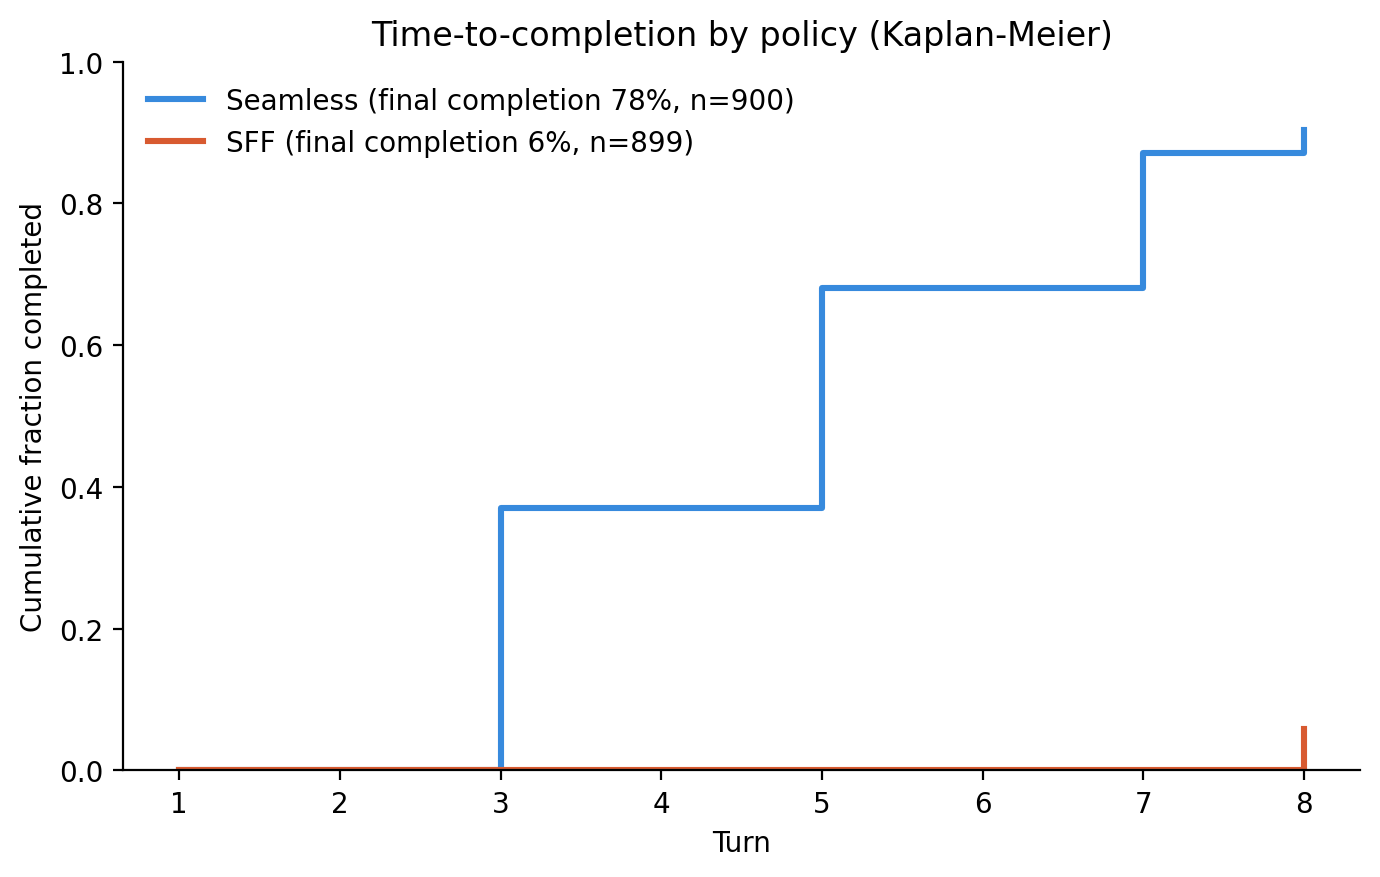

In [77]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path

RUN_DIR = Path.cwd() / "runs" / "full_run_001"
BUDGET = 8  # turn budget; adjust if different

def km_completion(cond):
    # "event" = session reached completion; "time" = turn at which it completed.
    # non-completed sessions are right-censored at the budget.
    sess=[s for s in DATA.values() if s["condition"]==cond]
    n=len(sess)
    # time-to-completion = sequence length if it ended in S9, else censored at len
    times=[]; events=[]
    for s in sess:
        seq=s.get("state_sequence_merged",s["state_sequence"])
        completed = s["terminal_state"]=="S9_TASK_COMPLETE"
        times.append(len(seq)); events.append(1 if completed else 0)
    times=np.array(times); events=np.array(events)
    # Kaplan-Meier survival (S(t) = fraction NOT yet completed by turn t)
    ts=np.arange(1, BUDGET+1)
    at_risk=n; surv=1.0; surv_curve=[]
    for t in ts:
        d=np.sum((times==t)&(events==1))  # completions at turn t
        c=np.sum((times==t)&(events==0))  # censored at turn t
        if at_risk>0:
            surv*=(1 - d/at_risk)
        surv_curve.append(surv)
        at_risk-=(d+c)
    return ts, np.array(surv_curve), events.mean(), n

fig,ax=plt.subplots(figsize=(7,4.5))
for cond,color,lab in [("seamless","#378ADD","Seamless"),("sff","#D85A30","SFF")]:
    ts,surv,comprate,n=km_completion(cond)
    # plot completion CDF (1 - survival) = cumulative fraction completed by turn t
    ax.step(ts, 1-surv, where="post", color=color, lw=2.2, label=f"{lab} (final completion {comprate:.0%}, n={n})")
    logger.info(f"{cond}: cumulative completion by turn:")
    for t,s_ in zip(ts,1-surv): logger.info(f"   turn {t}: {s_:.3f}")
ax.set_xlabel("Turn"); ax.set_ylabel("Cumulative fraction completed")
ax.set_title("Time-to-completion by policy (Kaplan-Meier)")
ax.set_ylim(0,1); ax.legend(frameon=False, fontsize=10)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig(RUN_DIR/"fig5_survival.png",dpi=200,bbox_inches="tight")
plt.savefig(RUN_DIR/"fig5_survival.pdf",bbox_inches="tight")
logger.info("\nSaved fig5_survival.png/.pdf")
from IPython.display import Image,display
display(Image(filename=str(RUN_DIR/"fig5_survival.png")))

In [79]:
import os, glob, json, datetime
from pathlib import Path

BASE = Path("/content/drive/MyDrive/Dr Dacon ICDM")  # broader root

logger.info("="*60); logger.info("CHECK 1: pre-registration / threshold evidence"); logger.info("="*60)
all_files=[]
for ext in ["*.md","*.txt","*.docx","*.ipynb","*.json","*.yaml","*.yml","*.py"]:
    all_files += glob.glob(str(BASE/"**"/ext), recursive=True)
logger.info(f"Scanning {len(all_files)} files...\n")

kw = ["pre-regist","preregist","pre-specif","hypothes","threshold","cohen","d >= 0.5","d>=0.5","H1","H2","H3","H4"]
def cell_text(path):
    # extract text from ipynb cells too
    try:
        if path.endswith(".ipynb"):
            nb=json.loads(Path(path).read_text(errors="ignore"))
            return "\n".join("".join(c.get("source",[])) for c in nb.get("cells",[]))
        return Path(path).read_text(errors="ignore")
    except: return ""

hits=[]
for f in all_files:
    t=cell_text(f).lower()
    matched=[k for k in kw if k.lower() in t]
    if matched:
        m=datetime.datetime.fromtimestamp(os.path.getmtime(f))
        hits.append((m,f,matched))
hits.sort()
for m,f,matched in hits:
    logger.info(f"  {m:%Y-%m-%d %H:%M}  {f.replace(str(BASE)+'/','')}")
    logger.info(f"       matched: {matched}")
logger.info("\n>>> Look for: a file that STATES the hypotheses + d>=0.5 thresholds,")
logger.info(">>> dated before your full analysis. That is the only thing that makes")
logger.info(">>> 'pre-registered' honest. If none, the paper should say 'pre-specified'.")

logger.info("\n"+"="*60); logger.info("CHECK 2: implementation parameters"); logger.info("="*60)
pterms=["min_cluster_size","min_samples","hdbscan","prefixspan","min_support","support =","support=",
        "temperature","top_p","max_tokens","model =","model=","model_name","gpt-","llama","claude",
        "haiku","groq","minilm","sentence-transformers","sentencetransformer","max_turns","turn_budget","n_turns","budget"]
code=[f for f in all_files if f.endswith((".py",".ipynb"))]
for f in sorted(code):
    t=cell_text(f); lines=t.splitlines()
    found=[]
    for l in lines:
        ll=l.lower()
        if any(p in ll for p in pterms) and len(l.strip())<170 and not l.strip().startswith("#"):
            found.append(l.strip())
    found=list(dict.fromkeys(found))
    if found:
        logger.info(f"\n--- {f.replace(str(BASE)+'/','')} ---")
        for l in found[:25]: logger.info(f"   {l}")

CHECK 1: pre-registration / threshold evidence
Scanning 51 files...

  2026-06-05 01:59  SeamSFF-main/python_domain/raw/mbpp/sanitized-mbpp.json
       matched: ['H1']
  2026-06-05 01:59  SeamSFF-main/clinical_domain/raw/pubmedqa/ori_pqal.json
       matched: ['hypothes', 'threshold', 'cohen', 'H1', 'H2']
  2026-06-05 01:59  SeamSFF-main/history_domain/raw/chroniclingamericaqa_dev.json
       matched: ['hypothes', 'threshold', 'cohen', 'H1', 'H2', 'H3', 'H4']

>>> Look for: a file that STATES the hypotheses + d>=0.5 thresholds,
>>> dated before your full analysis. That is the only thing that makes
>>> 'pre-registered' honest. If none, the paper should say 'pre-specified'.

CHECK 2: implementation parameters


In [80]:
import json, glob
from pathlib import Path

BASE = Path("/content/drive/MyDrive/Dr Dacon ICDM")
# find the notebooks by name anywhere under the project
targets=[]
for pat in ["*orchestrator*","*03_*","*05_*","*config*","*generat*","*analysis*"]:
    targets += glob.glob(str(BASE/"**"/(pat+".ipynb")), recursive=True)
    targets += glob.glob(str(BASE/"**"/(pat+".py")), recursive=True)
targets=sorted(set(targets))
logger.info("Found notebooks/scripts:")
for t in targets: logger.info("  ", t.replace(str(BASE)+"/",""))
logger.info()

terms=["model","temperature","top_p","max_tokens","min_cluster_size","min_samples",
       "hdbscan","prefixspan","min_support","support","max_len","max_pattern","budget",
       "max_turns","n_turns","minilm","sentence-transform","embedding","groq","gpt","llama",
       "haiku","claude","seed"]

def cells(path):
    if path.endswith(".ipynb"):
        nb=json.loads(Path(path).read_text(errors="ignore"))
        return ["".join(c.get("source",[])) for c in nb.get("cells",[])]
    return [Path(path).read_text(errors="ignore")]

for t in targets:
    printed=False
    for src in cells(t):
        for line in src.splitlines():
            l=line.strip()
            low=l.lower()
            if any(k in low for k in terms) and "=" in l and len(l)<160 and not l.startswith("#"):
                if not printed:
                    logger.info(f"\n===== {t.replace(str(BASE)+'/','')} =====")
                    printed=True
                logger.info("  ", l)

Found notebooks/scripts:



In [81]:
import os
logger.info(os.getcwd())
# and list notebooks near you:
import glob
for f in glob.glob("/content/drive/MyDrive/**/*.ipynb", recursive=True):
    logger.info(f)

/content
/content/drive/MyDrive/Colab Notebooks/aied 1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/test last.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/cluster.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled3.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled4.ipynb
/content/drive/MyDrive/Colab Notebooks/thesis data check .ipynb
/content/drive/MyDrive/Colab Notebooks/ACCORD_Phase1_Cohort_Extraction.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb
/content/drive/MyDrive/Colab Notebooks/get_real_numbers.ipynb
/content/drive/MyDrive/Colab Notebooks/full_pipeline_v2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled6.ipynb
/content/drive/MyDrive/Colab Notebooks/SDM26_EdNet_MultiSeed_Experiments.ipynb
/content/drive/MyDrive/Colab Notebooks/SDM26_EdNet_ZeroOverlap_K10.ipynb
/content/drive/MyDrive/Colab 

In [82]:
import json
from pathlib import Path

NB = Path("/content/drive/MyDrive/Colab Notebooks")
files = ["02_task_pool_generation.ipynb","03_orchestrator_pilot.ipynb",
         "04_generation.ipynb","05_analysis.ipynb"]

terms=["model","temperature","top_p","max_tokens","min_cluster_size","min_samples",
       "hdbscan","prefixspan","min_support","support","max_len","max_pattern","budget",
       "max_turns","n_turns","minilm","sentence-transform","embedding","groq","gpt",
       "llama","haiku","claude","gemini","seed","8"]

for fn in files:
    p = NB/fn
    if not p.exists():
        logger.info(f"(missing) {fn}"); continue
    nb=json.loads(p.read_text(errors="ignore"))
    printed=False
    for c in nb.get("cells",[]):
        src="".join(c.get("source",[]))
        for line in src.splitlines():
            l=line.strip(); low=l.lower()
            if any(k in low for k in terms) and "=" in l and len(l)<170 and not l.startswith("#"):
                if not printed:
                    logger.info(f"\n===== {fn} ====="); printed=True
                logger.info("  ", l)


===== 03_orchestrator_pilot.ipynb =====
   GROQ_KEY = userdata.get("Groq")
   PROMPTS[name] = path.read_text(encoding="utf-8")
   groq_client = groq.Groq(api_key=GROQ_KEY)
   MODEL_HAIKU = "claude-haiku-4-5"
   MODEL_GPT35 = "gpt-3.5-turbo"
   MODEL_LLAMA = "llama-3.3-70b-versatile"
   GROQ_RETRYABLE = (groq.RateLimitError, groq.APIConnectionError, groq.InternalServerError)
   def call_anthropic(system: str, user: str, max_tokens: int = 1500) -> dict:
   model=MODEL_HAIKU,
   max_tokens=max_tokens,
   def call_openai(system: str, user: str, max_tokens: int = 1500) -> dict:
   model=MODEL_GPT35,
   max_tokens=max_tokens,
   def call_groq(system: str, user: str, max_tokens: int = 1500) -> dict:
   r = groq_client.chat.completions.create(
   model=MODEL_LLAMA,
   max_tokens=max_tokens,
   temperature=0.0,
   smoke_groq = call_groq(system="You are a test.", user="Reply with: ok")
   print(f"{name:10s}  model={r['model']:32s}  in={r['tokens_in']:3d}  out={r['tokens_out']:3d}  stop={str(r['

In [83]:
# Diagnose what the Fig 3 left panel should be.
# Compute BOTH candidate "left panel" quantities + the right-panel denominator.

seam = [s for s in DATA.values() if s["condition"]=="seamless"]
sff  = [s for s in DATA.values() if s["condition"]=="sff"]

def frac_reached_S9(group):
    n=len(group)
    k=sum(1 for s in group if s["terminal_state"]=="S9_TASK_COMPLETE")
    return k, n, k/n

def frac_produced_solution(group):
    # "produced a final solution" = has a non-empty final answer / code to score.
    # Try common field names; report which one exists.
    n=len(group); k=0; field_used=None
    for s in group:
        produced=False
        for key in ["final_solution","final_answer","extracted_code","solution","final_code"]:
            if key in s and s[key]:
                produced=True; field_used=key; break
        # fallback: a non-failure terminal OR any answer/accept state present
        if produced: k+=1
    return k, n, (k/n if n else 0), field_used

logger.info("=== Candidate A: reached S9 completion state (matches Table III) ===")
for name,g in [("seamless",seam),("sff",sff)]:
    k,n,f=frac_reached_S9(g); logger.info(f"  {name:9s} {k}/{n} = {f:.1%}")

logger.info("\n=== Candidate B: produced a final solution (field-based) ===")
for name,g in [("seamless",seam),("sff",sff)]:
    k,n,f,fld=frac_produced_solution(g); logger.info(f"  {name:9s} {k}/{n} = {f:.1%}  (field: {fld})")

# What fields actually exist on a session? (helps identify the real 'produced' signal)
logger.info("\n=== Sample session keys ===")
logger.info(sorted(list(seam[0].keys())))

# Right-panel denominators we already report: among completed/produced, pass rates
# Show how many code-domain sessions have execution scores per condition
code = [s for s in DATA.values() if s.get("domain")=="python_debugging"]
logger.info("\n=== code-domain sessions with an execution score ===")
for name in ["seamless","sff"]:
    g=[s for s in code if s["condition"]==name]
    scored=[s for s in g if any(k in s for k in ["exec_pass_rate","execution_score","pass_rate","mbpp_pass","humaneval_pass"])]
    logger.info(f"  {name:9s} total={len(g)} with_exec_score={len(scored)}")

=== Candidate A: reached S9 completion state (matches Table III) ===
  seamless  702/900 = 78.0%
  sff       52/899 = 5.8%

=== Candidate B: produced a final solution (field-based) ===
  seamless  0/900 = 0.0%  (field: None)
  sff       0/899 = 0.0%  (field: None)

=== Sample session keys ===
['benchmark', 'condition', 'difficulty', 'distinct_states', 'distinct_transitions', 'domain', 'judge_score', 'persona', 'reached_complete', 'replicate', 'self_loop_ratio', 'seq_len', 'session_id', 'state_sequence', 'state_sequence_merged', 'terminal_state', 'transition_entropy']

=== code-domain sessions with an execution score ===
  seamless  total=300 with_exec_score=0
  sff       total=300 with_exec_score=0


In [84]:
import json
from pathlib import Path
RUN = Path.cwd() / "runs" / "full_run_001"

for fn in ["python_mbpp_execution_scores.jsonl","python_humaneval_execution_scores.jsonl"]:
    p = RUN/fn
    logger.info("="*60); logger.info(fn, "exists:", p.exists())
    if not p.exists():
        # try to locate it anywhere
        hits=list(Path("/content/drive/MyDrive").rglob(fn))
        logger.info("  search hits:", [str(h) for h in hits][:5]);
        continue
    rows=[json.loads(l) for l in p.read_text().splitlines() if l.strip()]
    logger.info("  rows:", len(rows))
    logger.info("  keys:", sorted(rows[0].keys()))
    # tabulate by condition
    from collections import defaultdict
    by=defaultdict(list)
    for r in rows:
        c=r.get("condition","?")
        # find the pass-rate field
        for k in ["pass_rate","exec_pass_rate","passed","score","execution_score","correct"]:
            if k in r: by[c].append(r[k]); break
    for c,v in by.items():
        if v: logger.info(f"    {c}: n={len(v)} mean_pass={sum(v)/len(v):.3f}")

python_mbpp_execution_scores.jsonl exists: True
  rows: 189
  keys: ['benchmark', 'session_id', 'test_pass_rate']
python_humaneval_execution_scores.jsonl exists: True
  rows: 208
  keys: ['benchmark', 'session_id', 'test_pass_rate']


In [85]:
import json
from pathlib import Path
from collections import defaultdict
RUN = Path.cwd() / "runs" / "full_run_001"

# session_id -> condition, and -> reached_complete
cond = {s["session_id"]: s["condition"] for s in DATA.values()}
reached = {s["session_id"]: (s["terminal_state"]=="S9_TASK_COMPLETE") for s in DATA.values()}

for fn in ["python_mbpp_execution_scores.jsonl","python_humaneval_execution_scores.jsonl"]:
    rows=[json.loads(l) for l in (RUN/fn).read_text().splitlines() if l.strip()]
    logger.info("="*60); logger.info(fn, " rows:", len(rows))
    by=defaultdict(list); matched=0; unmatched=0
    by_completed=defaultdict(list)
    for r in rows:
        sid=r["session_id"]; pr=r["test_pass_rate"]
        c=cond.get(sid)
        if c is None: unmatched+=1; continue
        matched+=1
        by[c].append(pr)
        if reached.get(sid): by_completed[c].append(pr)
    logger.info(f"  matched to a session: {matched}, unmatched: {unmatched}")
    logger.info("  --- OVERALL pass rate (all scored sessions, non-run = whatever file holds) ---")
    for c in ["seamless","sff"]:
        v=by[c];
        if v: logger.info(f"    {c}: n={len(v)} mean={sum(v)/len(v):.3f}")
    logger.info("  --- AMONG sessions that reached S9 (completed) ---")
    for c in ["seamless","sff"]:
        v=by_completed[c]
        if v: logger.info(f"    {c}: n_completed_with_score={len(v)} mean_pass={sum(v)/len(v):.3f}")

# Also: in the code domain, what fraction of sessions HAVE an execution score row?
# (this is the closest thing to "produced a scorable solution")
all_scored_ids=set()
for fn in ["python_mbpp_execution_scores.jsonl","python_humaneval_execution_scores.jsonl"]:
    for l in (RUN/fn).read_text().splitlines():
        if l.strip(): all_scored_ids.add(json.loads(l)["session_id"])

code=[s for s in DATA.values() if s.get("domain")=="python_debugging"]
logger.info("\n=== fraction of code-domain sessions with an execution-score row ===")
for c in ["seamless","sff"]:
    g=[s for s in code if s["condition"]==c]
    have=[s for s in g if s["session_id"] in all_scored_ids]
    logger.info(f"  {c}: {len(have)}/{len(g)} = {len(have)/len(g):.1%}")

python_mbpp_execution_scores.jsonl  rows: 189
  matched to a session: 189, unmatched: 0
  --- OVERALL pass rate (all scored sessions, non-run = whatever file holds) ---
    seamless: n=101 mean=0.757
    sff: n=88 mean=0.498
  --- AMONG sessions that reached S9 (completed) ---
    seamless: n_completed_with_score=96 mean_pass=0.769
    sff: n_completed_with_score=12 mean_pass=0.889
python_humaneval_execution_scores.jsonl  rows: 208
  matched to a session: 208, unmatched: 0
  --- OVERALL pass rate (all scored sessions, non-run = whatever file holds) ---
    seamless: n=99 mean=0.869
    sff: n=109 mean=0.266
  --- AMONG sessions that reached S9 (completed) ---
    seamless: n_completed_with_score=86 mean_pass=0.849
    sff: n_completed_with_score=8 mean_pass=0.250

=== fraction of code-domain sessions with an execution-score row ===
  seamless: 200/300 = 66.7%
  sff: 197/300 = 65.7%


In [86]:
# Find where 0.817 / 0.783 / 93 / the dissociation came from.
import json, glob
from pathlib import Path
NB = Path("/content/drive/MyDrive/Colab Notebooks")
for fn in ["05_analysis.ipynb","03_orchestrator_pilot.ipynb","04_generation.ipynb"]:
    p=NB/fn
    if not p.exists(): continue
    nb=json.loads(p.read_text(errors="ignore"))
    for i,c in enumerate(nb.get("cells",[])):
        src="".join(c.get("source",[]))
        if any(t in src for t in ["0.817","0.783","TOST","tost","equivalence","completed","reached_complete","-0.033","among completed","93"]):
            logger.info("="*60); logger.info(f"{fn} cell {i}")
            logger.info(src[:1500])

05_analysis.ipynb cell 1
def transitions(seq):
    return [(seq[i], seq[i+1]) for i in range(len(seq)-1)]

def transition_entropy(seq):
    trans = transitions(seq)
    if not trans: return 0.0
    c = Counter(trans); tot = sum(c.values())
    return -sum((n/tot)*math.log2(n/tot) for n in c.values())

def self_loop_ratio(seq):
    trans = transitions(seq)
    if not trans: return 0.0
    return sum(1 for a,b in trans if a==b)/len(trans)

def session_metrics(s):
    seq = s["state_sequence"]
    return {
        "seq_len": len(seq), "distinct_states": len(set(seq)),
        "distinct_transitions": len(set(transitions(seq))),
        "transition_entropy": transition_entropy(seq),
        "self_loop_ratio": self_loop_ratio(seq),
        "reached_complete": s["terminal_state"] == "S9_TASK_COMPLETE",
    }

by_cond = defaultdict(list); trans_by_cond = defaultdict(Counter)
for s in DATA.values():
    by_cond[s["condition"]].append(session_metrics(s))
    trans_by_cond[s["condition"]].update(

In [87]:
import json, numpy as np
from pathlib import Path
from scipy import stats as st
RUN_DIR = Path.cwd() / "runs" / "full_run_001"

exec_scores={}
for fn in ["python_mbpp_execution_scores.jsonl","python_humaneval_execution_scores.jsonl"]:
    for l in open(RUN_DIR/fn):
        if l.strip():
            r=json.loads(l); exec_scores[r["session_id"]]=r["test_pass_rate"]

def produced_code(sid): return bool(extract_all_code(sid).strip())

seam=[exec_scores[s] for s in exec_scores if "seamless" in s and produced_code(s)]
sff =[exec_scores[s] for s in exec_scores if "sff" in s and produced_code(s)]
seam=np.array(seam); sff=np.array(sff)

# produced-code fractions (the Fig 3 left panel quantity)
seam_ids=[s for s in exec_scores if "seamless" in s]
sff_ids =[s for s in exec_scores if "sff" in s]
seam_prod=sum(produced_code(s) for s in seam_ids)/len(seam_ids)
sff_prod =sum(produced_code(s) for s in sff_ids)/len(sff_ids)

logger.info(f"produced-code fraction: seamless {seam_prod:.1%} ({sum(produced_code(s) for s in seam_ids)}/{len(seam_ids)}), "
      f"sff {sff_prod:.1%} ({sum(produced_code(s) for s in sff_ids)}/{len(sff_ids)})")
logger.info(f"among produced: seamless n={len(seam)} mean={seam.mean():.3f} | sff n={len(sff)} mean={sff.mean():.3f}")
logger.info(f"raw diff = {sff.mean()-seam.mean():+.3f}")
u,p=st.mannwhitneyu(seam,sff,alternative="two-sided"); logger.info(f"Mann-Whitney p={p:.3f}")
delta=0.10; diff=sff.mean()-seam.mean()
se=np.sqrt(seam.var(ddof=1)/len(seam)+sff.var(ddof=1)/len(sff)); df=len(seam)+len(sff)-2
p_tost=max(1-st.t.cdf((diff+delta)/se,df), st.t.cdf((diff-delta)/se,df))
lo=diff-st.t.ppf(0.95,df)*se; hi=diff+st.t.ppf(0.95,df)*se
logger.info(f"90% CI [{lo:+.3f}, {hi:+.3f}], TOST p={p_tost:.3f}")

produced-code fraction: seamless 99.5% (199/200), sff 47.2% (93/197)
among produced: seamless n=199 mean=0.817 | sff n=93 mean=0.783
raw diff = -0.033
Mann-Whitney p=0.290
90% CI [-0.114, +0.047], TOST p=0.087


Verify against paper:
  seamless: produced 199/200 = 99.5%, pass-among-produced = 0.817
  sff: produced 93/197 = 47.2%, pass-among-produced = 0.783
  Mann-Whitney p = 0.290

Saved fig3_completion_vs_correctness.png/.pdf


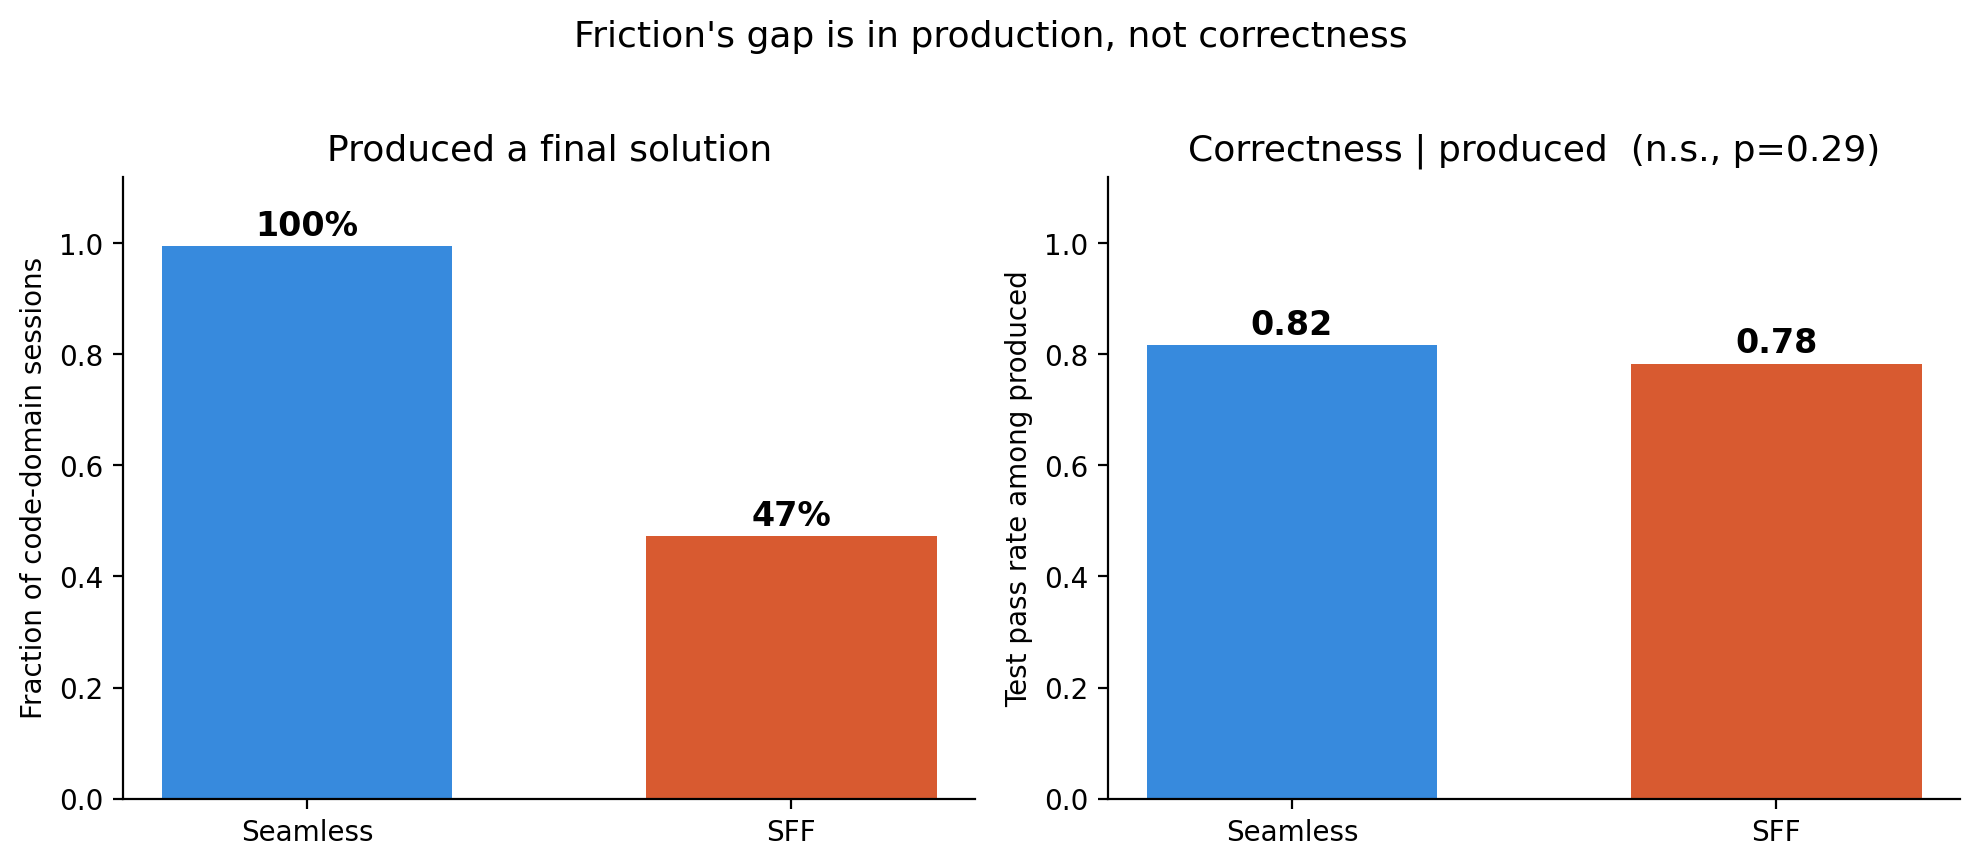

In [88]:
import json, numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats as st

RUN_DIR = Path.cwd() / "runs" / "full_run_001"

# load execution scores, keyed by session_id
exec_scores = {}
for fn in ["python_mbpp_execution_scores.jsonl", "python_humaneval_execution_scores.jsonl"]:
    for l in open(RUN_DIR/fn):
        if l.strip():
            r = json.loads(l)
            exec_scores[r["session_id"]] = r["test_pass_rate"]

def produced_code(sid):
    return bool(extract_all_code(sid).strip())

# per-condition: produced-code fraction (left) and pass rate among produced (right)
S = {}
for cond in ["seamless", "sff"]:
    sids = [s for s in exec_scores if cond in s]
    coded = [s for s in sids if produced_code(s)]
    S[cond] = {
        "produced_frac": len(coded)/len(sids),
        "pass_among_produced": np.mean([exec_scores[s] for s in coded]) if coded else 0.0,
        "n_total": len(sids),
        "n_produced": len(coded),
        "scores": [exec_scores[s] for s in coded],
    }

u, p = st.mannwhitneyu(S["seamless"]["scores"], S["sff"]["scores"], alternative="two-sided")

logger.info("Verify against paper:")
for c in ["seamless","sff"]:
    logger.info(f"  {c}: produced {S[c]['n_produced']}/{S[c]['n_total']} = {S[c]['produced_frac']:.1%}, "
          f"pass-among-produced = {S[c]['pass_among_produced']:.3f}")
logger.info(f"  Mann-Whitney p = {p:.3f}")

# ---- figure ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2))
conds = ["Seamless", "SFF"]
C = ["#378ADD", "#D85A30"]

# LEFT: produced-a-final-solution fraction  (NOT "completion rate")
v1 = [S["seamless"]["produced_frac"], S["sff"]["produced_frac"]]
ax1.bar(conds, v1, color=C, width=0.6)
for i, v in enumerate(v1):
    ax1.text(i, v + 0.02, f"{v:.0%}", ha="center", fontsize=12, fontweight="bold")
ax1.set_ylim(0, 1.12)
ax1.set_title("Produced a final solution", fontsize=13)
ax1.set_ylabel("Fraction of code-domain sessions")
for sp in ["top","right"]: ax1.spines[sp].set_visible(False)

# RIGHT: pass rate among sessions that produced a solution
v2 = [S["seamless"]["pass_among_produced"], S["sff"]["pass_among_produced"]]
ax2.bar(conds, v2, color=C, width=0.6)
for i, v in enumerate(v2):
    ax2.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=12, fontweight="bold")
ax2.set_ylim(0, 1.12)
ax2.set_title(f"Correctness | produced  (n.s., p={p:.2f})", fontsize=13)
ax2.set_ylabel("Test pass rate among produced")
for sp in ["top","right"]: ax2.spines[sp].set_visible(False)

fig.suptitle("Friction's gap is in production, not correctness", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RUN_DIR/"fig3_completion_vs_correctness.png", dpi=200, bbox_inches="tight")
plt.savefig(RUN_DIR/"fig3_completion_vs_correctness.pdf", bbox_inches="tight")
logger.info("\nSaved fig3_completion_vs_correctness.png/.pdf")
from IPython.display import Image, display
display(Image(filename=str(RUN_DIR/"fig3_completion_vs_correctness.png")))

In [89]:
import json
from pathlib import Path
nb = json.loads(Path("/content/drive/MyDrive/Colab Notebooks/05_analysis.ipynb").read_text())
for i,c in enumerate(nb["cells"]):
    src="".join(c.get("source",[]))
    if "fig4" in src or "effect_sizes" in src or "pre-registered" in src or "vs pre" in src:
        logger.info(f"===== cell {i} =====")
        logger.info(src)

===== cell 43 =====
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from pathlib import Path

RUN_DIR = Path("/content/drive/MyDrive/Dr Dacon ICDM/SeamSFF-main/runs/full_run_001")

# verified effect sizes (recomputed live from DATA)
# (label, cohens_d, meets_threshold)
rows = [
    ("Sequence length (H1)",            2.378, True),
    ("Completion rate (H1)",           -2.146, True),
    ("Motif concentration, len-3",     -0.883, True),
    ("Distinct states",                -0.426, False),
    ("Distinct transitions",            0.295, False),
    ("Transition entropy (H2)",         0.225, False),
    ("Absorbing-state concentration",   0.212, False),
]

rows = sorted(rows, key=lambda r: r[1])
labels = [r[0] for r in rows]
ds     = [r[1] for r in rows]
met    = [r[2] for r in rows]
y = np.arange(len(rows))
colors = ["#1D9E75" if m else "#B4B2A9" for m in met]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.ax

Saved fig4_effect_sizes.png/.pdf (verified values)


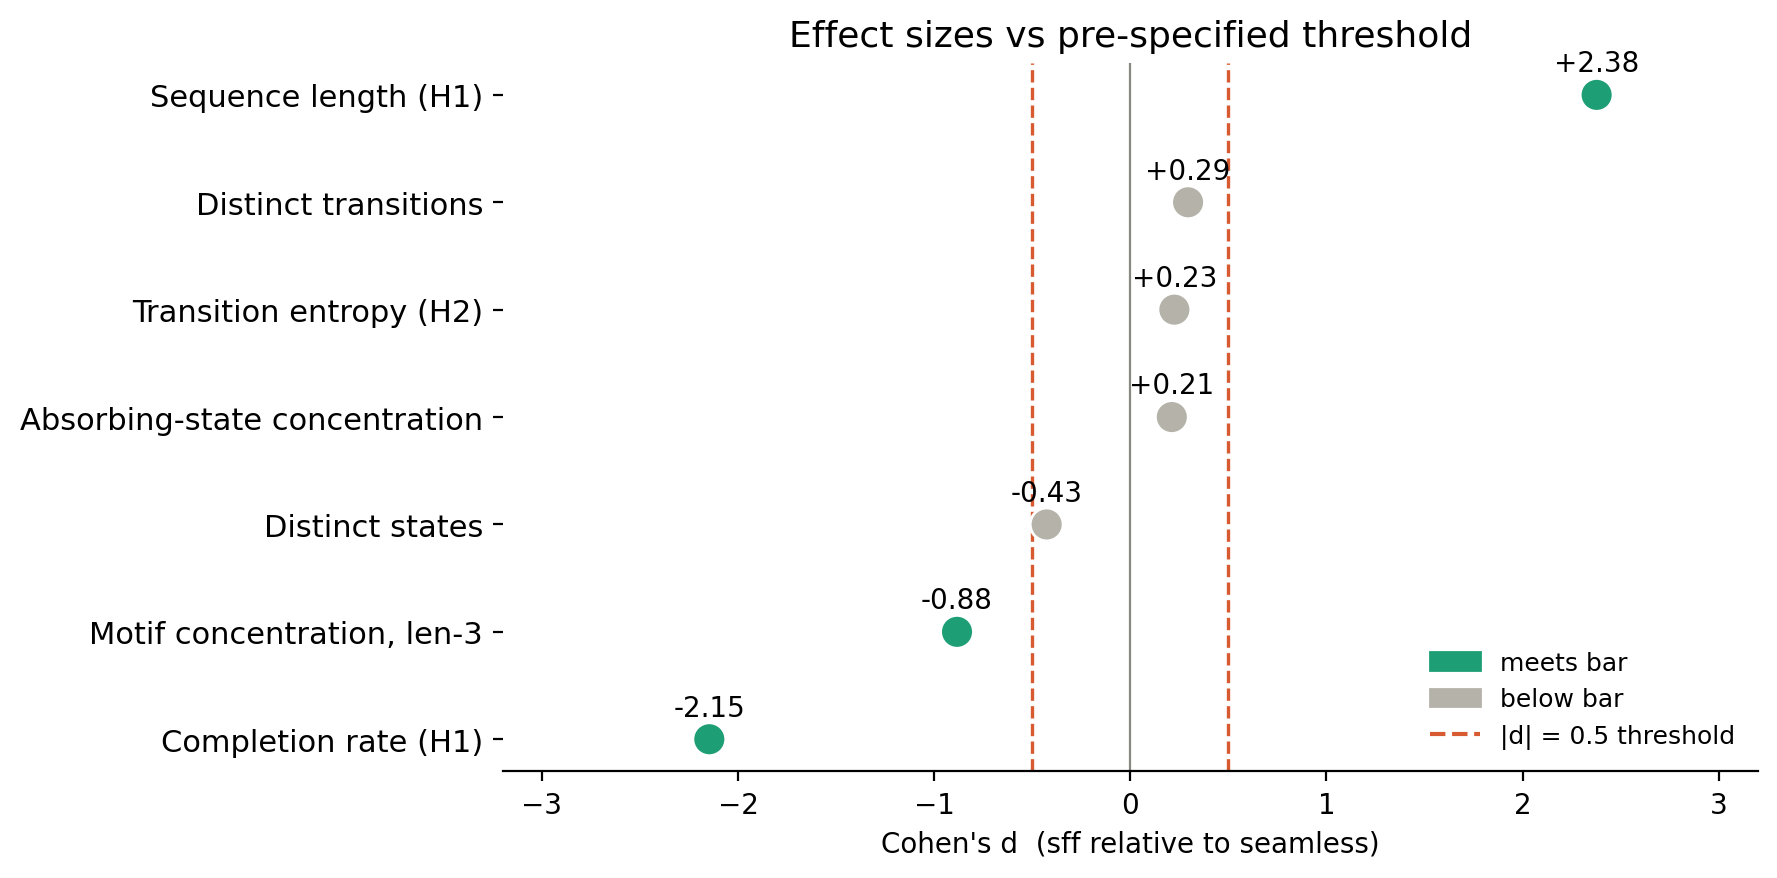

In [90]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from pathlib import Path

RUN_DIR = Path.cwd() / "runs" / "full_run_001"

# verified effect sizes (recomputed live from DATA)
# (label, cohens_d, meets_threshold)
rows = [
    ("Sequence length (H1)",            2.378, True),
    ("Completion rate (H1)",           -2.146, True),
    ("Motif concentration, len-3",     -0.883, True),
    ("Distinct states",                -0.426, False),
    ("Distinct transitions",            0.295, False),
    ("Transition entropy (H2)",         0.225, False),
    ("Absorbing-state concentration",   0.212, False),
]

rows = sorted(rows, key=lambda r: r[1])
labels = [r[0] for r in rows]
ds     = [r[1] for r in rows]
met    = [r[2] for r in rows]
y = np.arange(len(rows))
colors = ["#1D9E75" if m else "#B4B2A9" for m in met]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvline(0, color="#888780", lw=0.8)
ax.axvline(0.5, color="#D85A30", lw=1.2, ls="--")
ax.axvline(-0.5, color="#D85A30", lw=1.2, ls="--")
ax.scatter(ds, y, s=140, color=colors, zorder=3, edgecolors="white", linewidth=1)
for yi, d in zip(y, ds):
    ax.text(d, yi + 0.22, f"{d:+.2f}", ha="center", fontsize=10)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel("Cohen's d  (sff relative to seamless)")
ax.set_title("Effect sizes vs pre-specified threshold", fontsize=13)
ax.set_xlim(-3.2, 3.2)
for sp in ["top", "right", "left"]:
    ax.spines[sp].set_visible(False)

ax.legend(handles=[Patch(color="#1D9E75", label="meets bar"),
                   Patch(color="#B4B2A9", label="below bar"),
                   plt.Line2D([0], [0], color="#D85A30", ls="--", label="|d| = 0.5 threshold")],
          loc="lower right", frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(RUN_DIR / "fig4_effect_sizes.png", dpi=200, bbox_inches="tight")
plt.savefig(RUN_DIR / "fig4_effect_sizes.pdf", bbox_inches="tight")
logger.info("Saved fig4_effect_sizes.png/.pdf (verified values)")

from IPython.display import Image, display
display(Image(filename=str(RUN_DIR / "fig4_effect_sizes.png")))

Saved fig5_survival.png/.pdf


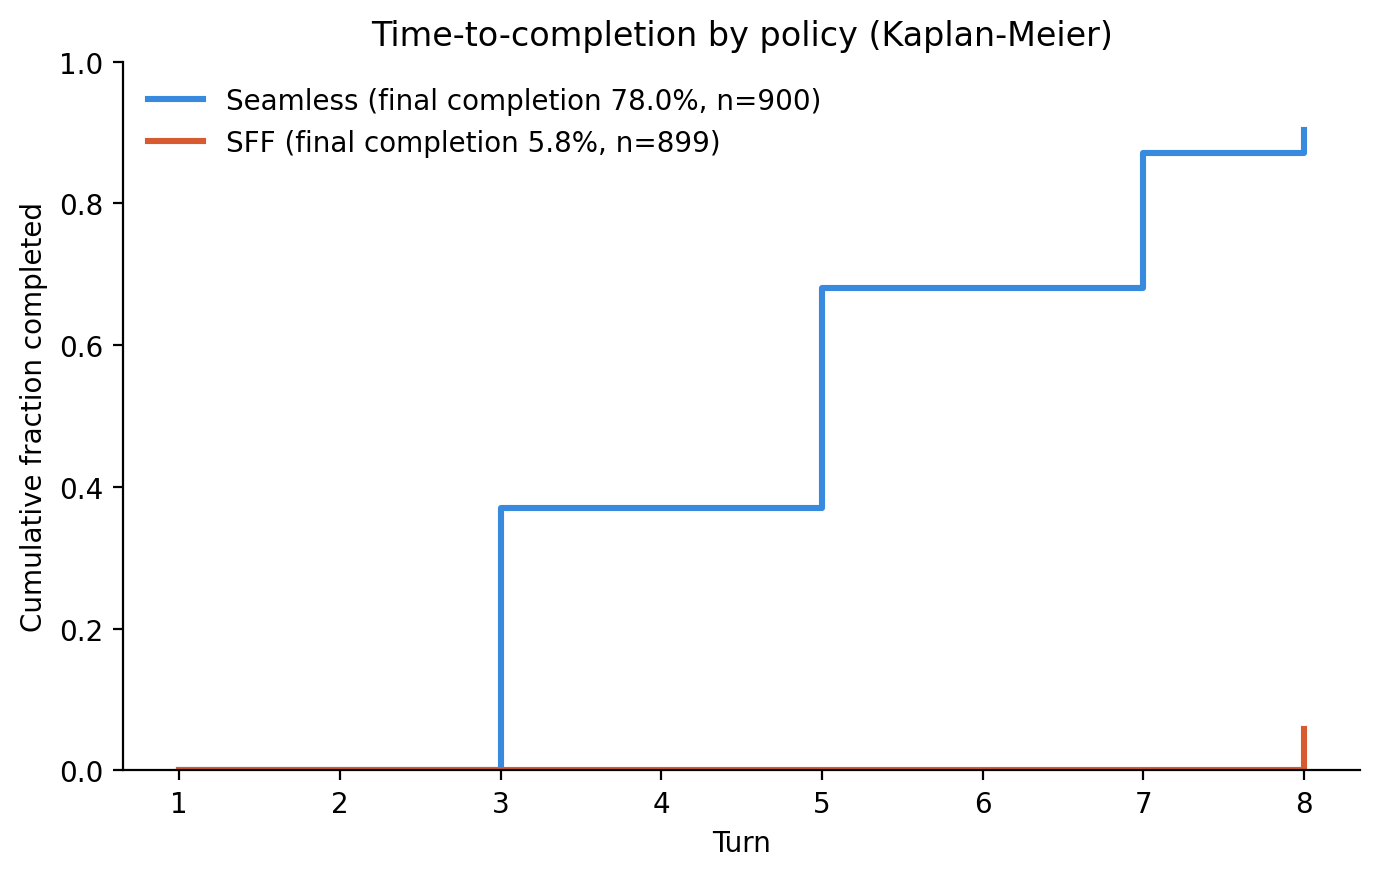

In [91]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path

RUN_DIR = Path.cwd() / "runs" / "full_run_001"
BUDGET = 8

def km_completion(cond):
    sess=[s for s in DATA.values() if s["condition"]==cond]
    n=len(sess)
    times=[]; events=[]
    for s in sess:
        seq=s.get("state_sequence_merged",s["state_sequence"])
        completed = s["terminal_state"]=="S9_TASK_COMPLETE"
        times.append(len(seq)); events.append(1 if completed else 0)
    times=np.array(times); events=np.array(events)
    ts=np.arange(1, BUDGET+1)
    at_risk=n; surv=1.0; surv_curve=[]
    for t in ts:
        d=np.sum((times==t)&(events==1))
        c=np.sum((times==t)&(events==0))
        if at_risk>0:
            surv*=(1 - d/at_risk)
        surv_curve.append(surv)
        at_risk-=(d+c)
    return ts, np.array(surv_curve), events.mean(), n

fig,ax=plt.subplots(figsize=(7,4.5))
for cond,color,lab in [("seamless","#378ADD","Seamless"),("sff","#D85A30","SFF")]:
    ts,surv,comprate,n=km_completion(cond)
    ax.step(ts, 1-surv, where="post", color=color, lw=2.2,
            label=f"{lab} (final completion {comprate:.1%}, n={n})")
ax.set_xlabel("Turn"); ax.set_ylabel("Cumulative fraction completed")
ax.set_title("Time-to-completion by policy (Kaplan-Meier)")
ax.set_ylim(0,1); ax.legend(frameon=False, fontsize=10)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig(RUN_DIR/"fig5_survival.png",dpi=200,bbox_inches="tight")
plt.savefig(RUN_DIR/"fig5_survival.pdf",bbox_inches="tight")
logger.info("Saved fig5_survival.png/.pdf")
from IPython.display import Image,display
display(Image(filename=str(RUN_DIR/"fig5_survival.png")))

In [ ]:
# Figure1_State_Transitions_AAAI_v3.py
# Focus: Fix percentage overlap and increase node size.

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
from matplotlib.lines import Line2D
import numpy as np

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

BLUE="#4E79A7"
TEAL="#59A14F"
AMBER="#F28E2B"
CORAL="#E15759"
GRAY="#6B7280"

def node_radius(occ):
    # larger nodes
    return max(1.05, 0.75 + 0.14*np.sqrt(occ))

def edge_width(count,max_count):
    return 0.8 + 3.5*(count/max_count)

PERCENT_OFFSET = {
    "S3": -1.05,
    "S6": -0.65,
    "S9": -0.50,
    "S7": -0.55,
    "S4": -0.55,
    "S5": -0.50,
    "S2": -0.50,
}

def draw_node(ax,xy,occ,color,state,label):

    r=node_radius(occ)

    ax.add_patch(
        Circle(
            xy,r,
            facecolor=color,
            edgecolor="white",
            linewidth=2.8,
            zorder=5
        )
    )

    ax.text(
        xy[0],xy[1]+0.15,
        state,
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold",
        color="white",
        zorder=6
    )

    ax.text(
        xy[0],xy[1]-0.25,
        label,
        ha="center",
        va="center",
        fontsize=11,
        color="white",
        zorder=6
    )

    # percentage outside node with white background
    ax.text(
        xy[0],
        xy[1] - r + PERCENT_OFFSET.get(state,-0.55),
        f"{occ}%",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#444444",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            pad=0.18
        ),
        zorder=20
    )

    return r

def draw_edge(ax,p1,p2,r1,r2,count,max_count,rad=0,alpha=0.6):

    dx=p2[0]-p1[0]
    dy=p2[1]-p1[1]
    d=np.hypot(dx,dy)

    if d==0:
        return

    ux=dx/d
    uy=dy/d

    start=(p1[0]+ux*r1,p1[1]+uy*r1)
    end=(p2[0]-ux*r2,p2[1]-uy*r2)

    ax.add_patch(
        FancyArrowPatch(
            start,end,
            arrowstyle="-|>",
            mutation_scale=15,
            linewidth=edge_width(count,max_count),
            color=GRAY,
            alpha=alpha,
            connectionstyle=f"arc3,rad={rad}",
            zorder=2
        )
    )

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(17,8))

# ---------------- PANEL A ----------------

posA={
"S3":(0,0),
"S6":(0,-2.8),
"S9":(0,-5.8),
"S7":(5.8,1.5),
"S4":(-4.8,-1.7),
"S5":(-2.1,3.5)
}

occA={"S3":30,"S6":13,"S9":13,"S7":11,"S4":10,"S5":11}
labelsA={"S3":"answer","S6":"accept","S9":"complete","S7":"contested","S4":"socratic","S5":"revise"}
colorsA={"S3":BLUE,"S6":BLUE,"S9":BLUE,"S7":CORAL,"S4":TEAL,"S5":AMBER}

rA={}
for n in posA:
    rA[n]=draw_node(ax1,posA[n],occA[n],colorsA[n],n,labelsA[n])

edgesA=[
("S6","S9",437,0.00),
("S3","S6",400,0.00),
("S3","S7",335,0.35),
("S7","S3",250,-0.35),
("S3","S5",275,-0.10),
("S5","S3",213,0.10),
("S4","S5",132,0.45),
("S5","S4",128,-0.45),
("S7","S4",126,0.00),
("S4","S6",115,0.45)
]

for u,v,c,r in edgesA:
    draw_edge(ax1,posA[u],posA[v],rA[u],rA[v],c,437,r)

ax1.text(1.3,-4.1,"437",fontsize=13,fontweight="bold")

ax1.set_title(
    "Seamless Control\n900 sessions · 3,154 transitions",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax1.set_xlim(-9,9)
ax1.set_ylim(-8,7)
ax1.set_aspect("equal")
ax1.axis("off")

# ---------------- PANEL B ----------------

posB={
"S4":(0,0),
"S7":(6.2,0),
"S5":(0,-6.5),
"S2":(-6.2,0),
"S3":(0,6.5)
}

occB={"S4":47,"S7":26,"S5":11,"S2":9,"S3":4}

labelsB={
"S4":"socratic",
"S7":"contested",
"S5":"revise",
"S2":"orient",
"S3":"answer"
}

colorsB={
"S4":CORAL,
"S7":AMBER,
"S5":AMBER,
"S2":TEAL,
"S3":BLUE
}

rB={}
for n in posB:
    rB[n]=draw_node(ax2,posB[n],occB[n],colorsB[n],n,labelsB[n])

draw_edge(ax2,posB["S4"],posB["S7"],rB["S4"],rB["S7"],1837,1837,0.60,0.75)
draw_edge(ax2,posB["S7"],posB["S4"],rB["S7"],rB["S4"],1376,1837,-0.60,0.75)

draw_edge(ax2,posB["S4"],posB["S5"],rB["S4"],rB["S5"],772,1837,0.25,0.60)
draw_edge(ax2,posB["S5"],posB["S4"],rB["S5"],rB["S4"],510,1837,-0.25,0.35)

draw_edge(ax2,posB["S2"],posB["S4"],rB["S2"],rB["S4"],607,1837,0.15,0.60)
draw_edge(ax2,posB["S4"],posB["S2"],rB["S4"],rB["S2"],502,1837,-0.15,0.35)

draw_edge(ax2,posB["S4"],posB["S3"],rB["S4"],rB["S3"],244,1837,0.15,0.60)
draw_edge(ax2,posB["S3"],posB["S4"],rB["S3"],rB["S4"],118,1837,-0.15,0.35)

ax2.text(3.0,2.6,"1837",fontsize=13,fontweight="bold",
         bbox=dict(fc="white",ec="none",pad=0.15))

ax2.text(3.0,-3.0,"1376",fontsize=13,fontweight="bold",
         bbox=dict(fc="white",ec="none",pad=0.15))

ax2.set_title(
    "Strategic Friction (SFF)\n899 sessions · 6,280 transitions",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax2.set_xlim(-10,10)
ax2.set_ylim(-9,9)
ax2.set_aspect("equal")
ax2.axis("off")

fig.add_artist(
    Line2D([0.5,0.5],[0.12,0.92],
           transform=fig.transFigure,
           color="#D0D0D0",
           linewidth=1)
)

fig.text(
    0.5,
    0.03,
    "Node size = share of state visits · Edge width = transition frequency. Seamless: short S3→S6→S9 path. SFF: dominant S4↔S7 loop.",
    ha="center",
    fontsize=10,
    bbox=dict(
        facecolor="#F8F8F8",
        edgecolor="#DDDDDD",
        boxstyle="round,pad=0.5"
    )
)

plt.tight_layout(rect=[0,0.07,1,1])

plt.savefig("Figure1_State_Transitions_AAAI_v3.pdf",bbox_inches="tight")
plt.savefig("Figure1_State_Transitions_AAAI_v3.svg",bbox_inches="tight")
plt.savefig("Figure1_State_Transitions_AAAI_v3.png",dpi=600,bbox_inches="tight")

plt.show()